#**FASE 1 — Business Understanding**
1.1 Definición del problema AID-CV

1.2 Objetivos: detección T. cruzi, despliegue móvil offline

In [ ]:
from google.colab import drive
drive.flush_and_unmount()

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# **FASE 2 — Data Preparation**

2.2 Split estratificado train/val/test

In [ ]:
import os
import shutil
import random
import numpy as np
from pathlib import Path

# ─── RUTAS ────────────────────────────────────────────────────────────────────
TRAIN_IMGS_SRC = "/content/drive/MyDrive/P-t.cruzi-AI/dataset/train/images/train"
TRAIN_LBLS_SRC = "/content/drive/MyDrive/P-t.cruzi-AI/dataset/train/labels"

BASE_P2        = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2"

TRAIN_IMGS_DST = f"{BASE_P2}/train/images"
TRAIN_LBLS_DST = f"{BASE_P2}/train/labels"
VAL_IMGS_DST   = f"{BASE_P2}/val/images"
VAL_LBLS_DST   = f"{BASE_P2}/val/labels"

# ─── CREAR CARPETAS ───────────────────────────────────────────────────────────
for d in [TRAIN_IMGS_DST, TRAIN_LBLS_DST, VAL_IMGS_DST, VAL_LBLS_DST]:
    Path(d).mkdir(parents=True, exist_ok=True)

# ─── SEED FIJA — reproducibilidad del paper ───────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ─── PASO 1: Contar anotaciones por imagen ────────────────────────────────────
img_files = [f for f in os.listdir(TRAIN_IMGS_SRC) if f.endswith('.jpg')]

density = {}
for filename in img_files:
    lbl_path = os.path.join(TRAIN_LBLS_SRC, os.path.splitext(filename)[0] + ".txt")
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            lines = [l for l in f.read().strip().split("\n") if l]
        density[filename] = len(lines)
    else:
        density[filename] = 0

counts = np.array([density[f] for f in img_files])
p33 = np.percentile(counts, 33)
p66 = np.percentile(counts, 66)

print(f"Percentil 33: {p33:.1f} anotaciones")
print(f"Percentil 66: {p66:.1f} anotaciones")

# ─── PASO 2: Clasificar en 3 grupos por densidad ─────────────────────────────
grupos = {"baja": [], "media": [], "alta": []}

for filename in img_files:
    n = density[filename]
    if n <= p33:
        grupos["baja"].append(filename)
    elif n <= p66:
        grupos["media"].append(filename)
    else:
        grupos["alta"].append(filename)

print(f"\nGrupos antes del split:")
for g, imgs in grupos.items():
    print(f"  {g:6s}: {len(imgs):3d} imágenes | "
          f"avg {np.mean([density[f] for f in imgs]):.1f} anot/img")

# ─── PASO 3: Sacar 15% de cada grupo para val ─────────────────────────────────
VAL_RATIO = 0.15

val_set   = []
train_set = []

for g, imgs in grupos.items():
    random.shuffle(imgs)
    n_val = max(1, int(len(imgs) * VAL_RATIO))
    val_set.extend(imgs[:n_val])
    train_set.extend(imgs[n_val:])

print(f"\nSplit final:")
print(f"  Train : {len(train_set)} imágenes")
print(f"  Val   : {len(val_set)} imágenes")
print(f"  Test  : 105 imágenes (intocable)")
print(f"  Total : {len(train_set) + len(val_set) + 105} imágenes")

# ─── PASO 4: Copiar archivos ──────────────────────────────────────────────────
def copiar(filenames, src_imgs, src_lbls, dst_imgs, dst_lbls):
    copied_imgs = 0
    copied_lbls = 0
    for filename in filenames:
        # Imagen
        src_i = os.path.join(src_imgs, filename)
        dst_i = os.path.join(dst_imgs, filename)
        if os.path.exists(src_i):
            shutil.copy2(src_i, dst_i)
            copied_imgs += 1
        # Label
        lbl_name = os.path.splitext(filename)[0] + ".txt"
        src_l = os.path.join(src_lbls, lbl_name)
        dst_l = os.path.join(dst_lbls, lbl_name)
        if os.path.exists(src_l):
            shutil.copy2(src_l, dst_l)
            copied_lbls += 1
    return copied_imgs, copied_lbls

print("\nCopiando archivos...")
ti, tl = copiar(train_set, TRAIN_IMGS_SRC, TRAIN_LBLS_SRC, TRAIN_IMGS_DST, TRAIN_LBLS_DST)
vi, vl = copiar(val_set,   TRAIN_IMGS_SRC, TRAIN_LBLS_SRC, VAL_IMGS_DST,   VAL_LBLS_DST)

# ─── PASO 5: Reporte documentable ─────────────────────────────────────────────
train_counts = [density[f] for f in train_set]
val_counts   = [density[f] for f in val_set]

print("\n" + "="*62)
print("  AID-CV | Split Estratificado por Densidad de Parásitos")
print(f"  Seed: {SEED} | VAL ratio: {int(VAL_RATIO*100)}% por grupo")
print("="*62)
print(f"  {'Split':<8} {'Imgs':>5} {'Labels':>7} {'Min':>5} "
      f"{'Max':>5} {'Avg':>6} {'Total anot':>10}")
print("-"*62)
print(f"  {'Train':<8} {ti:>5} {tl:>7} {min(train_counts):>5} "
      f"{max(train_counts):>5} {np.mean(train_counts):>6.2f} "
      f"{sum(train_counts):>10}")
print(f"  {'Val':<8} {vi:>5} {vl:>7} {min(val_counts):>5} "
      f"{max(val_counts):>5} {np.mean(val_counts):>6.2f} "
      f"{sum(val_counts):>10}")
print(f"  {'Test':<8} {'105':>5} {'105':>7} {'(intocable)':>18}")
print("="*62)
print(f"\n  Distribución val por grupo de densidad:")
for g in ["baja", "media", "alta"]:
    val_g   = [f for f in val_set   if f in grupos[g]]
    train_g = [f for f in train_set if f in grupos[g]]
    print(f"    {g:6s}: {len(val_g):2d} val / {len(train_g):3d} train")
print("="*62)

Percentil 33: 6.0 anotaciones
Percentil 66: 9.0 anotaciones

Grupos antes del split:
  baja  : 266 imágenes | avg 4.2 anot/img
  media : 126 imágenes | avg 7.9 anot/img
  alta  : 177 imágenes | avg 12.9 anot/img

Split final:
  Train : 486 imágenes
  Val   : 83 imágenes
  Test  : 105 imágenes (intocable)
  Total : 674 imágenes

Copiando archivos...

  AID-CV | Split Estratificado por Densidad de Parásitos
  Seed: 42 | VAL ratio: 15% por grupo
  Split     Imgs  Labels   Min   Max    Avg Total anot
--------------------------------------------------------------
  Train      486     486     2    28   7.71       3748
  Val         83      83     1    23   7.60        631
  Test       105     105        (intocable)

  Distribución val por grupo de densidad:
    baja  : 39 val / 227 train
    media : 18 val / 108 train
    alta  : 26 val / 151 train


2.3 Tiling de train

In [ ]:
import cv2
import os
import numpy as np
from pathlib import Path

# ─── RUTAS pipeline2 ──────────────────────────────────────────────────────────
TRAIN_IMGS   = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train/images"
TRAIN_LBLS   = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train/labels"
TILED_IMGS   = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train_tiled/images"
TILED_LBLS   = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train_tiled/labels"

# ─── PARÁMETROS ───────────────────────────────────────────────────────────────
TILE_SIZE    = 640
OVERLAP      = 0.2
STRIDE       = int(TILE_SIZE * (1 - OVERLAP))  # 512px
BG_RATIO     = 0.10
SEED         = 42

# ─── LIMPIAR DESTINO ──────────────────────────────────────────────────────────
for d in [TILED_IMGS, TILED_LBLS]:
    if Path(d).exists():
        for f in Path(d).iterdir():
            f.unlink()
        print(f"🧹 Limpiada: {d}")

Path(TILED_IMGS).mkdir(parents=True, exist_ok=True)
Path(TILED_LBLS).mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)

# ─── PIPELINE ─────────────────────────────────────────────────────────────────
stats = {
    "imagenes"          : 0,
    "tiles_total"       : 0,
    "tiles_con_parasito": 0,
    "tiles_background"  : 0,
    "anotaciones_total" : 0
}

img_files = sorted([f for f in os.listdir(TRAIN_IMGS) if f.endswith('.jpg')])
print(f"Imágenes a tilear: {len(img_files)}\n")

for filename in img_files:
    img_path = os.path.join(TRAIN_IMGS, filename)
    lbl_path = os.path.join(TRAIN_LBLS, os.path.splitext(filename)[0] + ".txt")

    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️  No se pudo leer: {filename}")
        continue
    img_h, img_w = img.shape[:2]

    labels = []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f.read().strip().split("\n"):
                if line:
                    parts = line.split()
                    labels.append([int(parts[0]),
                                   float(parts[1]), float(parts[2]),
                                   float(parts[3]), float(parts[4])])

    labels_px = []
    for cls, cx, cy, bw, bh in labels:
        x1 = (cx - bw/2) * img_w
        y1 = (cy - bh/2) * img_h
        x2 = (cx + bw/2) * img_w
        y2 = (cy + bh/2) * img_h
        labels_px.append([cls, x1, y1, x2, y2])

    tile_idx = 0
    for y_start in range(0, img_h - TILE_SIZE + 1, STRIDE):
        for x_start in range(0, img_w - TILE_SIZE + 1, STRIDE):
            x_end = x_start + TILE_SIZE
            y_end = y_start + TILE_SIZE

            # ── CORRECCIÓN DEL BUG ────────────────────────────────────────────
            # Zona de asignación exclusiva = zona no solapada (stride)
            # Excepción: último tile de cada fila/columna captura hasta el borde
            assign_x_end = x_start + STRIDE if (x_start + TILE_SIZE) < img_w else img_w
            assign_y_end = y_start + STRIDE if (y_start + TILE_SIZE) < img_h else img_h

            tile_labels = []
            for cls, x1, y1, x2, y2 in labels_px:
                cx_abs = (x1 + x2) / 2
                cy_abs = (y1 + y2) / 2

                # Centro asignado solo a UN tile por su zona exclusiva
                if (x_start <= cx_abs < assign_x_end and
                    y_start <= cy_abs < assign_y_end):

                    cx_local = (cx_abs - x_start) / TILE_SIZE
                    cy_local = (cy_abs - y_start) / TILE_SIZE
                    bw_local = (x2 - x1)           / TILE_SIZE
                    bh_local = (y2 - y1)           / TILE_SIZE

                    cx_local = max(0.0, min(1.0, cx_local))
                    cy_local = max(0.0, min(1.0, cy_local))
                    bw_local = max(0.001, min(1.0, bw_local))
                    bh_local = max(0.001, min(1.0, bh_local))

                    tile_labels.append(
                        f"{cls} {cx_local:.6f} {cy_local:.6f} "
                        f"{bw_local:.6f} {bh_local:.6f}"
                    )

            tiene_parasito = len(tile_labels) > 0
            save_tile = tiene_parasito or (np.random.random() < BG_RATIO)

            if save_tile:
                tile_name = f"{os.path.splitext(filename)[0]}_t{tile_idx:04d}.jpg"
                cv2.imwrite(
                    os.path.join(TILED_IMGS, tile_name),
                    img[y_start:y_end, x_start:x_end],
                    [cv2.IMWRITE_JPEG_QUALITY, 95]
                )
                with open(os.path.join(TILED_LBLS,
                          tile_name.replace('.jpg', '.txt')), 'w') as f:
                    f.write("\n".join(tile_labels))

                stats['tiles_total'] += 1
                stats['anotaciones_total'] += len(tile_labels)
                if tiene_parasito:
                    stats['tiles_con_parasito'] += 1
                else:
                    stats['tiles_background'] += 1

            tile_idx += 1

    stats['imagenes'] += 1
    if stats['imagenes'] % 50 == 0:
        print(f"  Procesadas: {stats['imagenes']}/{len(img_files)} | "
              f"{stats['tiles_total']} tiles generados")

# ─── REPORTE ──────────────────────────────────────────────────────────────────
print("\n" + "="*58)
print("  AID-CV | Fase 3.3 — Tiling Train pipeline2 (corregido)")
print("="*58)
print(f"  Imágenes procesadas  : {stats['imagenes']}")
print(f"  Tiles totales        : {stats['tiles_total']}")
print(f"  Con parásito         : {stats['tiles_con_parasito']} "
      f"({100*stats['tiles_con_parasito']/stats['tiles_total']:.1f}%)")
print(f"  Background (10%)     : {stats['tiles_background']} "
      f"({100*stats['tiles_background']/stats['tiles_total']:.1f}%)")
print(f"  Anotaciones totales  : {stats['anotaciones_total']}")
print(f"  Referencia esperada  : ≤ 3748 (train original)")
if stats['anotaciones_total'] <= 3748:
    print(f"  Verificación         : ✅ anotaciones consistentes")
else:
    print(f"  Verificación         : 🔴 anotaciones infladas — revisar")
print("="*58)

🧹 Limpiada: /content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train_tiled/images
🧹 Limpiada: /content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train_tiled/labels
Imágenes a tilear: 486

  Procesadas: 50/486 | 415 tiles generados
  Procesadas: 100/486 | 811 tiles generados
  Procesadas: 150/486 | 1204 tiles generados
  Procesadas: 200/486 | 1553 tiles generados
  Procesadas: 250/486 | 1904 tiles generados
  Procesadas: 300/486 | 2259 tiles generados
  Procesadas: 350/486 | 2599 tiles generados
  Procesadas: 400/486 | 2934 tiles generados
  Procesadas: 450/486 | 3279 tiles generados

  AID-CV | Fase 3.3 — Tiling Train pipeline2 (corregido)
  Imágenes procesadas  : 486
  Tiles totales        : 3543
  Con parásito         : 1906 (53.8%)
  Background (10%)     : 1637 (46.2%)
  Anotaciones totales  : 3702
  Referencia esperada  : ≤ 3748 (train original)
  Verificación         : ✅ anotaciones consistentes


2.4 Tiling de val

In [ ]:
import cv2
import os
import numpy as np
from pathlib import Path

# ─── RUTAS pipeline2 ──────────────────────────────────────────────────────────
VAL_IMGS     = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/val/images"
VAL_LBLS     = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/val/labels"
TILED_IMGS   = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/val_tiled/images"
TILED_LBLS   = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/val_tiled/labels"

# ─── PARÁMETROS — idénticos al tiling de train ────────────────────────────────
TILE_SIZE    = 640
OVERLAP      = 0.2
STRIDE       = int(TILE_SIZE * (1 - OVERLAP))  # 512px
BG_RATIO     = 0.04
SEED         = 42

# ─── LIMPIAR DESTINO ──────────────────────────────────────────────────────────
for d in [TILED_IMGS, TILED_LBLS]:
    if Path(d).exists():
        for f in Path(d).iterdir():
            f.unlink()
        print(f"🧹 Limpiada: {d}")

Path(TILED_IMGS).mkdir(parents=True, exist_ok=True)
Path(TILED_LBLS).mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)

# ─── PIPELINE ─────────────────────────────────────────────────────────────────
stats = {
    "imagenes"          : 0,
    "tiles_total"       : 0,
    "tiles_con_parasito": 0,
    "tiles_background"  : 0,
    "anotaciones_total" : 0
}

img_files = sorted([f for f in os.listdir(VAL_IMGS) if f.endswith('.jpg')])
print(f"Imágenes val a tilear: {len(img_files)}\n")

for filename in img_files:
    img_path = os.path.join(VAL_IMGS, filename)
    lbl_path = os.path.join(VAL_LBLS, os.path.splitext(filename)[0] + ".txt")

    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️  No se pudo leer: {filename}")
        continue
    img_h, img_w = img.shape[:2]

    labels = []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f.read().strip().split("\n"):
                if line:
                    parts = line.split()
                    labels.append([int(parts[0]),
                                   float(parts[1]), float(parts[2]),
                                   float(parts[3]), float(parts[4])])

    labels_px = []
    for cls, cx, cy, bw, bh in labels:
        x1 = (cx - bw/2) * img_w
        y1 = (cy - bh/2) * img_h
        x2 = (cx + bw/2) * img_w
        y2 = (cy + bh/2) * img_h
        labels_px.append([cls, x1, y1, x2, y2])

    tile_idx = 0
    for y_start in range(0, img_h - TILE_SIZE + 1, STRIDE):
        for x_start in range(0, img_w - TILE_SIZE + 1, STRIDE):
            x_end = x_start + TILE_SIZE
            y_end = y_start + TILE_SIZE

            # Zona exclusiva de asignación — corrección del bug
            assign_x_end = x_start + STRIDE if (x_start + TILE_SIZE) < img_w else img_w
            assign_y_end = y_start + STRIDE if (y_start + TILE_SIZE) < img_h else img_h

            tile_labels = []
            for cls, x1, y1, x2, y2 in labels_px:
                cx_abs = (x1 + x2) / 2
                cy_abs = (y1 + y2) / 2

                if (x_start <= cx_abs < assign_x_end and
                    y_start <= cy_abs < assign_y_end):

                    cx_local = (cx_abs - x_start) / TILE_SIZE
                    cy_local = (cy_abs - y_start) / TILE_SIZE
                    bw_local = (x2 - x1)           / TILE_SIZE
                    bh_local = (y2 - y1)           / TILE_SIZE

                    cx_local = max(0.0, min(1.0, cx_local))
                    cy_local = max(0.0, min(1.0, cy_local))
                    bw_local = max(0.001, min(1.0, bw_local))
                    bh_local = max(0.001, min(1.0, bh_local))

                    tile_labels.append(
                        f"{cls} {cx_local:.6f} {cy_local:.6f} "
                        f"{bw_local:.6f} {bh_local:.6f}"
                    )

            tiene_parasito = len(tile_labels) > 0
            save_tile = tiene_parasito or (np.random.random() < BG_RATIO)

            if save_tile:
                tile_name = f"{os.path.splitext(filename)[0]}_t{tile_idx:04d}.jpg"
                cv2.imwrite(
                    os.path.join(TILED_IMGS, tile_name),
                    img[y_start:y_end, x_start:x_end],
                    [cv2.IMWRITE_JPEG_QUALITY, 95]
                )
                with open(os.path.join(TILED_LBLS,
                          tile_name.replace('.jpg', '.txt')), 'w') as f:
                    f.write("\n".join(tile_labels))

                stats['tiles_total'] += 1
                stats['anotaciones_total'] += len(tile_labels)
                if tiene_parasito:
                    stats['tiles_con_parasito'] += 1
                else:
                    stats['tiles_background'] += 1

            tile_idx += 1

    stats['imagenes'] += 1

# ─── REPORTE ──────────────────────────────────────────────────────────────────
print("\n" + "="*58)
print("  AID-CV | Fase 3.4 — Tiling Val pipeline2")
print("="*58)
print(f"  Imágenes procesadas  : {stats['imagenes']}")
print(f"  Tiles totales        : {stats['tiles_total']}")
print(f"  Con parásito         : {stats['tiles_con_parasito']} "
      f"({100*stats['tiles_con_parasito']/stats['tiles_total']:.1f}%)")
print(f"  Background (10%)     : {stats['tiles_background']} "
      f"({100*stats['tiles_background']/stats['tiles_total']:.1f}%)")
print(f"  Anotaciones totales  : {stats['anotaciones_total']}")
print(f"  Referencia esperada  : ≤ 631 (val original)")
if stats['anotaciones_total'] <= 631:
    print(f"  Verificación         : ✅ anotaciones consistentes")
else:
    print(f"  Verificación         : 🔴 anotaciones infladas — revisar")
print("="*58)

🧹 Limpiada: /content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/val_tiled/images
🧹 Limpiada: /content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/val_tiled/labels
Imágenes val a tilear: 83


  AID-CV | Fase 3.4 — Tiling Val pipeline2
  Imágenes procesadas  : 83
  Tiles totales        : 453
  Con parásito         : 331 (73.1%)
  Background (10%)     : 122 (26.9%)
  Anotaciones totales  : 627
  Referencia esperada  : ≤ 631 (val original)
  Verificación         : ✅ anotaciones consistentes


**2.5. Tilin de Train con Data Augmentation**

In [ ]:
import cv2
import os
import numpy as np
import shutil
from pathlib import Path

# ─── RUTAS ────────────────────────────────────────────────────────────────────
TILED_IMGS       = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train_tiled/images"
TILED_LBLS       = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train_tiled/labels"
AUG_IMGS         = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train_tiled_aug/images"
AUG_LBLS         = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train_tiled_aug/labels"
COMBINED_IMGS    = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train_tiled_combined/images"
COMBINED_LBLS    = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/train_tiled_combined/labels"

# ─── PARÁMETROS ───────────────────────────────────────────────────────────────
SEED             = 42
N_VERSIONS       = 3   # versiones aumentadas por tile positivo

# ─── TRANSFORMACIONES POR VERSIÓN ─────────────────────────────────────────────
# v0: Flip H  + Rot 90°  + brillo leve
# v1: Flip V  + Rot 270° + HSV leve
# v2: Rot 180° + brillo+contraste leve

# ─── CREAR / LIMPIAR CARPETAS ─────────────────────────────────────────────────
for d in [AUG_IMGS, AUG_LBLS, COMBINED_IMGS, COMBINED_LBLS]:
    if Path(d).exists():
        for f in Path(d).iterdir():
            f.unlink()
        print(f"🧹 Limpiada: {d}")
    Path(d).mkdir(parents=True, exist_ok=True)

np.random.seed(SEED)

# ─── HELPERS ──────────────────────────────────────────────────────────────────
def flip_labels(labels, flip_code):
    """
    flip_code: 1 = horizontal, 0 = vertical
    YOLO format: cx cy bw bh — todo normalizado [0,1]
    """
    new_labels = []
    for parts in labels:
        cls, cx, cy, bw, bh = parts
        if flip_code == 1:   # horizontal
            cx = 1.0 - cx
        elif flip_code == 0: # vertical
            cy = 1.0 - cy
        new_labels.append([cls, cx, cy, bw, bh])
    return new_labels

def rotate_labels(labels, angle, img_size=640):
    """
    Rota bboxes para 90, 180, 270 grados.
    Imagen cuadrada (640x640) — simplifica la transformación.
    """
    new_labels = []
    for parts in labels:
        cls, cx, cy, bw, bh = parts
        if angle == 90:
            cx, cy = cy, 1.0 - cx
            bw, bh = bh, bw
        elif angle == 180:
            cx, cy = 1.0 - cx, 1.0 - cy
        elif angle == 270:
            cx, cy = 1.0 - cy, cx
            bw, bh = bh, bw
        new_labels.append([cls, cx, cy, bw, bh])
    return new_labels

def rotate_image(img, angle):
    if angle == 90:
        return cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    elif angle == 180:
        return cv2.rotate(img, cv2.ROTATE_180)
    elif angle == 270:
        return cv2.rotate(img, cv2.ROTATE_90_COUNTERCLOCKWISE)
    return img

def adjust_brightness(img, factor):
    """factor > 1 aclara, < 1 oscurece. Rango seguro: 0.7 – 1.3"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def adjust_hsv(img, hue_shift=10, sat_factor=1.2):
    """Hue shift leve + saturación moderada — simula variación de tinción"""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    hsv[:, :, 0] = (hsv[:, :, 0] + hue_shift) % 180
    hsv[:, :, 1] = np.clip(hsv[:, :, 1] * sat_factor, 0, 255)
    return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

def adjust_brightness_contrast(img, brightness=20, contrast=1.2):
    """Brillo aditivo + contraste multiplicativo"""
    out = img.astype(np.float32)
    out = out * contrast + brightness
    return np.clip(out, 0, 255).astype(np.uint8)

def read_labels(lbl_path):
    labels = []
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f.read().strip().split("\n"):
                if line:
                    parts = line.split()
                    labels.append([int(parts[0]),
                                   float(parts[1]), float(parts[2]),
                                   float(parts[3]), float(parts[4])])
    return labels

def write_labels(lbl_path, labels):
    with open(lbl_path, 'w') as f:
        lines = [f"{int(l[0])} {l[1]:.6f} {l[2]:.6f} {l[3]:.6f} {l[4]:.6f}"
                 for l in labels]
        f.write("\n".join(lines))

def save_pair(img, labels, img_path, lbl_path):
    cv2.imwrite(img_path, img, [cv2.IMWRITE_JPEG_QUALITY, 95])
    write_labels(lbl_path, labels)

# ─── PIPELINE AUGMENTATION ────────────────────────────────────────────────────
tile_files = sorted([f for f in os.listdir(TILED_IMGS) if f.endswith('.jpg')])

stats = {
    "tiles_positivos" : 0,
    "tiles_background": 0,
    "aug_generados"   : 0,
}

print(f"Tiles en train_tiled: {len(tile_files)}")
print("Procesando augmentation solo sobre tiles CON parásito...\n")

for filename in tile_files:
    img_path = os.path.join(TILED_IMGS, filename)
    lbl_path = os.path.join(TILED_LBLS, filename.replace('.jpg', '.txt'))

    labels = read_labels(lbl_path)
    tiene_parasito = len(labels) > 0

    if not tiene_parasito:
        stats['tiles_background'] += 1
        continue

    stats['tiles_positivos'] += 1
    img = cv2.imread(img_path)
    stem = os.path.splitext(filename)[0]

    # ── Versión 0: Flip H + Rot 90° + brillo leve ─────────────────────────
    img_v0 = adjust_brightness(
                 rotate_image(
                     cv2.flip(img, 1), 90),
                 factor=np.random.uniform(0.85, 1.15))
    lbl_v0 = rotate_labels(flip_labels(labels, 1), 90)
    save_pair(img_v0, lbl_v0,
              f"{AUG_IMGS}/{stem}_aug0.jpg",
              f"{AUG_LBLS}/{stem}_aug0.txt")

    # ── Versión 1: Flip V + Rot 270° + HSV leve ───────────────────────────
    img_v1 = adjust_hsv(
                 rotate_image(
                     cv2.flip(img, 0), 270),
                 hue_shift=np.random.randint(-15, 15),
                 sat_factor=np.random.uniform(0.9, 1.3))
    lbl_v1 = rotate_labels(flip_labels(labels, 0), 270)
    save_pair(img_v1, lbl_v1,
              f"{AUG_IMGS}/{stem}_aug1.jpg",
              f"{AUG_LBLS}/{stem}_aug1.txt")

    # ── Versión 2: Rot 180° + brillo+contraste leve ───────────────────────
    img_v2 = adjust_brightness_contrast(
                 rotate_image(img, 180),
                 brightness=np.random.randint(-20, 20),
                 contrast=np.random.uniform(0.9, 1.2))
    lbl_v2 = rotate_labels(labels, 180)
    save_pair(img_v2, lbl_v2,
              f"{AUG_IMGS}/{stem}_aug2.jpg",
              f"{AUG_LBLS}/{stem}_aug2.txt")

    stats['aug_generados'] += 3

# ─── CONSTRUIR COMBINED ───────────────────────────────────────────────────────
print("Construyendo train_tiled_combined...")

# Copiar originales
copied_orig = 0
for filename in tile_files:
    shutil.copy2(f"{TILED_IMGS}/{filename}",
                 f"{COMBINED_IMGS}/{filename}")
    lbl = filename.replace('.jpg', '.txt')
    shutil.copy2(f"{TILED_LBLS}/{lbl}",
                 f"{COMBINED_LBLS}/{lbl}")
    copied_orig += 1

# Copiar aumentados
aug_files = sorted([f for f in os.listdir(AUG_IMGS) if f.endswith('.jpg')])
copied_aug = 0
for filename in aug_files:
    shutil.copy2(f"{AUG_IMGS}/{filename}",
                 f"{COMBINED_IMGS}/{filename}")
    lbl = filename.replace('.jpg', '.txt')
    shutil.copy2(f"{AUG_LBLS}/{lbl}",
                 f"{COMBINED_LBLS}/{lbl}")
    copied_aug += 1

total_combined = copied_orig + copied_aug

# ─── REPORTE ──────────────────────────────────────────────────────────────────
print("\n" + "="*62)
print("  AID-CV | Fase 3.5 — Augmentation Offline (train)")
print(f"  Seed: {SEED} | Versiones por tile positivo: {N_VERSIONS}")
print("="*62)
print(f"  Tiles positivos encontrados : {stats['tiles_positivos']}")
print(f"  Tiles background (omitidos) : {stats['tiles_background']}")
print(f"  Tiles aumentados generados  : {stats['aug_generados']}")
print("-"*62)
print(f"  train_tiled/         : {copied_orig:>6} tiles (originales)")
print(f"  train_tiled_aug/     : {copied_aug:>6} tiles (solo aumentados)")
print(f"  train_tiled_combined/: {total_combined:>6} tiles (originales + aumentados)")
print("="*62)
print(f"\n  Distribución esperada en combined:")
pos_combined  = stats['tiles_positivos'] + stats['aug_generados']
neg_combined  = stats['tiles_background']
pct_pos = 100 * pos_combined / total_combined
pct_neg = 100 * neg_combined / total_combined
print(f"    Con parásito : {pos_combined} ({pct_pos:.1f}%)")
print(f"    Background   : {neg_combined} ({pct_neg:.1f}%)")
print("="*62)

Tiles en train_tiled: 3543
Procesando augmentation solo sobre tiles CON parásito...

Construyendo train_tiled_combined...

  AID-CV | Fase 3.5 — Augmentation Offline (train)
  Seed: 42 | Versiones por tile positivo: 3
  Tiles positivos encontrados : 1906
  Tiles background (omitidos) : 1637
  Tiles aumentados generados  : 5718
--------------------------------------------------------------
  train_tiled/         :   3543 tiles (originales)
  train_tiled_aug/     :   5718 tiles (solo aumentados)
  train_tiled_combined/:   9261 tiles (originales + aumentados)

  Distribución esperada en combined:
    Con parásito : 7624 (82.3%)
    Background   : 1637 (17.7%)


 2.6 Generación de data.yaml

In [ ]:
# ─── FASE 3.6 — Generación data.yaml pipeline2 ───────────────────────────────

yaml_content = """# AID-CV | dataset-pipeline2
# Split estratificado por densidad de parásitos
# Seed: 42 | Tiling: 640×640 | Stride: 512 | Overlap: 20%
# Bug de anotaciones duplicadas corregido (zona exclusiva de asignación)
# Augmentation offline aplicado solo a tiles positivos (3 versiones)
#
# Train : 486 imágenes → 9,261 tiles combined | 7,624 con parásito (82.3%)
# Val   :  83 imágenes →   637 tiles          |   627 anotaciones
# Test  : 105 imágenes → intocable hasta evaluación final
#
# 1 clase: todas las estructuras morfológicas del T. cruzi
# (KINETOPLAST, NUCLEUS, KINETOPLAST_CELL_BODY, NUCLEUS_CELL_BODY, T_CRUZI)
# colapsadas en una sola clase para maximizar instancias de entrenamiento

path: /content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2
train: train_tiled_combined/images
val:   val_tiled/images

nc: 1
names:
  0: trypanosoma_cruzi
"""

yaml_path = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/data.yaml"
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("="*58)
print("  AID-CV | Fase 3.6 — data.yaml pipeline2")
print("="*58)
print(f"  Guardado en : {yaml_path}")
print(f"  Train       : train_tiled_combined/images (9,261 tiles)")
print(f"  Val         : val_tiled/images   (637 tiles)")
print(f"  Test        : intocable")
print(f"  Clases      : 1 (trypanosoma_cruzi)")
print("="*58)

  AID-CV | Fase 3.6 — data.yaml pipeline2
  Guardado en : /content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/data.yaml
  Train       : train_tiled_combined/images (9,261 tiles)
  Val         : val_tiled/images   (637 tiles)
  Test        : intocable
  Clases      : 1 (trypanosoma_cruzi)


# Fase 3 - MODELING WITH SDG CONFIG

**Entrenamos los 3, YOLOv8small - 4.1 YOLO11nano - 4.1 YOLO11small**

SGD defaults        → comparación justa entre arquitecturas

device=0, workers=4 → GPU explícita, estabilidad en Colab

plots=True, val=True → curvas internas YOLO guardadas

Gráficas en Drive   → no se pierden si cae la sesión

Tabla acumulativa   → se actualiza después de cada modelo

Augmentation        → rotación 180°, hsv, mosaic reducido a 0.3

seed=42             → reproducibilidad del paper

torch.cuda.empty_cache() → libera GPU entre modelos

In [ ]:
# ─── AID-CV | Fase 3 — Reentrenamiento con Augmentation Offline ──────────────
# Modelos: YOLOv8s | YOLOv11n | YOLOv11s
# Train: train_tiled_combined (9,261 tiles — originales + augmentation offline)
# Cambio clave: augmentation online reducido para evitar doble-augmentation

!pip install ultralytics -q

from ultralytics import YOLO
import torch
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
from pathlib import Path

# ─── CONFIGURACIÓN GLOBAL ─────────────────────────────────────────────────────
DATA_YAML    = "/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/data.yaml"
PROJECT_PATH = "/content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug"
RESULTS_DIR  = "/content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/comparativa"
TABLE_PATH   = f"{RESULTS_DIR}/tabla_comparativa.csv"

Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

print(f"GPU disponible : {torch.cuda.is_available()}")
print(f"GPU            : {torch.cuda.get_device_name(0)}")
print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ─── MODELOS A ENTRENAR ───────────────────────────────────────────────────────
MODELOS = [
    {"weights": "yolov8s.pt",  "name": "yolov8s_aug"},
    {"weights": "yolo11n.pt",  "name": "yolo11n_aug"},
    {"weights": "yolo11s.pt",  "name": "yolo11s_aug"},
]

# ─── FUNCIÓN: GRAFICAR Y GUARDAR ──────────────────────────────────────────────
def guardar_graficas(results_csv, model_name, output_dir):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(3, 3, figsize=(18, 14))
    fig.suptitle(f"AID-CV | {model_name} — Curvas de Entrenamiento (aug)",
                 fontsize=14, fontweight='bold')

    def plot(ax, col_train, col_val=None, title=""):
        if col_train in df.columns:
            ax.plot(df[col_train], label='train', linewidth=1.5)
        if col_val and col_val in df.columns:
            ax.plot(df[col_val], label='val', linewidth=1.5)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plot(axes[0,0], 'train/box_loss',       'val/box_loss',  'Box Loss')
    plot(axes[0,1], 'train/cls_loss',       'val/cls_loss',  'Cls Loss')
    plot(axes[0,2], 'train/dfl_loss',       'val/dfl_loss',  'DFL Loss')
    plot(axes[1,0], 'metrics/precision(B)',  title='Precision (val)')
    plot(axes[1,1], 'metrics/recall(B)',     title='Recall (val)')
    plot(axes[1,2], 'metrics/mAP50(B)',      title='mAP@50 (val)')
    plot(axes[2,0], 'metrics/mAP50-95(B)',   title='mAP@50-95 (val)')

    if 'metrics/mAP50(B)' in df.columns:
        best_epoch = df['metrics/mAP50(B)'].idxmax() + 1
        best_map50 = df['metrics/mAP50(B)'].max()
        axes[2,1].axis('off')
        axes[2,1].text(0.5, 0.5,
            f"Mejor epoch : {best_epoch}\n"
            f"mAP@50      : {best_map50:.4f}",
            ha='center', va='center', fontsize=13,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

    axes[2,2].axis('off')
    plt.tight_layout()
    out_path = os.path.join(output_dir, f"{model_name}_curvas.png")
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.close()
    print(f"  📊 Gráfica guardada: {out_path}")

# ─── FUNCIÓN: ACTUALIZAR TABLA COMPARATIVA ────────────────────────────────────
def actualizar_tabla(model_name, weights, metrics_dict, epochs_real):
    fila = {
        "modelo"      : model_name,
        "weights_base": weights,
        "epochs_real" : epochs_real,
        "precision"   : round(metrics_dict.get('metrics/precision(B)', 0), 4),
        "recall"      : round(metrics_dict.get('metrics/recall(B)', 0), 4),
        "mAP50"       : round(metrics_dict.get('metrics/mAP50(B)', 0), 4),
        "mAP50-95"    : round(metrics_dict.get('metrics/mAP50-95(B)', 0), 4),
    }

    if os.path.exists(TABLE_PATH):
        df_tabla = pd.read_csv(TABLE_PATH)
        df_tabla = df_tabla[df_tabla['modelo'] != model_name]
        df_tabla = pd.concat([df_tabla, pd.DataFrame([fila])], ignore_index=True)
    else:
        df_tabla = pd.DataFrame([fila])

    df_tabla.to_csv(TABLE_PATH, index=False)

    print(f"\n{'='*65}")
    print(f"  AID-CV | Tabla Comparativa Acumulada — pipeline2_aug")
    print(f"{'='*65}")
    print(df_tabla.to_string(index=False))
    print(f"{'='*65}")

# ─── ENTRENAMIENTO POR MODELO ─────────────────────────────────────────────────
for cfg in MODELOS:
    print(f"\n{'#'*65}")
    print(f"  Entrenando: {cfg['name']}  ({cfg['weights']})")
    print(f"  Train: train_tiled_combined (9,261 tiles)")
    print(f"{'#'*65}\n")

    model = YOLO(cfg['weights'])

    results = model.train(
        data         = DATA_YAML,
        epochs       = 100,
        imgsz        = 640,
        batch        = 32,
        device       = 0,
        workers      = 4,
        seed         = 42,
        pretrained   = True,
        patience     = 20,

        # ── Optimizer ─────────────────────────────────────────────────
        optimizer    = "SGD",
        lr0          = 0.01,
        lrf          = 0.01,
        momentum     = 0.937,
        weight_decay = 0.0005,
        warmup_epochs= 3.0,

        # ── Augmentation online REDUCIDO ───────────────────────────────
        # Flips y rotaciones ya cubiertos en augmentation offline
        degrees      = 0.0,    # ← era 180.0, cubierto offline
        flipud       = 0.0,    # ← era 0.5,   cubierto offline
        fliplr       = 0.0,    # ← era 0.5,   cubierto offline
        # HSV reducido a la mitad — offline ya cubre variación base
        hsv_h        = 0.008,  # ← era 0.015
        hsv_s        = 0.2,    # ← era 0.4
        hsv_v        = 0.2,    # ← era 0.4
        # Mosaic subido — NO cubierto offline, útil para objetos pequeños
        mosaic       = 0.5,    # ← era 0.3

        # ── Guardado ───────────────────────────────────────────────────
        project      = PROJECT_PATH,
        name         = cfg['name'],
        exist_ok     = True,
        save         = True,
        save_period  = 10,
        plots        = True,
        val          = True,
        verbose      = True,
    )

    # ── Gráficas ──────────────────────────────────────────────────────
    run_dir     = os.path.join(PROJECT_PATH, cfg['name'])
    results_csv = os.path.join(run_dir, "results.csv")
    guardar_graficas(results_csv, cfg['name'], RESULTS_DIR)

    # ── Tabla comparativa ─────────────────────────────────────────────
    df_res = pd.read_csv(results_csv)
    df_res.columns = df_res.columns.str.strip()
    epochs_real = len(df_res)
    metrics     = results.results_dict
    actualizar_tabla(cfg['name'], cfg['weights'], metrics, epochs_real)

    # ── Limpiar memoria GPU entre modelos ─────────────────────────────
    del model
    torch.cuda.empty_cache()
    print(f"\n  ✅ {cfg['name']} completado — GPU liberada\n")

print(f"\n{'='*65}")
print(f"  AID-CV | Fase 4B completada — 3 modelos reentrenados con aug")
print(f"  Tabla comparativa: {TABLE_PATH}")
print(f"{'='*65}")

GPU disponible : True
GPU            : NVIDIA A100-SXM4-80GB
VRAM           : 85.1 GB

#################################################################
  Entrenando: yolov8s_aug  (yolov8s.pt)
  Train: train_tiled_combined (9,261 tiles)
#################################################################

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/P-t.cruzi-AI/dataset-pipeline2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.008

# FASE 4 - EVALUATION //

el mismo fase 4 pero con imagenes iguales por modelo


In [ ]:
# ══════════════════════════════════════════════════════════════════
# AID-CV | Fase 4 — Evaluación Formal (105 imágenes test)
# Metodología : CRISP-ML(Q) — Fase 4: Evaluation
# Modelos     : YOLOv8s | YOLOv11n | YOLOv11s
# Inferencia  : SAHI adaptativa (todas las imágenes test > 1280px)
# Métrica     : centro GT dentro bbox predicho (objetos pequeños)
# Corrección  : bug scores P-R corregido — hit evaluado contra gt_boxes real
# ══════════════════════════════════════════════════════════════════

!pip install sahi ultralytics -q

from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import torch
from pathlib import Path

# ─── RUTAS ────────────────────────────────────────────────────────
BASE      = "/content/drive/MyDrive/P-t.cruzi-AI"
TEST_IMGS = f"{BASE}/dataset/test/images/test"
TEST_LBLS = f"{BASE}/dataset/test/labels"
OUT_DIR   = f"{BASE}/runs/pipeline2_aug/evaluacion_final"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ─── MODELOS — apuntan a runs con augmentation offline ────────────
MODELOS = {
    "YOLOv8s" : f"{BASE}/runs/pipeline2_aug/yolov8s_aug/weights/best.pt",
    "YOLOv11n": f"{BASE}/runs/pipeline2_aug/yolo11n_aug/weights/best.pt",
    "YOLOv11s": f"{BASE}/runs/pipeline2_aug/yolo11s_aug/weights/best.pt",
}

# ─── PARÁMETROS ───────────────────────────────────────────────────
CONF_THRESHOLD = 0.25
# IOU_THRESHOLD no aplica en esta métrica — se usa centro GT dentro bbox
# Se documenta para referencia del paper
IOU_NMM_THRESHOLD = 0.3   # umbral NMM en SAHI
# Todas las imágenes test son 3456×4608 o 2448×3264 — siempre > 1280
# SAHI se activa en todos los casos por diseño del protocolo Morais et al.
LARGE_IMG_THR = 1280
SEED          = 42
random.seed(SEED)

# ─── FUNCIÓN: CARGAR GT ───────────────────────────────────────────
def load_gt(lbl_path, img_w, img_h):
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f.read().strip().split("\n"):
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes

# ─── FUNCIÓN: CENTRO DENTRO DE BBOX ──────────────────────────────
def point_in_box(px, py, box):
    return box[0] <= px <= box[2] and box[1] <= py <= box[3]

# ─── FUNCIÓN: INFERENCIA ADAPTATIVA ──────────────────────────────
def inferencia_adaptativa(img_path, yolo_model, sahi_model, img_w, img_h):
    """
    SAHI para imágenes grandes (protocolo Morais et al.: 3456×4608).
    Inferencia directa para imágenes menores al umbral.
    En la práctica todas las imágenes test activan SAHI por diseño.
    """
    if max(img_w, img_h) > LARGE_IMG_THR:
        result = get_sliced_prediction(
            img_path, sahi_model,
            slice_height=640, slice_width=640,
            overlap_height_ratio=0.2, overlap_width_ratio=0.2,
            postprocess_type="NMM",
            postprocess_match_metric="IOU",
            postprocess_match_threshold=IOU_NMM_THRESHOLD,
            verbose=0
        )
        return [[o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy,
                 o.score.value]
                for o in result.object_prediction_list]
    else:
        img = cv2.imread(img_path)
        results = yolo_model.predict(
            source=img, imgsz=640,
            conf=CONF_THRESHOLD, device=0, verbose=False
        )
        return [[*box.xyxy[0].cpu().numpy(), box.conf[0].item()]
                for box in results[0].boxes]

# ─── FUNCIÓN: EVALUAR IMAGEN ──────────────────────────────────────
def evaluar_imagen(pred_boxes, gt_boxes):
    """
    Métrica: centro del GT dentro del bbox predicho.
    Apropiada para objetos pequeños donde IoU estándar es inestable.
    Ref: Poostchi et al. 2018, Rajaraman et al. 2018.
    """
    gt_centers    = [((b[0]+b[2])/2, (b[1]+b[3])/2) for b in gt_boxes]
    matched_gt    = set()
    tp = fp       = 0
    tp_boxes      = []
    fp_boxes      = []

    for pred in pred_boxes:
        px, py = (pred[0]+pred[2])/2, (pred[1]+pred[3])/2
        hits   = [i for i, (gx, gy) in enumerate(gt_centers)
                  if point_in_box(gx, gy, pred[:4])]
        if hits:
            tp += 1
            matched_gt.update(hits)
            tp_boxes.append(pred)
        else:
            fp += 1
            fp_boxes.append(pred)

    fn_indices = [i for i in range(len(gt_centers)) if i not in matched_gt]
    fn_centers = [gt_centers[i] for i in fn_indices]

    return tp, fp, len(fn_indices), tp_boxes, fp_boxes, fn_centers

# ─── FUNCIÓN: SCORES PARA CURVA P-R ──────────────────────────────
def extraer_scores(pred_boxes, gt_boxes):
    """
    Corregido: hit evaluado contra gt_boxes real.
    Para cada predicción: score de confianza + si cubre un GT real (tp=1/0).
    """
    scores = []
    for pb in pred_boxes:
        hit = any(
            point_in_box(gx, gy, pb[:4])
            for gx, gy in [((g[0]+g[2])/2, (g[1]+g[3])/2) for g in gt_boxes]
        )
        scores.append({"score": pb[4], "tp": int(hit)})
    return scores

# ─── EVALUACIÓN POR MODELO ────────────────────────────────────────
img_files            = sorted([f for f in os.listdir(TEST_IMGS)
                                if f.endswith('.jpg')])
tabla_final          = []
all_scores_by_model  = {name: [] for name in MODELOS}
# ─── MUESTRA FIJA PARA LOS 3 MODELOS ─────────────────────────────
sample_filenames = random.sample(img_files, 6)

print(f"Imágenes test : {len(img_files)}")

for model_name, model_path in MODELOS.items():
    print(f"\n{'='*60}")
    print(f"  Evaluando : {model_name}")
    print(f"{'='*60}")

    yolo_model = YOLO(model_path)
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=model_path,
        confidence_threshold=CONF_THRESHOLD,
        device="cuda:0"
    )

    tp_total = fp_total = fn_total = 0
    resultados_img = []

    for filename in img_files:
        img_path = os.path.join(TEST_IMGS, filename)
        lbl_path = os.path.join(TEST_LBLS,
                                os.path.splitext(filename)[0] + ".txt")

        img          = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]

        pred_boxes = inferencia_adaptativa(
            img_path, yolo_model, sahi_model, img_w, img_h)
        gt_boxes   = load_gt(lbl_path, img_w, img_h)

        tp, fp, fn, tp_boxes, fp_boxes, fn_centers = evaluar_imagen(
            pred_boxes, gt_boxes)

        tp_total += tp
        fp_total += fp
        fn_total += fn

        # Scores corregidos para curva P-R
        all_scores_by_model[model_name].extend(
            extraer_scores(pred_boxes, gt_boxes))

        resultados_img.append({
            "filename" : filename,
            "img_w"    : img_w,
            "img_h"    : img_h,
            "gt"       : len(gt_boxes),
            "pred"     : len(pred_boxes),
            "tp"       : tp,
            "fp"       : fp,
            "fn"       : fn,
            "tp_boxes" : tp_boxes,
            "fp_boxes" : fp_boxes,
            "fn_centers": fn_centers
        })

    # ── Métricas globales ─────────────────────────────────────────
    precision = tp_total / (tp_total + fp_total + 1e-9)
    recall    = tp_total / (tp_total + fn_total + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"  TP={tp_total} | FP={fp_total} | FN={fn_total}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1        : {f1:.4f}")

    tabla_final.append({
        "Modelo"   : model_name,
        "TP"       : tp_total,
        "FP"       : fp_total,
        "FN"       : fn_total,
        "Precision": round(precision, 4),
        "Recall"   : round(recall, 4),
        "F1"       : round(f1, 4),
    })

    # ── Visualización 6 imágenes aleatorias ──────────────────────
    sample = [r for r in resultados_img if r['filename'] in sample_filenames]
    fig, axes = plt.subplots(2, 3, figsize=(24, 16))
    fig.suptitle(
        f"AID-CV | {model_name} — Detecciones sobre Test Set\n"
        f"Verde=TP  Rojo=FP  Amarillo=FN",
        fontsize=13, fontweight='bold'
    )

    for idx, r in enumerate(sample):
        ax    = axes[idx//3][idx%3]
        img_v = cv2.imread(os.path.join(TEST_IMGS, r['filename']))

        for b in r['tp_boxes']:
            cv2.rectangle(img_v,
                          (int(b[0]), int(b[1])),
                          (int(b[2]), int(b[3])), (0,255,0), 6)
            cv2.putText(img_v, f"{b[4]:.2f}",
                        (int(b[0]), int(b[1])-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,255,0), 3)

        for b in r['fp_boxes']:
            cv2.rectangle(img_v,
                          (int(b[0]), int(b[1])),
                          (int(b[2]), int(b[3])), (0,0,255), 6)
            cv2.putText(img_v, f"{b[4]:.2f}",
                        (int(b[0]), int(b[1])-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,255), 3)

        for (px, py) in r['fn_centers']:
            cv2.circle(img_v, (int(px), int(py)), 25, (0,255,255), -1)

        scale   = 1000 / r['img_w']
        img_v   = cv2.resize(img_v, (1000, int(r['img_h'] * scale)))
        img_rgb = cv2.cvtColor(img_v, cv2.COLOR_BGR2RGB)

        ax.imshow(img_rgb)
        ax.set_title(
            f"{r['filename']}\n"
            f"GT={r['gt']} | Pred={r['pred']} | "
            f"TP={r['tp']} FP={r['fp']} FN={r['fn']}",
            fontsize=9
        )
        ax.axis('off')

    patches = [
        mpatches.Patch(color='green',  label='TP — Parásito detectado'),
        mpatches.Patch(color='red',    label='FP — Falso positivo'),
        mpatches.Patch(color='yellow', label='FN — No detectado'),
    ]
    fig.legend(handles=patches, loc='lower center',
               ncol=3, fontsize=11, frameon=True)

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    out_fig = f"{OUT_DIR}/{model_name}_detecciones.png"
    plt.savefig(out_fig, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"  Guardado: {out_fig}")

    # ── Guardar scores para curva P-R ─────────────────────────────
    scores_path = f"{OUT_DIR}/{model_name}_scores.json"
    with open(scores_path, 'w') as f:
        json.dump(all_scores_by_model[model_name], f)
    print(f"  Scores P-R guardados: {scores_path}")

    del yolo_model, sahi_model
    torch.cuda.empty_cache()
    print(f"  {model_name} completado — GPU liberada")

# ─── TABLA COMPARATIVA FINAL ──────────────────────────────────────
df_final = pd.DataFrame(tabla_final)
df_final.to_csv(f"{OUT_DIR}/tabla_evaluacion_final.csv", index=False)

print(f"\n{'='*60}")
print(f"  AID-CV | Tabla Comparativa Final — Test Set")
print(f"{'='*60}")
print(df_final.to_string(index=False))
print(f"{'='*60}")

# ─── GRÁFICA COMPARATIVA DE BARRAS ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("AID-CV | Comparación de Modelos — Test Set",
             fontsize=13, fontweight='bold')

colores = ['#2196F3', '#4CAF50', '#FF9800']
modelos = df_final['Modelo'].tolist()

for i, (metric, ax) in enumerate(zip(['Precision', 'Recall', 'F1'], axes)):
    vals = df_final[metric].tolist()
    bars = ax.bar(modelos, vals, color=colores,
                  width=0.5, edgecolor='black')
    ax.set_ylim(0, 1.0)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel("Score")
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{val:.4f}", ha='center',
                va='bottom', fontsize=10)

plt.tight_layout()
out_bar = f"{OUT_DIR}/comparativa_barras.png"
plt.savefig(out_bar, dpi=120, bbox_inches='tight')
plt.show()
print(f"Guardado: {out_bar}")

Output hidden; open in https://colab.research.google.com to view.

Generacion de imagenes de tiles

In [ ]:
# ══════════════════════════════════════════════════════════════════
# AID-CV | Visualización field0635.jpg — 3 modelos
# Salida : imagen completa con bboxes + tiles individuales 300 DPI
# ══════════════════════════════════════════════════════════════════

!pip install sahi ultralytics -q

from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2, os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ─── RUTAS ────────────────────────────────────────────────────────
BASE      = "/content/drive/MyDrive/P-t.cruzi-AI"
TEST_IMGS = f"{BASE}/dataset/test/images/test"
TEST_LBLS = f"{BASE}/dataset/test/labels"
OUT_DIR   = f"{BASE}/runs/pipeline2_aug/visualizacion_field0635"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

MODELOS = {
    "YOLOv8s" : f"{BASE}/runs/pipeline2_aug/yolov8s_aug/weights/best.pt",
    "YOLOv11n": f"{BASE}/runs/pipeline2_aug/yolo11n_aug/weights/best.pt",
    "YOLOv11s": f"{BASE}/runs/pipeline2_aug/yolo11s_aug/weights/best.pt",
}

TARGET_IMG    = "field0635.jpg"
CONF_THRESHOLD = 0.25
IOU_NMM_THRESHOLD = 0.3
MARGIN        = 50      # px de padding alrededor del bbox
DPI           = 300

# ─── FUNCIÓN: CARGAR GT ───────────────────────────────────────────
def load_gt(lbl_path, img_w, img_h):
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f.read().strip().split("\n"):
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes

# ─── FUNCIÓN: CENTRO DENTRO DE BBOX ──────────────────────────────
def point_in_box(px, py, box):
    return box[0] <= px <= box[2] and box[1] <= py <= box[3]

# ─── FUNCIÓN: INFERENCIA SAHI ─────────────────────────────────────
def inferencia_sahi(img_path, sahi_model):
    result = get_sliced_prediction(
        img_path, sahi_model,
        slice_height=640, slice_width=640,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        postprocess_type="NMM",
        postprocess_match_metric="IOU",
        postprocess_match_threshold=IOU_NMM_THRESHOLD,
        verbose=0
    )
    return [[o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy,
             o.score.value]
            for o in result.object_prediction_list]

# ─── FUNCIÓN: CLASIFICAR PREDS ────────────────────────────────────
def clasificar_preds(pred_boxes, gt_boxes):
    gt_centers = [((b[0]+b[2])/2, (b[1]+b[3])/2) for b in gt_boxes]
    tp_boxes, fp_boxes = [], []
    for pred in pred_boxes:
        hit = any(
            point_in_box(gx, gy, pred[:4])
            for gx, gy in gt_centers
        )
        if hit:
            tp_boxes.append(pred)
        else:
            fp_boxes.append(pred)
    return tp_boxes, fp_boxes

# ─── FUNCIÓN: GUARDAR TILE INDIVIDUAL ────────────────────────────
def guardar_tile(img_bgr, box, idx, model_name, tipo, img_h, img_w):
    """
    Recorta bbox + margen, dibuja el bbox dentro del tile, guarda a 300 DPI.
    tipo: 'TP' o 'FP'
    """
    x1 = max(0, int(box[0]) - MARGIN)
    y1 = max(0, int(box[1]) - MARGIN)
    x2 = min(img_w, int(box[2]) + MARGIN)
    y2 = min(img_h, int(box[3]) + MARGIN)

    tile = img_bgr[y1:y2, x1:x2].copy()

    # Bbox relativo al tile
    rx1 = int(box[0]) - x1
    ry1 = int(box[1]) - y1
    rx2 = int(box[2]) - x1
    ry2 = int(box[3]) - y1

    color = (0, 255, 0) if tipo == "TP" else (0, 0, 255)
    cv2.rectangle(tile, (rx1, ry1), (rx2, ry2), color, 4)
    cv2.putText(tile, f"{tipo} {box[4]:.2f}",
                (rx1, max(ry1 - 8, 15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    tile_rgb = cv2.cvtColor(tile, cv2.COLOR_BGR2RGB)

    h_px, w_px = tile_rgb.shape[:2]
    fig_w = w_px / DPI
    fig_h = h_px / DPI

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=DPI)
    ax.imshow(tile_rgb)
    ax.axis('off')
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    fname = f"{OUT_DIR}/{model_name}_{tipo}_{idx:03d}.png"
    plt.savefig(fname, dpi=DPI, bbox_inches='tight', pad_inches=0)
    plt.close()
    print(f"    Tile guardado: {fname}")

# ─── FUNCIÓN: GUARDAR IMAGEN COMPLETA CON BBOXES ─────────────────
def guardar_imagen_completa(img_bgr, tp_boxes, fp_boxes, model_name, img_h, img_w):
    """
    Imagen completa con bboxes TP (verde) y FP (rojo) a 300 DPI.
    """
    vis = img_bgr.copy()

    for b in tp_boxes:
        cv2.rectangle(vis, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])),
                      (0, 255, 0), 8)
        cv2.putText(vis, f"{b[4]:.2f}", (int(b[0]), int(b[1]) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 255, 0), 4)

    for b in fp_boxes:
        cv2.rectangle(vis, (int(b[0]), int(b[1])), (int(b[2]), int(b[3])),
                      (0, 0, 255), 8)
        cv2.putText(vis, f"{b[4]:.2f}", (int(b[0]), int(b[1]) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 0, 255), 4)

    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    h_px, w_px = vis_rgb.shape[:2]
    fig_w = w_px / DPI
    fig_h = h_px / DPI

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=DPI)
    ax.imshow(vis_rgb)
    ax.axis('off')
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    patches = [
        mpatches.Patch(color='green', label=f'TP ({len(tp_boxes)})'),
        mpatches.Patch(color='red',   label=f'FP ({len(fp_boxes)})'),
    ]
    ax.legend(handles=patches,
              loc='upper right',
              fontsize=18,
              handlelength=2.0,
              handleheight=2.0,
              framealpha=0.8)

    fname = f"{OUT_DIR}/{model_name}_imagen_completa.png"
    plt.savefig(fname, dpi=DPI, bbox_inches='tight', pad_inches=0)
    plt.close()
    print(f"  Imagen completa guardada: {fname}")

# ─── PIPELINE PRINCIPAL ───────────────────────────────────────────
img_path = os.path.join(TEST_IMGS, TARGET_IMG)
lbl_path = os.path.join(TEST_LBLS, os.path.splitext(TARGET_IMG)[0] + ".txt")

img_bgr  = cv2.imread(img_path)
img_h, img_w = img_bgr.shape[:2]
gt_boxes = load_gt(lbl_path, img_w, img_h)

print(f"Imagen  : {TARGET_IMG}  ({img_w}×{img_h})")
print(f"GT boxes: {len(gt_boxes)}")
print(f"Salida  : {OUT_DIR}\n")

for model_name, model_path in MODELOS.items():
    print(f"{'='*55}")
    print(f"  Modelo: {model_name}")
    print(f"{'='*55}")

    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=model_path,
        confidence_threshold=CONF_THRESHOLD,
        device="cuda:0"
    )

    pred_boxes         = inferencia_sahi(img_path, sahi_model)
    tp_boxes, fp_boxes = clasificar_preds(pred_boxes, gt_boxes)

    print(f"  Predicciones totales : {len(pred_boxes)}")
    print(f"  TP: {len(tp_boxes)} | FP: {len(fp_boxes)}")

    # 1) Imagen completa
    guardar_imagen_completa(img_bgr, tp_boxes, fp_boxes,
                            model_name, img_h, img_w)

    # 2) Tiles TP individuales
    print(f"  Generando tiles TP...")
    for i, b in enumerate(tp_boxes):
        guardar_tile(img_bgr, b, i, model_name, "TP", img_h, img_w)

    # 3) Tiles FP individuales
    print(f"  Generando tiles FP...")
    for i, b in enumerate(fp_boxes):
        guardar_tile(img_bgr, b, i, model_name, "FP", img_h, img_w)

    del sahi_model
    import torch; torch.cuda.empty_cache()
    print(f"  {model_name} completado.\n")

print("✓ Todo listo.")

Imagen  : field0635.jpg  (2448×3264)
GT boxes: 9
Salida  : /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635

  Modelo: YOLOv8s
  Predicciones totales : 7
  TP: 4 | FP: 3
  Imagen completa guardada: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv8s_imagen_completa.png
  Generando tiles TP...
    Tile guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv8s_TP_000.png
    Tile guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv8s_TP_001.png
    Tile guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv8s_TP_002.png
    Tile guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv8s_TP_003.png
  Generando tiles FP...
    Tile guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv8s_FP_000.png
    Tile guardado: /content/driv

In [ ]:
# ══════════════════════════════════════════════════════════════════
# AID-CV | Visualización field0635.jpg — 3 modelos
# Salida : imagen completa con bboxes + tiles individuales 300 DPI
# ══════════════════════════════════════════════════════════════════

!pip install sahi ultralytics -q

from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2, os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ─── RUTAS ────────────────────────────────────────────────────────
BASE      = "/content/drive/MyDrive/P-t.cruzi-AI"
TEST_IMGS = f"{BASE}/dataset/test/images/test"
TEST_LBLS = f"{BASE}/dataset/test/labels"
OUT_DIR   = f"{BASE}/runs/pipeline2_aug/visualizacion_field0635"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

MODELOS = {
    "YOLOv11s": f"{BASE}/runs/pipeline2_aug/yolo11s_aug/weights/best.pt",
}

TARGET_IMG    = "field0635.jpg"
CONF_THRESHOLD = 0.25
IOU_NMM_THRESHOLD = 0.3
MARGIN        = 50      # px de padding alrededor del bbox
DPI           = 300

# ─── FUNCIÓN: CARGAR GT ───────────────────────────────────────────
def load_gt(lbl_path, img_w, img_h):
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f.read().strip().split("\n"):
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes

# ─── FUNCIÓN: CENTRO DENTRO DE BBOX ──────────────────────────────
def point_in_box(px, py, box):
    return box[0] <= px <= box[2] and box[1] <= py <= box[3]

# ─── FUNCIÓN: INFERENCIA SAHI ─────────────────────────────────────
def inferencia_sahi(img_path, sahi_model):
    result = get_sliced_prediction(
        img_path, sahi_model,
        slice_height=640, slice_width=640,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        postprocess_type="NMM",
        postprocess_match_metric="IOU",
        postprocess_match_threshold=IOU_NMM_THRESHOLD,
        verbose=0
    )
    return [[o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy,
             o.score.value]
            for o in result.object_prediction_list]

# ─── FUNCIÓN: CLASIFICAR PREDS ────────────────────────────────────
def clasificar_preds(pred_boxes, gt_boxes):
    gt_centers = [((b[0]+b[2])/2, (b[1]+b[3])/2) for b in gt_boxes]
    tp_boxes, fp_boxes = [], []
    for pred in pred_boxes:
        hit = any(
            point_in_box(gx, gy, pred[:4])
            for gx, gy in gt_centers
        )
        if hit:
            tp_boxes.append(pred)
        else:
            fp_boxes.append(pred)
    return tp_boxes, fp_boxes

# ─── FUNCIÓN: GUARDAR TILE INDIVIDUAL ────────────────────────────
def guardar_tile(img_bgr, box, idx, model_name, tipo, img_h, img_w):
    """
    Recorta bbox + margen, dibuja el bbox dentro del tile, guarda a 300 DPI.
    tipo: 'TP' o 'FP'
    """
    x1 = max(0, int(box[0]) - MARGIN)
    y1 = max(0, int(box[1]) - MARGIN)
    x2 = min(img_w, int(box[2]) + MARGIN)
    y2 = min(img_h, int(box[3]) + MARGIN)

    tile = img_bgr[y1:y2, x1:x2].copy()

    # Bbox relativo al tile
    rx1 = int(box[0]) - x1
    ry1 = int(box[1]) - y1
    rx2 = int(box[2]) - x1
    ry2 = int(box[3]) - y1

    color = (0, 255, 0) if tipo == "TP" else (0, 0, 255)
    cv2.rectangle(tile, (rx1, ry1), (rx2, ry2), color, 4)
    cv2.putText(tile, f"{tipo} {box[4]:.2f}",
                (rx1, max(ry1 - 8, 15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

    tile_rgb = cv2.cvtColor(tile, cv2.COLOR_BGR2RGB)

    h_px, w_px = tile_rgb.shape[:2]
    fig_w = w_px / DPI
    fig_h = h_px / DPI

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=DPI)
    ax.imshow(tile_rgb)
    ax.axis('off')
    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    fname = f"{OUT_DIR}/{model_name}_{tipo}_{idx:03d}.png"
    plt.savefig(fname, dpi=DPI, bbox_inches='tight', pad_inches=0)
    plt.close()
    print(f"    Tile guardado: {fname}")

# ─── FUNCIÓN: GUARDAR IMAGEN COMPLETA CON BBOXES ─────────────────
def draw_dashed_rectangle(img, pt1, pt2, color, thickness=2, dash_length=20):
    """
    Dibuja rectángulo entrecortado (dashed)
    """
    x1, y1 = pt1
    x2, y2 = pt2

    # Líneas horizontales
    for x in range(x1, x2, dash_length * 2):
        cv2.line(img, (x, y1), (min(x + dash_length, x2), y1), color, thickness)
        cv2.line(img, (x, y2), (min(x + dash_length, x2), y2), color, thickness)

    # Líneas verticales
    for y in range(y1, y2, dash_length * 2):
        cv2.line(img, (x1, y), (x1, min(y + dash_length, y2)), color, thickness)
        cv2.line(img, (x2, y), (x2, min(y + dash_length, y2)), color, thickness)


def guardar_imagen_completa(img_bgr, tp_boxes, fp_boxes, model_name, img_h, img_w):
    vis = img_bgr.copy()

    # ─── TP ─────────────────────────────────────────────
    for i, b in enumerate(tp_boxes):
        x1, y1, x2, y2 = map(int, b[:4])

        if i == 1:  # 👉 segundo TP dashed
            draw_dashed_rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 6)
        else:
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 8)

        cv2.putText(vis, f"{b[4]:.2f}",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.2, (0, 255, 0), 5)

    # ─── FP ─────────────────────────────────────────────
    for i, b in enumerate(fp_boxes):
        x1, y1, x2, y2 = map(int, b[:4])

        if i == 2:  # 👉 segundo FP dashed
            draw_dashed_rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 6)
        else:
            cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 8)

        cv2.putText(vis, f"{b[4]:.2f}",
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.2, (0, 0, 255), 5)

    # ─── DISPLAY ───────────────────────────────────────
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    h_px, w_px = vis_rgb.shape[:2]

    fig_w = w_px / DPI
    fig_h = h_px / DPI

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=DPI)
    ax.imshow(vis_rgb)
    ax.axis('off')

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    # ─── LEYENDA GRANDE Y HORIZONTAL ───────────────────
    patches = [
        mpatches.Patch(color='green', label=f'TP ({len(tp_boxes)})'),
        mpatches.Patch(color='red',   label=f'FP ({len(fp_boxes)})'),
    ]

    ax.legend(
        handles=patches,
        loc='upper center',        # 👉 centrado arriba
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,                   # 👉 horizontal
        fontsize=28,              # 👉 más grande
        handlelength=3,
        handleheight=3,
        framealpha=0.9
    )

    fname = f"{OUT_DIR}/{model_name}_imagen_completa.png"
    plt.savefig(fname, dpi=DPI, bbox_inches='tight', pad_inches=0)
    plt.close()

    print(f"  Imagen completa guardada: {fname}")

# ─── PIPELINE PRINCIPAL ───────────────────────────────────────────
img_path = os.path.join(TEST_IMGS, TARGET_IMG)
lbl_path = os.path.join(TEST_LBLS, os.path.splitext(TARGET_IMG)[0] + ".txt")

img_bgr  = cv2.imread(img_path)
img_h, img_w = img_bgr.shape[:2]
gt_boxes = load_gt(lbl_path, img_w, img_h)

print(f"Imagen  : {TARGET_IMG}  ({img_w}×{img_h})")
print(f"GT boxes: {len(gt_boxes)}")
print(f"Salida  : {OUT_DIR}\n")

for model_name, model_path in MODELOS.items():
    print(f"{'='*55}")
    print(f"  Modelo: {model_name}")
    print(f"{'='*55}")

    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=model_path,
        confidence_threshold=CONF_THRESHOLD,
        device="cuda:0"
    )

    pred_boxes         = inferencia_sahi(img_path, sahi_model)
    tp_boxes, fp_boxes = clasificar_preds(pred_boxes, gt_boxes)

    print(f"  Predicciones totales : {len(pred_boxes)}")
    print(f"  TP: {len(tp_boxes)} | FP: {len(fp_boxes)}")

    # 1) Imagen completa
    guardar_imagen_completa(img_bgr, tp_boxes, fp_boxes,
                            model_name, img_h, img_w)

    # 2) Tiles TP individuales
    print(f"  Generando tiles TP...")
    for i, b in enumerate(tp_boxes):
        guardar_tile(img_bgr, b, i, model_name, "TP", img_h, img_w)

    # 3) Tiles FP individuales
    print(f"  Generando tiles FP...")
    for i, b in enumerate(fp_boxes):
        guardar_tile(img_bgr, b, i, model_name, "FP", img_h, img_w)

    del sahi_model
    import torch; torch.cuda.empty_cache()
    print(f"  {model_name} completado.\n")

print("✓ Todo listo.")

Imagen  : field0635.jpg  (2448×3264)
GT boxes: 9
Salida  : /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635

  Modelo: YOLOv11s
  Predicciones totales : 8
  TP: 5 | FP: 3
  Imagen completa guardada: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv11s_imagen_completa.png
  Generando tiles TP...
    Tile guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv11s_TP_000.png
    Tile guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv11s_TP_001.png
    Tile guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv11s_TP_002.png
    Tile guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv11s_TP_003.png
    Tile guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/visualizacion_field0635/YOLOv11s_TP_004.png
  Generando tiles FP...
    Tile guardado: /conte

FASE 4  : EVALUACION MEJORADA


Evaluando YOLOv8s


/tmp/ipykernel_648/2371335836.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(precision, recall)


Precision: 0.7475 | Recall: 0.9207 | F1: 0.8251
mAP50 (IoU): 0.9098

Evaluando YOLOv11n
Precision: 0.6966 | Recall: 0.9462 | F1: 0.8025
mAP50 (IoU): 0.8806

Evaluando YOLOv11s
Precision: 0.6976 | Recall: 0.9575 | F1: 0.8072
mAP50 (IoU): 0.8638

RESULTADOS FINALES
  Modelo  Precision  Recall     F1  mAP50
 YOLOv8s     0.7475  0.9207 0.8251 0.9098
YOLOv11n     0.6966  0.9462 0.8025 0.8806
YOLOv11s     0.6976  0.9575 0.8072 0.8638


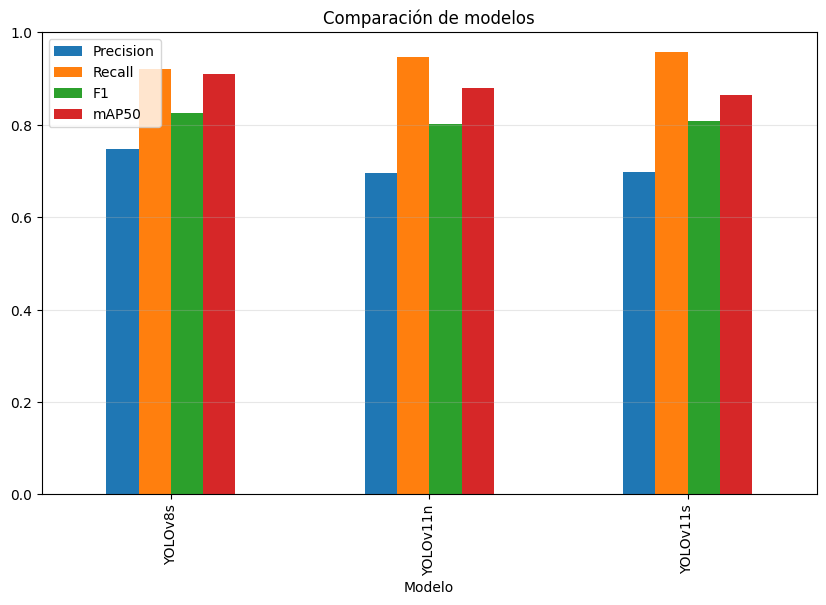

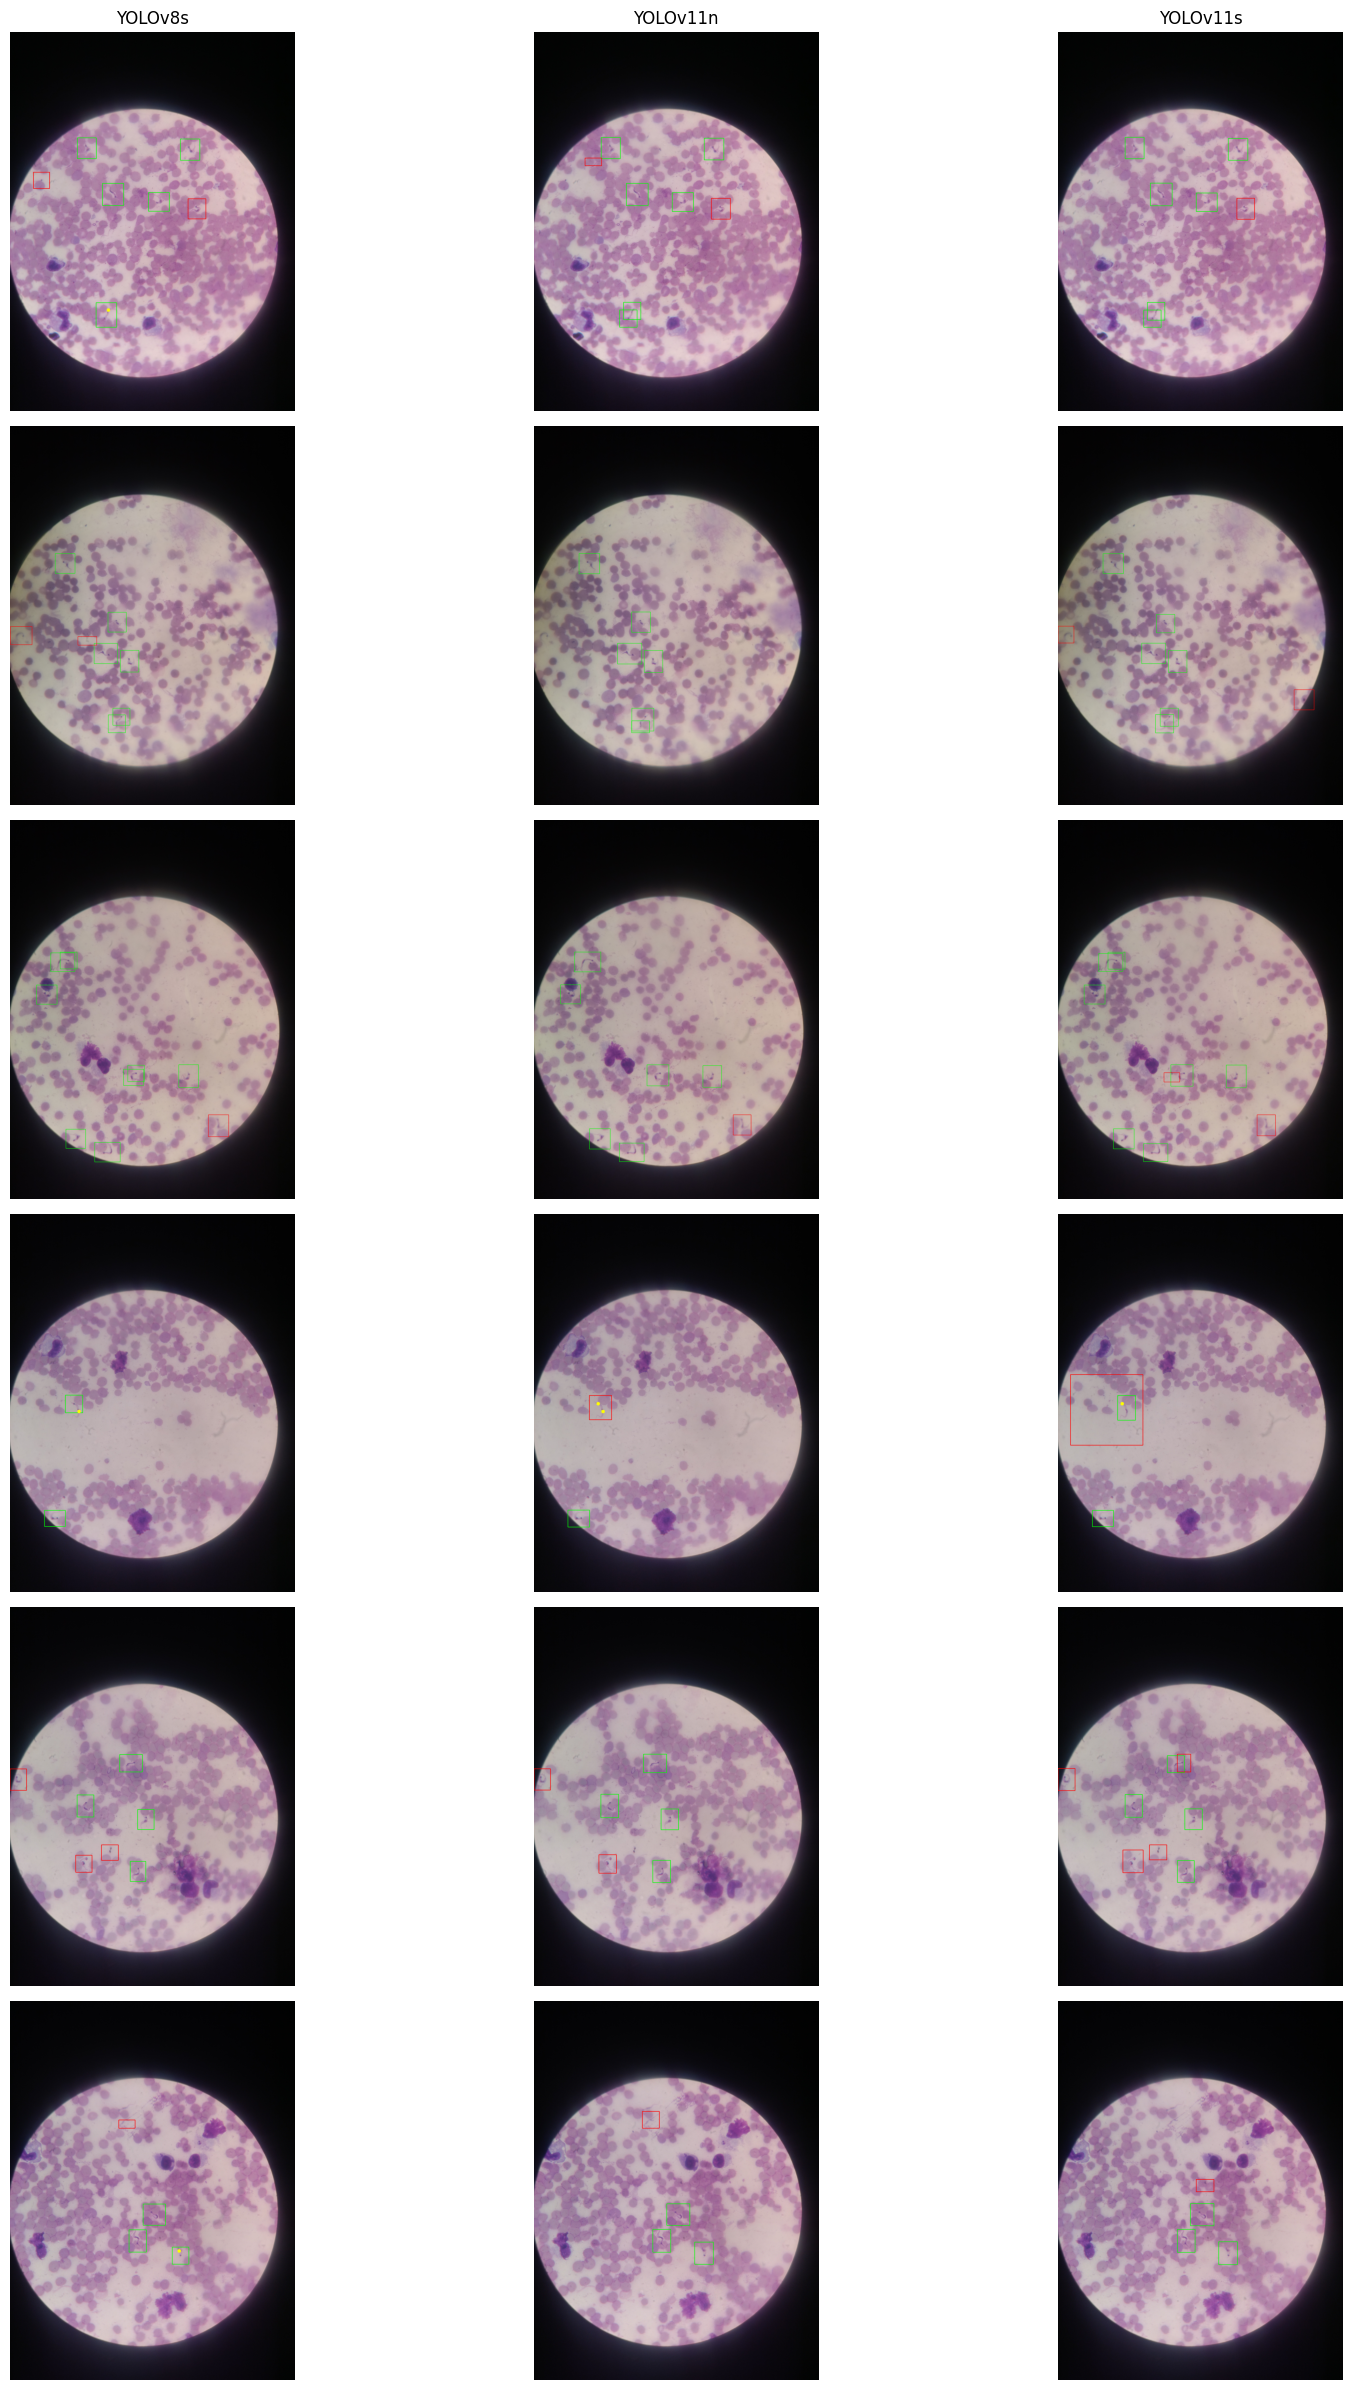

In [ ]:
# ══════════════════════════════════════════════════════════════════
# AID-CV | Fase 4 — Evaluación Formal (105 imágenes test)
# CRISP-ML(Q) — Evaluation
# Métricas:
#   1) Clínica: centro dentro bbox
#   2) Estándar: mAP50 (IoU ≥ 0.5)
# ══════════════════════════════════════════════════════════════════

!pip install sahi ultralytics -q

from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import torch
from pathlib import Path

# ─── RUTAS ────────────────────────────────────────────────────────
BASE      = "/content/drive/MyDrive/P-t.cruzi-AI"
TEST_IMGS = f"{BASE}/dataset/test/images/test"
TEST_LBLS = f"{BASE}/dataset/test/labels"
OUT_DIR   = f"{BASE}/runs/pipeline2_aug/evaluacion_final"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ─── MODELOS ─────────────────────────────────────────────────────
MODELOS = {
    "YOLOv8s" : f"{BASE}/runs/pipeline2_aug/yolov8s_aug/weights/best.pt",
    "YOLOv11n": f"{BASE}/runs/pipeline2_aug/yolo11n_aug/weights/best.pt",
    "YOLOv11s": f"{BASE}/runs/pipeline2_aug/yolo11s_aug/weights/best.pt",
}

CONF_THRESHOLD = 0.25
IOU_THRESHOLD  = 0.5
SEED = 42
random.seed(SEED)

# ─── GT ──────────────────────────────────────────────────────────
def load_gt(lbl_path, img_w, img_h):
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f.read().strip().split("\n"):
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes

# ─── MÉTRICA CLÍNICA ─────────────────────────────────────────────
def point_in_box(px, py, box):
    return box[0] <= px <= box[2] and box[1] <= py <= box[3]

def evaluar_imagen_clinica(pred_boxes, gt_boxes):
    gt_centers = [((b[0]+b[2])/2, (b[1]+b[3])/2) for b in gt_boxes]
    matched_gt = set()
    tp = fp = 0

    for pred in pred_boxes:
        hits = [i for i,(gx,gy) in enumerate(gt_centers)
                if point_in_box(gx, gy, pred[:4])]
        if hits:
            tp += 1
            matched_gt.update(hits)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn

# ─── MÉTRICA IoU ─────────────────────────────────────────────────
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    inter = max(0, xB-xA)*max(0, yB-yA)
    area1 = (box1[2]-box1[0])*(box1[3]-box1[1])
    area2 = (box2[2]-box2[0])*(box2[3]-box2[1])
    return inter/(area1+area2-inter+1e-9)

def extraer_scores_iou(pred_boxes, gt_boxes):
    scores = []
    matched = set()

    for pred in sorted(pred_boxes, key=lambda x: x[4], reverse=True):
        best_iou, best_idx = 0, -1
        for i, gt in enumerate(gt_boxes):
            if i in matched:
                continue
            iou = compute_iou(pred[:4], gt)
            if iou > best_iou:
                best_iou, best_idx = iou, i

        if best_iou >= IOU_THRESHOLD:
            scores.append({"score": pred[4], "tp": 1})
            matched.add(best_idx)
        else:
            scores.append({"score": pred[4], "tp": 0})

    return scores

def compute_ap(scores):
    scores = sorted(scores, key=lambda x: x["score"], reverse=True)
    tp = np.array([s["tp"] for s in scores])
    fp = 1 - tp
    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)
    recall = tp_cum/(tp.sum()+1e-9)
    precision = tp_cum/(tp_cum+fp_cum+1e-9)
    precision = np.maximum.accumulate(precision[::-1])[::-1]
    return np.trapz(precision, recall)

# ─── INFERENCIA ──────────────────────────────────────────────────
def inferencia(img_path, yolo_model, sahi_model):
    result = get_sliced_prediction(
        img_path, sahi_model,
        slice_height=640, slice_width=640,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        postprocess_type="NMM",
        postprocess_match_metric="IOU",
        postprocess_match_threshold=0.3,
        verbose=0
    )
    return [[o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy,
             o.score.value] for o in result.object_prediction_list]



# ─── LOOP PRINCIPAL ───────────────────────────────────────────────
img_files = sorted([f for f in os.listdir(TEST_IMGS) if f.endswith('.jpg')])
tabla_final = []
sample_imgs = random.sample(img_files, 6)
for model_name, model_path in MODELOS.items():
    print(f"\nEvaluando {model_name}")

    yolo_model = YOLO(model_path)
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=model_path,
        confidence_threshold=CONF_THRESHOLD,
        device="cuda:0"
    )

    tp_c = fp_c = fn_c = 0
    all_scores = []

    for filename in img_files:
        img_path = os.path.join(TEST_IMGS, filename)
        lbl_path = os.path.join(TEST_LBLS, filename.replace(".jpg",".txt"))

        img = cv2.imread(img_path)
        h,w = img.shape[:2]

        preds = inferencia(img_path, yolo_model, sahi_model)
        gts   = load_gt(lbl_path, w, h)

        tp, fp, fn = evaluar_imagen_clinica(preds, gts)
        tp_c += tp; fp_c += fp; fn_c += fn

        all_scores.extend(extraer_scores_iou(preds, gts))

    precision = tp_c/(tp_c+fp_c+1e-9)
    recall    = tp_c/(tp_c+fn_c+1e-9)
    f1        = 2*precision*recall/(precision+recall+1e-9)
    ap50      = compute_ap(all_scores)

    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"mAP50 (IoU): {ap50:.4f}")

    tabla_final.append({
        "Modelo": model_name,
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1": round(f1,4),
        "mAP50": round(ap50,4)
    })

df = pd.DataFrame(tabla_final)
print("\nRESULTADOS FINALES")
print(df.to_string(index=False))


df.set_index("Modelo")[["Precision","Recall","F1","mAP50"]].plot(
    kind="bar", figsize=(10,6)
)
plt.title("Comparación de modelos")
plt.ylim(0,1)
plt.grid(axis='y', alpha=0.3)
plt.show()

fig, axes = plt.subplots(len(sample_imgs), 3, figsize=(18, 4*len(sample_imgs)))

for col, (model_name, model_path) in enumerate(MODELOS.items()):
    yolo_model = YOLO(model_path)
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=model_path,
        confidence_threshold=CONF_THRESHOLD,
        device="cuda:0"
    )

    for row, filename in enumerate(sample_imgs):
        img_path = os.path.join(TEST_IMGS, filename)
        lbl_path = os.path.join(TEST_LBLS, filename.replace(".jpg",".txt"))

        img = cv2.imread(img_path)
        h, w = img.shape[:2]

        preds = inferencia(img_path, yolo_model, sahi_model)
        gts   = load_gt(lbl_path, w, h)

        tp_boxes, fp_boxes, fn_centers = [], [], []

        # reutiliza tu lógica visual
        for pred in preds:
            hit = any(compute_iou(pred[:4], gt) >= 0.5 for gt in gts)
            if hit:
                tp_boxes.append(pred)
            else:
                fp_boxes.append(pred)

        for gt in gts:
            if not any(compute_iou(pred[:4], gt) >= 0.5 for pred in preds):
                cx = int((gt[0]+gt[2])/2)
                cy = int((gt[1]+gt[3])/2)
                fn_centers.append((cx,cy))

        img_v = img.copy()

        for b in tp_boxes:
            cv2.rectangle(img_v,(int(b[0]),int(b[1])),
                          (int(b[2]),int(b[3])),(0,255,0),4)

        for b in fp_boxes:
            cv2.rectangle(img_v,(int(b[0]),int(b[1])),
                          (int(b[2]),int(b[3])),(0,0,255),4)

        for (x,y) in fn_centers:
            cv2.circle(img_v,(x,y),15,(0,255,255),-1)

        img_rgb = cv2.cvtColor(img_v, cv2.COLOR_BGR2RGB)

        axes[row, col].imshow(img_rgb)
        axes[row, col].axis('off')

        if row == 0:
            axes[row, col].set_title(model_name)

plt.tight_layout()
plt.show()

FASE 4: Ambas métricas, pero IoU ≥ 0.5 como métrica principal y clínica como métrica de apoyo diagnóstico.


  Evaluando: YOLOv8s


/tmp/ipykernel_648/2382379580.py:151: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(precision, recall))



  [IoU ≥ 0.5]  TP=432  FP=174  FN=439
  [Clínica]    TP=453  FP=153  FN=39
  Precision=0.7129 | Recall=0.4960 | F1=0.5850
  mAP50=0.9098 | mAP50-95=0.3687

  Evaluando: YOLOv11n

  [IoU ≥ 0.5]  TP=435  FP=221  FN=436
  [Clínica]    TP=457  FP=199  FN=26
  Precision=0.6631 | Recall=0.4994 | F1=0.5697
  mAP50=0.8806 | mAP50-95=0.3044

  Evaluando: YOLOv11s

  [IoU ≥ 0.5]  TP=437  FP=241  FN=434
  [Clínica]    TP=473  FP=205  FN=21
  Precision=0.6445 | Recall=0.5017 | F1=0.5642
  mAP50=0.8638 | mAP50-95=0.3012


RESULTADOS FINALES
  Modelo  TP_iou  FP_iou  FN_iou  TP_clin  FP_clin  FN_clin  Precision  Recall     F1  mAP50  mAP50-95
 YOLOv8s     432     174     439      453      153       39     0.7129  0.4960 0.5850 0.9098    0.3687
YOLOv11n     435     221     436      457      199       26     0.6631  0.4994 0.5697 0.8806    0.3044
YOLOv11s     437     241     434      473      205       21     0.6445  0.5017 0.5642 0.8638    0.3012

CSV guardado en: /content/drive/MyDrive/P-t.cruzi-AI

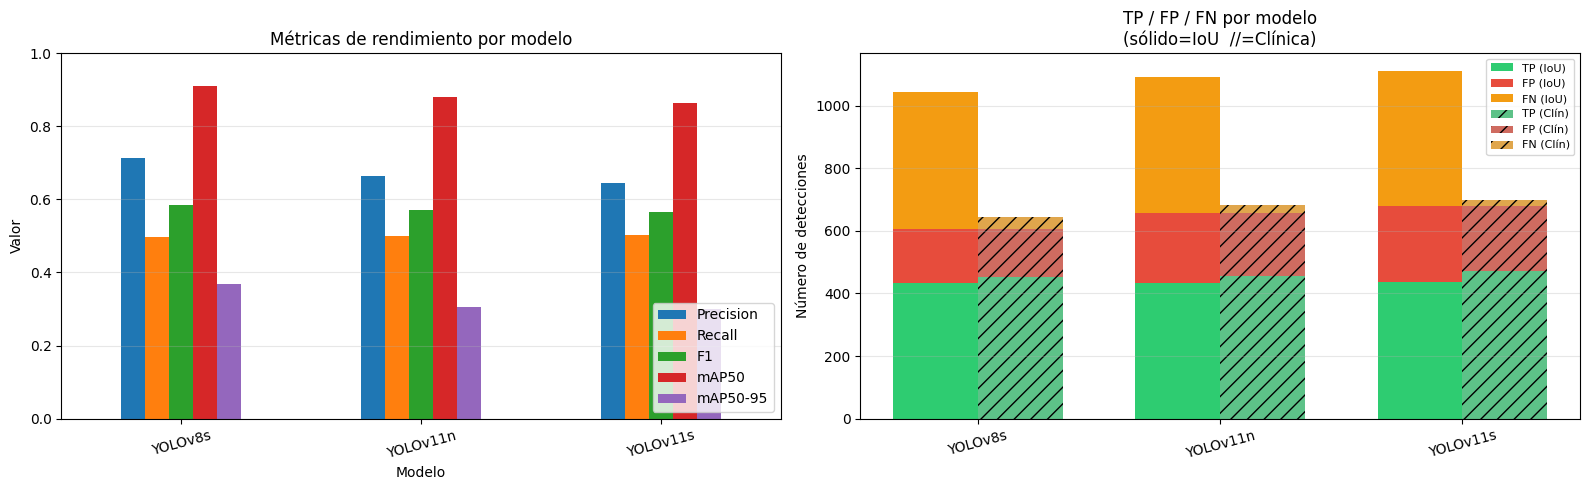

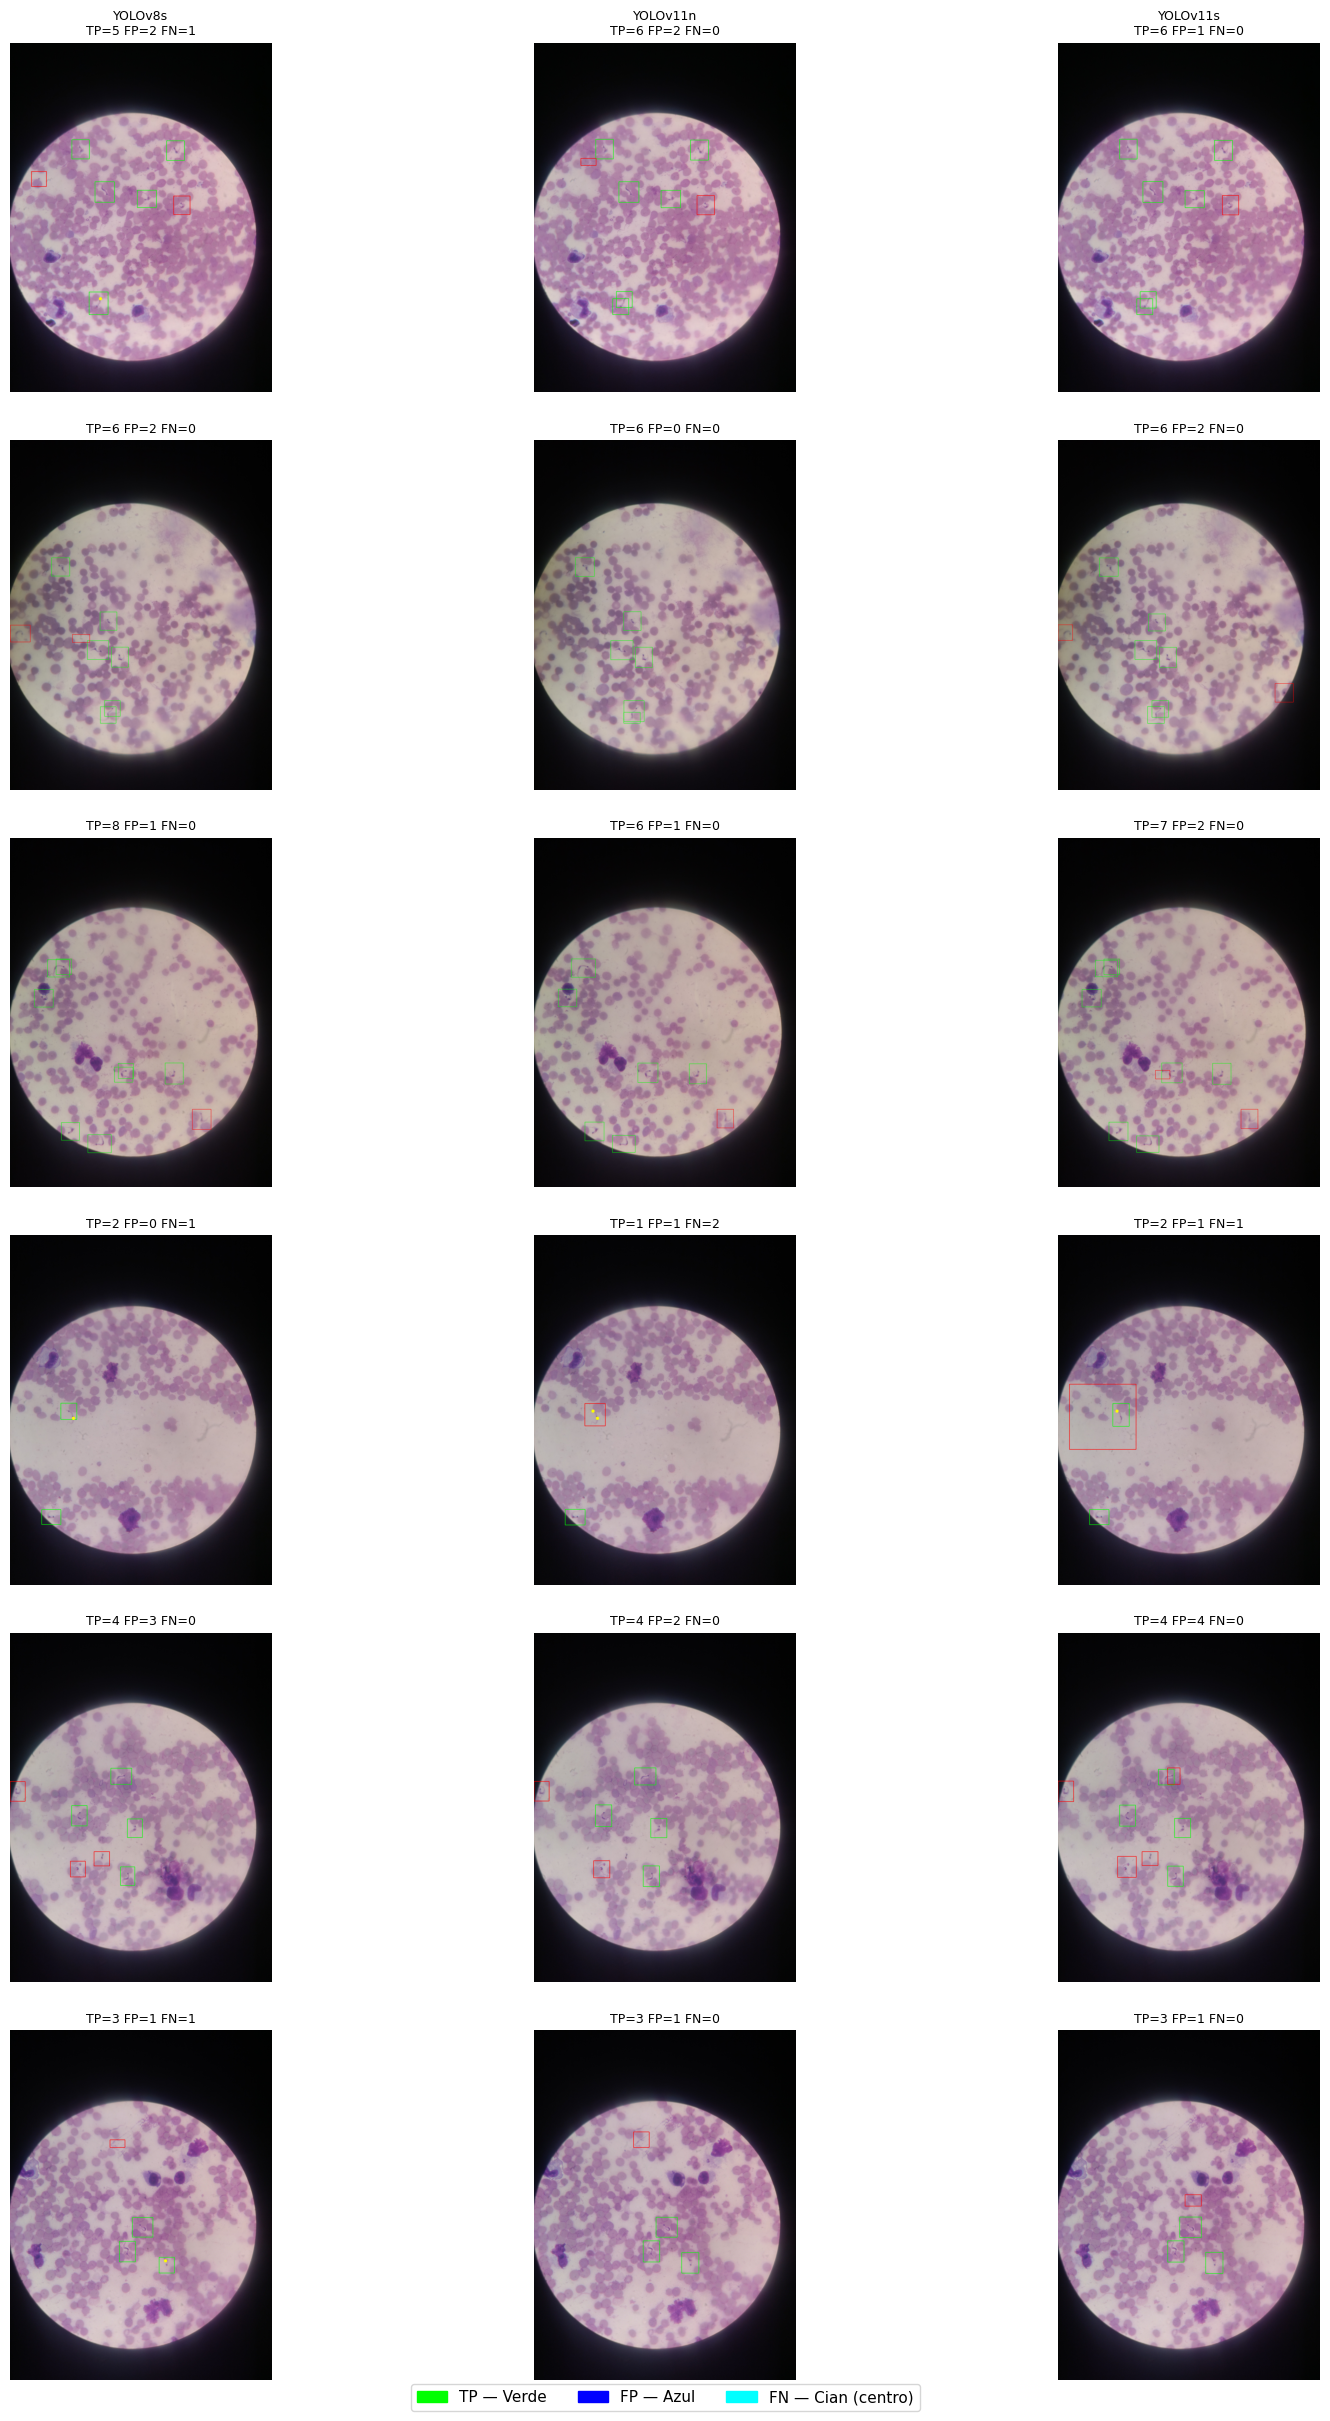

In [ ]:
# ══════════════════════════════════════════════════════════════════
# AID-CV | Fase 4 — Evaluación Formal (105 imágenes test)
# CRISP-ML(Q) — Evaluation
# Métricas principales : TP/FP/FN (IoU≥0.5) + mAP50 + mAP50-95
# Métricas de apoyo    : TP/FP/FN clínica (centro dentro bbox)
# Supervisor: estándar COCO + validación clínica T. cruzi
# ══════════════════════════════════════════════════════════════════

!pip install sahi ultralytics -q

from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import torch
from pathlib import Path

# ─── RUTAS ────────────────────────────────────────────────────────
BASE      = "/content/drive/MyDrive/P-t.cruzi-AI"
TEST_IMGS = f"{BASE}/dataset/test/images/test"
TEST_LBLS = f"{BASE}/dataset/test/labels"
OUT_DIR   = f"{BASE}/runs/pipeline2_aug/evaluacion_final"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ─── MODELOS ──────────────────────────────────────────────────────
MODELOS = {
    "YOLOv8s" : f"{BASE}/runs/pipeline2_aug/yolov8s_aug/weights/best.pt",
    "YOLOv11n": f"{BASE}/runs/pipeline2_aug/yolo11n_aug/weights/best.pt",
    "YOLOv11s": f"{BASE}/runs/pipeline2_aug/yolo11s_aug/weights/best.pt",
}

CONF_THRESHOLD = 0.25
IOU_THRESHOLD  = 0.5
SEED = 42
random.seed(SEED)

# ─── CARGA GT ─────────────────────────────────────────────────────
def load_gt(lbl_path, img_w, img_h):
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f.read().strip().split("\n"):
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes

# ─── IoU ──────────────────────────────────────────────────────────
def compute_iou(box1, box2):
    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    return inter / (area1 + area2 - inter + 1e-9)

# ─── TP / FP / FN — ESTÁNDAR IoU ─────────────────────────────────
def evaluar_iou(pred_boxes, gt_boxes, iou_thresh=0.5):
    """
    Matching greedy por confianza descendente (estándar COCO / Pascal VOC).
    Retorna tp, fp, fn globales de la imagen.
    """
    matched_gt = set()
    tp = fp = 0

    for pred in sorted(pred_boxes, key=lambda x: x[4], reverse=True):
        best_iou, best_idx = 0, -1
        for i, gt in enumerate(gt_boxes):
            if i in matched_gt:
                continue
            iou = compute_iou(pred[:4], gt)
            if iou > best_iou:
                best_iou, best_idx = iou, i
        if best_iou >= iou_thresh:
            tp += 1
            matched_gt.add(best_idx)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn

# ─── TP / FP / FN — CLÍNICA (centro GT dentro bbox pred) ─────────
def evaluar_clinica(pred_boxes, gt_boxes):
    """
    Un GT se considera detectado si su centro cae dentro de
    cualquier bbox predicho (relevante para diagnóstico T. cruzi).
    """
    gt_centers = [((b[0]+b[2])/2, (b[1]+b[3])/2) for b in gt_boxes]
    matched_gt = set()
    tp = fp = 0

    for pred in pred_boxes:
        hits = [i for i, (gx, gy) in enumerate(gt_centers)
                if pred[0] <= gx <= pred[2] and pred[1] <= gy <= pred[3]]
        if hits:
            tp += 1
            matched_gt.update(hits)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn

# ─── SCORES PARA AP (parametrizable por umbral IoU) ───────────────
def extraer_scores_iou(pred_boxes, gt_boxes, iou_thresh=0.5):
    scores = []
    matched = set()

    for pred in sorted(pred_boxes, key=lambda x: x[4], reverse=True):
        best_iou, best_idx = 0, -1
        for i, gt in enumerate(gt_boxes):
            if i in matched:
                continue
            iou = compute_iou(pred[:4], gt)
            if iou > best_iou:
                best_iou, best_idx = iou, i
        if best_iou >= iou_thresh:
            scores.append({"score": pred[4], "tp": 1})
            matched.add(best_idx)
        else:
            scores.append({"score": pred[4], "tp": 0})

    return scores

# ─── AP (área bajo curva P-R) ─────────────────────────────────────
def compute_ap(scores):
    if not scores:
        return 0.0
    scores = sorted(scores, key=lambda x: x["score"], reverse=True)
    tp = np.array([s["tp"] for s in scores])
    fp = 1 - tp
    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)
    recall    = tp_cum / (tp.sum() + 1e-9)
    precision = tp_cum / (tp_cum + fp_cum + 1e-9)
    precision = np.maximum.accumulate(precision[::-1])[::-1]
    return float(np.trapz(precision, recall))

# ─── mAP50-95 ─────────────────────────────────────────────────────
def compute_map50_95(all_preds_gts):
    """
    Promedia AP en umbrales IoU 0.50 → 0.95 (paso 0.05).
    Estándar COCO — obligatorio en publicaciones biomédicas.
    """
    thresholds = np.arange(0.50, 1.00, 0.05)
    aps = []
    for thresh in thresholds:
        scores_thresh = []
        for preds, gts in all_preds_gts:
            scores_thresh.extend(extraer_scores_iou(preds, gts, iou_thresh=thresh))
        aps.append(compute_ap(scores_thresh))
    return float(np.mean(aps))

# ─── INFERENCIA CON SAHI ──────────────────────────────────────────
def inferencia(img_path, sahi_model):
    result = get_sliced_prediction(
        img_path, sahi_model,
        slice_height=640, slice_width=640,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        postprocess_type="NMM",
        postprocess_match_metric="IOU",
        postprocess_match_threshold=0.3,
        verbose=0
    )
    return [[o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy,
             o.score.value] for o in result.object_prediction_list]

# ══════════════════════════════════════════════════════════════════
# LOOP PRINCIPAL
# ══════════════════════════════════════════════════════════════════
img_files  = sorted([f for f in os.listdir(TEST_IMGS) if f.endswith('.jpg')])
sample_imgs = random.sample(img_files, 6)
tabla_final = []

for model_name, model_path in MODELOS.items():
    print(f"\n{'='*55}")
    print(f"  Evaluando: {model_name}")
    print(f"{'='*55}")

    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=model_path,
        confidence_threshold=CONF_THRESHOLD,
        device="cuda:0"
    )

    # Acumuladores IoU estándar
    tp_iou = fp_iou = fn_iou = 0
    all_scores    = []      # para mAP50
    all_preds_gts = []      # para mAP50-95

    # Acumuladores clínicos
    tp_clin = fp_clin = fn_clin = 0

    for filename in img_files:
        img_path = os.path.join(TEST_IMGS, filename)
        lbl_path = os.path.join(TEST_LBLS, filename.replace(".jpg", ".txt"))

        img  = cv2.imread(img_path)
        h, w = img.shape[:2]

        preds = inferencia(img_path, sahi_model)
        gts   = load_gt(lbl_path, w, h)

        # — Métrica estándar IoU —
        tp, fp, fn = evaluar_iou(preds, gts, iou_thresh=IOU_THRESHOLD)
        tp_iou += tp; fp_iou += fp; fn_iou += fn

        all_scores.extend(extraer_scores_iou(preds, gts))
        all_preds_gts.append((preds, gts))

        # — Métrica clínica —
        tp, fp, fn = evaluar_clinica(preds, gts)
        tp_clin += tp; fp_clin += fp; fn_clin += fn

    # ─── Métricas globales ────────────────────────────────────────
    precision = tp_iou / (tp_iou + fp_iou + 1e-9)
    recall    = tp_iou / (tp_iou + fn_iou + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    ap50      = compute_ap(all_scores)
    map5095   = compute_map50_95(all_preds_gts)

    print(f"\n  [IoU ≥ 0.5]  TP={tp_iou}  FP={fp_iou}  FN={fn_iou}")
    print(f"  [Clínica]    TP={tp_clin}  FP={fp_clin}  FN={fn_clin}")
    print(f"  Precision={precision:.4f} | Recall={recall:.4f} | F1={f1:.4f}")
    print(f"  mAP50={ap50:.4f} | mAP50-95={map5095:.4f}")

    tabla_final.append({
        "Modelo"    : model_name,
        # Estándar IoU
        "TP_iou"    : tp_iou,
        "FP_iou"    : fp_iou,
        "FN_iou"    : fn_iou,
        # Clínica
        "TP_clin"   : tp_clin,
        "FP_clin"   : fp_clin,
        "FN_clin"   : fn_clin,
        # Métricas derivadas (base IoU)
        "Precision" : round(precision, 4),
        "Recall"    : round(recall,    4),
        "F1"        : round(f1,        4),
        "mAP50"     : round(ap50,      4),
        "mAP50-95"  : round(map5095,   4),
    })

# ══════════════════════════════════════════════════════════════════
# TABLA FINAL
# ══════════════════════════════════════════════════════════════════
df = pd.DataFrame(tabla_final)
print("\n\nRESULTADOS FINALES")
print(df.to_string(index=False))

# Guardar CSV
csv_path = os.path.join(OUT_DIR, "resultados_evaluacion.csv")
df.to_csv(csv_path, index=False)
print(f"\nCSV guardado en: {csv_path}")

# ══════════════════════════════════════════════════════════════════
# GRÁFICO 1 — Métricas por modelo
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel izquierdo: Precision / Recall / F1 / mAP50 / mAP50-95
metricas_cols = ["Precision", "Recall", "F1", "mAP50", "mAP50-95"]
df.set_index("Modelo")[metricas_cols].plot(
    kind="bar", ax=axes[0], ylim=(0, 1)
)
axes[0].set_title("Métricas de rendimiento por modelo")
axes[0].set_ylabel("Valor")
axes[0].set_xticklabels(df["Modelo"], rotation=15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(loc="lower right")

# Panel derecho: TP / FP / FN barras apiladas (IoU estándar)
x      = np.arange(len(df))
width  = 0.35
bars_iou  = axes[1].bar(x - width/2, df["TP_iou"],  width, label="TP (IoU)",   color="#2ecc71")
bars_fp   = axes[1].bar(x - width/2, df["FP_iou"],  width, label="FP (IoU)",   color="#e74c3c",
                         bottom=df["TP_iou"])
bars_fn   = axes[1].bar(x - width/2, df["FN_iou"],  width, label="FN (IoU)",   color="#f39c12",
                         bottom=df["TP_iou"] + df["FP_iou"])

bars_tp_c = axes[1].bar(x + width/2, df["TP_clin"], width, label="TP (Clín)", color="#27ae60",
                         alpha=0.75, hatch="//")
bars_fp_c = axes[1].bar(x + width/2, df["FP_clin"], width, label="FP (Clín)", color="#c0392b",
                         alpha=0.75, hatch="//",
                         bottom=df["TP_clin"])
bars_fn_c = axes[1].bar(x + width/2, df["FN_clin"], width, label="FN (Clín)", color="#d68910",
                         alpha=0.75, hatch="//",
                         bottom=df["TP_clin"] + df["FP_clin"])

axes[1].set_title("TP / FP / FN por modelo\n(sólido=IoU  //=Clínica)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(df["Modelo"], rotation=15)
axes[1].set_ylabel("Número de detecciones")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "metricas_comparacion.png"), dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════
# GRÁFICO 2 — Visualización cualitativa (6 imágenes × 3 modelos)
# ══════════════════════════════════════════════════════════════════
fig, axes_v = plt.subplots(len(sample_imgs), 3,
                            figsize=(18, 4 * len(sample_imgs)))

for col, (model_name, model_path) in enumerate(MODELOS.items()):
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=model_path,
        confidence_threshold=CONF_THRESHOLD,
        device="cuda:0"
    )

    for row, filename in enumerate(sample_imgs):
        img_path = os.path.join(TEST_IMGS, filename)
        lbl_path = os.path.join(TEST_LBLS, filename.replace(".jpg", ".txt"))

        img  = cv2.imread(img_path)
        h, w = img.shape[:2]

        preds = inferencia(img_path, sahi_model)
        gts   = load_gt(lbl_path, w, h)

        tp_boxes, fp_boxes, fn_centers = [], [], []

        for pred in preds:
            hit = any(compute_iou(pred[:4], gt) >= IOU_THRESHOLD for gt in gts)
            if hit:
                tp_boxes.append(pred)
            else:
                fp_boxes.append(pred)

        for gt in gts:
            if not any(compute_iou(pred[:4], gt) >= IOU_THRESHOLD for pred in preds):
                cx = int((gt[0] + gt[2]) / 2)
                cy = int((gt[1] + gt[3]) / 2)
                fn_centers.append((cx, cy))

        img_v = img.copy()
        for b in tp_boxes:
            cv2.rectangle(img_v, (int(b[0]), int(b[1])),
                          (int(b[2]), int(b[3])), (0, 255, 0), 4)
        for b in fp_boxes:
            cv2.rectangle(img_v, (int(b[0]), int(b[1])),
                          (int(b[2]), int(b[3])), (0, 0, 255), 4)
        for (x, y) in fn_centers:
            cv2.circle(img_v, (x, y), 15, (0, 255, 255), -1)

        img_rgb = cv2.cvtColor(img_v, cv2.COLOR_BGR2RGB)
        axes_v[row, col].imshow(img_rgb)
        axes_v[row, col].axis('off')

        tp_n = len(tp_boxes)
        fp_n = len(fp_boxes)
        fn_n = len(fn_centers)
        axes_v[row, col].set_title(
            f"{model_name if row == 0 else ''}\nTP={tp_n} FP={fp_n} FN={fn_n}",
            fontsize=9
        )

# Leyenda global
legend_elements = [
    mpatches.Patch(color=(0,1,0),   label="TP — Verde"),
    mpatches.Patch(color=(0,0,1),   label="FP — Azul"),
    mpatches.Patch(color=(0,1,1),   label="FN — Cian (centro)"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "visualizacion_cualitativa.png"),
            dpi=150, bbox_inches="tight")
plt.show()

Figura 1 — Curvas P-R individuales por modelo
→ muestra el tradeoff precision/recall de cada uno
→ dos puntos marcados: F1 óptimo y Fb2 óptimo

Figura 2 — Curvas P-R superpuestas
→ comparación directa entre los 3 modelos
→ figura lista para incluir en el paper

Figura 3 — F1 y Fb2 vs Threshold
→ justifica científicamente el threshold elegido
→ el threshold médico (Fb2) prioriza no perder parásitos

Tabla threshold óptimo
→ para cada modelo: threshold recomendado según criterio
→ base para configurar conf en producción de AID-CV


  Recolectando predicciones: YOLOv8s...
    Predicciones recolectadas: 2074 | GT total: 871

  Recolectando predicciones: YOLOv11n...
    Predicciones recolectadas: 2063 | GT total: 871

  Recolectando predicciones: YOLOv11s...
    Predicciones recolectadas: 2994 | GT total: 871

  AID-CV | Threshold Óptimo por Modelo

  F1 estándar (equilibrio P y R):
  YOLOv8s    → thresh=0.376 | P=0.8089 R=0.5006 F1=0.6184
  YOLOv11n   → thresh=0.504 | P=0.7932 R=0.5063 F1=0.6181
  YOLOv11s   → thresh=0.348 | P=0.7467 R=0.5178 F1=0.6115

  F-beta2 (prioriza Recall — contexto médico):
  YOLOv8s    → thresh=0.127 | P=0.6356 R=0.5408 Fb2=0.5574
  YOLOv11n   → thresh=0.148 | P=0.6268 R=0.5362 Fb2=0.5521
  YOLOv11s   → thresh=0.143 | P=0.6003 R=0.5499 Fb2=0.5593


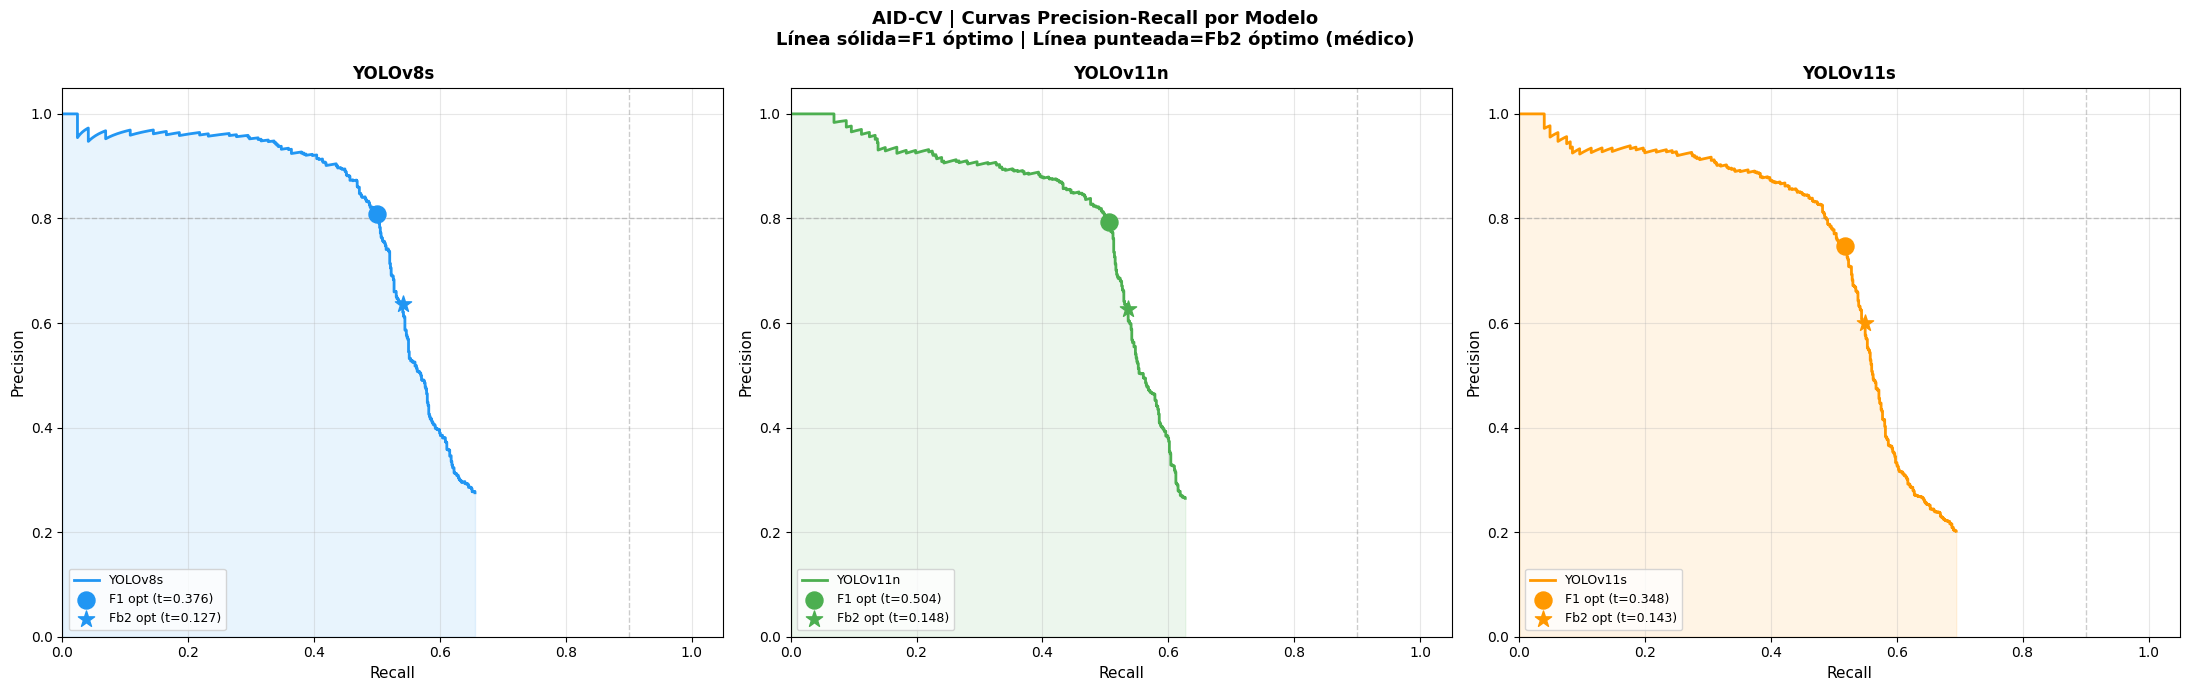

📊 Guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/evaluacion_final/curvas_PR_comparativas.png


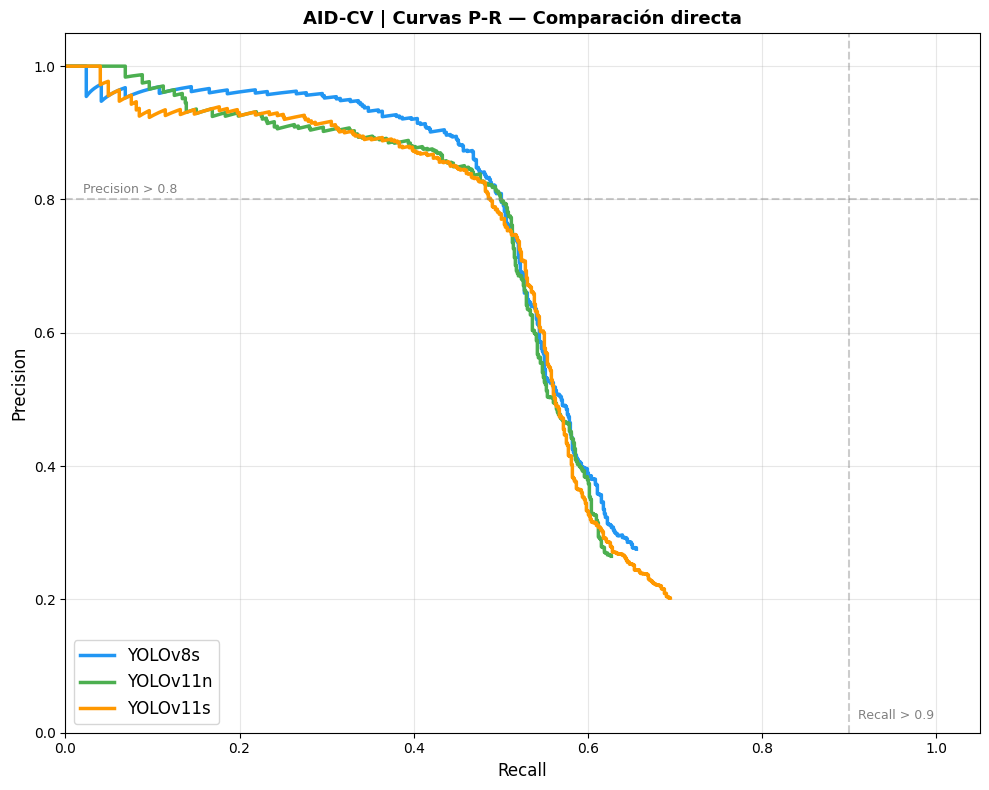

📊 Guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/evaluacion_final/curvas_PR_superpuestas.png


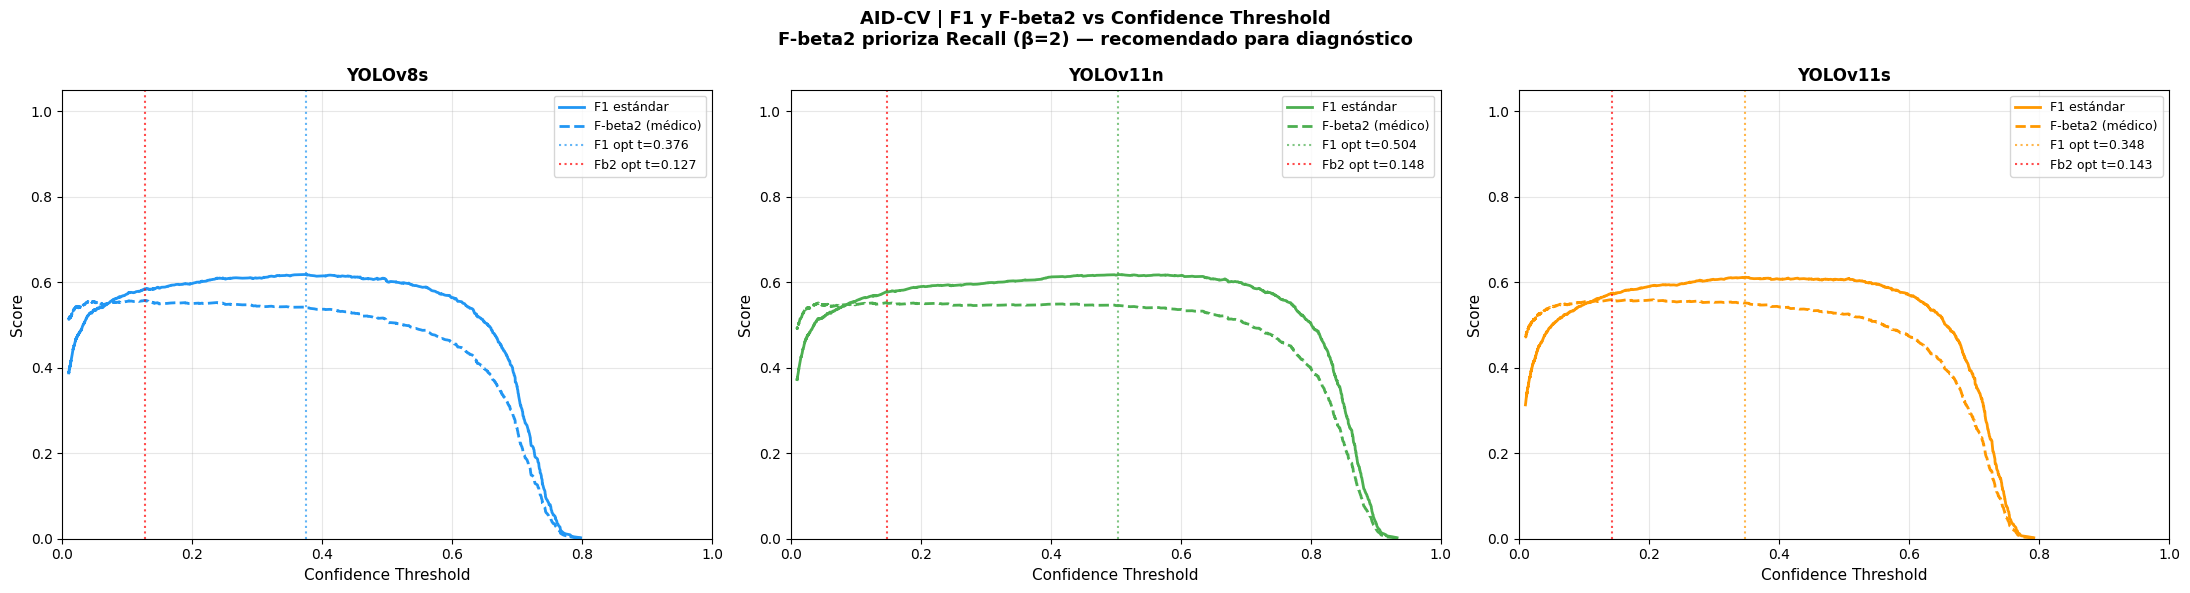

📊 Guardado: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/evaluacion_final/f1_fbeta_vs_threshold.png

  AID-CV | Fase 5 Completada — Evaluación Final

  Archivos generados en /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/evaluacion_final:

  Bloque 1 — Evaluación formal (105 imágenes test):
  → tabla_evaluacion_final.csv
  → YOLOv8s_detecciones.png
  → YOLOv11n_detecciones.png
  → YOLOv11s_detecciones.png
  → comparativa_barras.png

  Bloque 2 — Evaluación de robustez:
  → robustez_test-add-1.png  (200×200px)
  → robustez_test-add-2.png  (1024×1030px)

  Bloque 3 — Curvas P-R y threshold:
  → curvas_PR_comparativas.png
  → curvas_PR_superpuestas.png
  → f1_fbeta_vs_threshold.png
  → tabla_threshold_optimo.csv



In [ ]:
# ══════════════════════════════════════════════════════════════════
# AID-CV | Fase 4.2— Curva P-R y Threshold Óptimo
# ══════════════════════════════════════════════════════════════════
!pip install ultralytics


from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import torch

# ─── RUTAS ────────────────────────────────────────────────────────
BASE      = "/content/drive/MyDrive/P-t.cruzi-AI"
TEST_IMGS = f"{BASE}/dataset/test/images/test"
TEST_LBLS = f"{BASE}/dataset/test/labels"
OUT_DIR   = f"{BASE}/runs/pipeline2_aug/evaluacion_final"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

MODELOS = {
    "YOLOv8s" : f"{BASE}/runs/pipeline2_aug/yolov8s_aug/weights/best.pt",
    "YOLOv11n": f"{BASE}/runs/pipeline2_aug/yolo11n_aug/weights/best.pt",
    "YOLOv11s": f"{BASE}/runs/pipeline2_aug/yolo11s_aug/weights/best.pt",
}

LARGE_IMG_THR = 1280
COLORES       = {"YOLOv8s": "#2196F3", "YOLOv11n": "#4CAF50", "YOLOv11s": "#FF9800"}

# ─── FUNCIONES BASE ───────────────────────────────────────────────
def load_gt(lbl_path, img_w, img_h):
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f.read().strip().split("\n"):
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes

def point_in_box(px, py, box):
    return box[0] <= px <= box[2] and box[1] <= py <= box[3]

def inferencia_completa(img_path, yolo_model, sahi_model, img_w, img_h,
                        conf=0.01):
    """Conf muy baja para capturar todas las predicciones para la curva P-R"""
    if max(img_w, img_h) > LARGE_IMG_THR:
        result = get_sliced_prediction(
            img_path, sahi_model,
            slice_height=640, slice_width=640,
            overlap_height_ratio=0.2, overlap_width_ratio=0.2,
            postprocess_type="NMM",
            postprocess_match_metric="IOU",
            postprocess_match_threshold=0.3,
            verbose=0
        )
        return [[o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy,
                 o.score.value] for o in result.object_prediction_list]
    else:
        img = cv2.imread(img_path)
        results = yolo_model.predict(
            source=img, imgsz=640,
            conf=conf, device=0, verbose=False
        )
        return [[*b.xyxy[0].cpu().numpy(), b.conf[0].item()]
                for b in results[0].boxes]

# ─── RECOLECTAR PREDICCIONES POR MODELO ──────────────────────────
img_files   = sorted([f for f in os.listdir(TEST_IMGS) if f.endswith('.jpg')])
total_gt    = 0
data_modelos = {}

for model_name, model_path in MODELOS.items():
    print(f"\n  Recolectando predicciones: {model_name}...")

    yolo_model = YOLO(model_path)
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type           = "ultralytics",
        model_path           = model_path,
        confidence_threshold = 0.01,
        device               = "cuda:0"
    )

    all_preds = []   # (score, is_tp)
    gt_total  = 0

    for filename in img_files:
        img_path = os.path.join(TEST_IMGS, filename)
        lbl_path = os.path.join(TEST_LBLS,
                                os.path.splitext(filename)[0] + ".txt")

        img      = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]
        gt_boxes = load_gt(lbl_path, img_w, img_h)
        gt_total += len(gt_boxes)

        pred_boxes = inferencia_completa(
            img_path, yolo_model, sahi_model, img_w, img_h, conf=0.01
        )

        gt_centers  = [((b[0]+b[2])/2, (b[1]+b[3])/2) for b in gt_boxes]
        matched_gt  = set()

        # Ordenar por confianza descendente
        pred_boxes_sorted = sorted(pred_boxes, key=lambda x: x[4], reverse=True)

        for pred in pred_boxes_sorted:
            hits = [i for i, (px, py) in enumerate(gt_centers)
                    if point_in_box(px, py, pred[:4]) and i not in matched_gt]
            if hits:
                matched_gt.add(hits[0])
                all_preds.append((pred[4], 1))  # TP
            else:
                all_preds.append((pred[4], 0))  # FP

    data_modelos[model_name] = {
        "preds"   : all_preds,
        "gt_total": gt_total
    }

    del yolo_model, sahi_model
    torch.cuda.empty_cache()
    print(f"    Predicciones recolectadas: {len(all_preds)} | GT total: {gt_total}")

# ─── CALCULAR CURVAS P-R POR MODELO ──────────────────────────────
def calcular_pr_curve(preds, gt_total):
    """Calcula curva P-R barriendo thresholds"""
    preds_sorted = sorted(preds, key=lambda x: x[0], reverse=True)
    scores = [p[0] for p in preds_sorted]
    labels = [p[1] for p in preds_sorted]

    precisions  = []
    recalls     = []
    thresholds  = []
    f1_scores   = []

    tp = fp = 0
    fn = gt_total

    for i, (score, label) in enumerate(zip(scores, labels)):
        if label == 1:
            tp += 1
            fn -= 1
        else:
            fp += 1

        p  = tp / (tp + fp + 1e-9)
        r  = tp / (tp + fn + 1e-9)
        f1 = 2 * p * r / (p + r + 1e-9)

        precisions.append(p)
        recalls.append(r)
        thresholds.append(score)
        f1_scores.append(f1)

    return np.array(precisions), np.array(recalls), \
           np.array(thresholds), np.array(f1_scores)

# ─── THRESHOLD ÓPTIMO — PRIORIZA RECALL (contexto médico) ────────
# F1 estándar equilibra P y R
# Para diagnóstico médico usamos F_beta con beta=2
# → penaliza más los FN que los FP
# → recall tiene el doble de peso que precision
def fbeta(precision, recall, beta=2):
    return (1 + beta**2) * precision * recall / \
           (beta**2 * precision + recall + 1e-9)

# ─── TABLA THRESHOLD ÓPTIMO ───────────────────────────────────────
tabla_threshold = []
curvas          = {}

for model_name, data in data_modelos.items():
    P, R, T, F1 = calcular_pr_curve(data['preds'], data['gt_total'])
    Fb           = fbeta(P, R, beta=2)

    # Threshold óptimo F1 estándar
    best_f1_idx  = np.argmax(F1)
    # Threshold óptimo F_beta2 (prioriza recall)
    best_fb_idx  = np.argmax(Fb)

    curvas[model_name] = {"P": P, "R": R, "T": T, "F1": F1, "Fb": Fb}

    tabla_threshold.append({
        "Modelo"          : model_name,
        "Thresh F1 óptimo": round(T[best_f1_idx], 3),
        "P@F1opt"         : round(P[best_f1_idx], 4),
        "R@F1opt"         : round(R[best_f1_idx], 4),
        "F1 óptimo"       : round(F1[best_f1_idx], 4),
        "Thresh Fb2 óptimo": round(T[best_fb_idx], 3),
        "P@Fb2opt"        : round(P[best_fb_idx], 4),
        "R@Fb2opt"        : round(R[best_fb_idx], 4),
        "Fb2 óptimo"      : round(Fb[best_fb_idx], 4),
    })

df_thresh = pd.DataFrame(tabla_threshold)
df_thresh.to_csv(f"{OUT_DIR}/tabla_threshold_optimo.csv", index=False)

print(f"\n{'='*70}")
print(f"  AID-CV | Threshold Óptimo por Modelo")
print(f"{'='*70}")
print(f"\n  F1 estándar (equilibrio P y R):")
for _, row in df_thresh.iterrows():
    print(f"  {row['Modelo']:10s} → thresh={row['Thresh F1 óptimo']} | "
          f"P={row['P@F1opt']} R={row['R@F1opt']} F1={row['F1 óptimo']}")

print(f"\n  F-beta2 (prioriza Recall — contexto médico):")
for _, row in df_thresh.iterrows():
    print(f"  {row['Modelo']:10s} → thresh={row['Thresh Fb2 óptimo']} | "
          f"P={row['P@Fb2opt']} R={row['R@Fb2opt']} Fb2={row['Fb2 óptimo']}")
print(f"{'='*70}")

# ─── FIGURA 1 — Curvas P-R comparativas ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("AID-CV | Curvas Precision-Recall por Modelo\n"
             "Línea sólida=F1 óptimo | Línea punteada=Fb2 óptimo (médico)",
             fontsize=13, fontweight='bold')

for idx, (model_name, c) in enumerate(curvas.items()):
    ax    = axes[idx]
    color = COLORES[model_name]
    row   = df_thresh[df_thresh['Modelo'] == model_name].iloc[0]

    ax.plot(c['R'], c['P'], color=color, linewidth=2, label=model_name)
    ax.fill_between(c['R'], c['P'], alpha=0.1, color=color)

    # Punto F1 óptimo
    f1_idx = np.argmax(c['F1'])
    ax.scatter(c['R'][f1_idx], c['P'][f1_idx],
               color=color, s=150, zorder=5,
               label=f"F1 opt (t={row['Thresh F1 óptimo']})")

    # Punto Fb2 óptimo
    fb_idx = np.argmax(c['Fb'])
    ax.scatter(c['R'][fb_idx], c['P'][fb_idx],
               color=color, s=150, marker='*', zorder=5,
               label=f"Fb2 opt (t={row['Thresh Fb2 óptimo']})")

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall", fontsize=11)
    ax.set_ylabel("Precision", fontsize=11)
    ax.set_title(f"{model_name}", fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Líneas de referencia
    ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.4, linewidth=1)

plt.tight_layout()
out_pr = f"{OUT_DIR}/curvas_PR_comparativas.png"
plt.savefig(out_pr, dpi=120, bbox_inches='tight')
plt.show()
print(f"📊 Guardado: {out_pr}")

# ─── FIGURA 2 — Curvas P-R superpuestas ───────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title("AID-CV | Curvas P-R — Comparación directa",
             fontsize=13, fontweight='bold')

for model_name, c in curvas.items():
    ax.plot(c['R'], c['P'],
            color=COLORES[model_name],
            linewidth=2.5, label=model_name)

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4)
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.4)
ax.text(0.91, 0.02, "Recall > 0.9", fontsize=9, color='gray')
ax.text(0.02, 0.81, "Precision > 0.8", fontsize=9, color='gray')

plt.tight_layout()
out_pr2 = f"{OUT_DIR}/curvas_PR_superpuestas.png"
plt.savefig(out_pr2, dpi=120, bbox_inches='tight')
plt.show()
print(f"📊 Guardado: {out_pr2}")

# ─── FIGURA 3 — F1 y Fb2 vs Threshold por modelo ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle("AID-CV | F1 y F-beta2 vs Confidence Threshold\n"
             "F-beta2 prioriza Recall (β=2) — recomendado para diagnóstico",
             fontsize=13, fontweight='bold')

for idx, (model_name, c) in enumerate(curvas.items()):
    ax    = axes[idx]
    color = COLORES[model_name]
    row   = df_thresh[df_thresh['Modelo'] == model_name].iloc[0]

    ax.plot(c['T'], c['F1'], color=color,
            linewidth=2, label='F1 estándar')
    ax.plot(c['T'], c['Fb'], color=color,
            linewidth=2, linestyle='--', label='F-beta2 (médico)')

    # Marcar thresholds óptimos
    f1_idx = np.argmax(c['F1'])
    fb_idx = np.argmax(c['Fb'])

    ax.axvline(x=c['T'][f1_idx], color=color,
               linestyle=':', alpha=0.7,
               label=f"F1 opt t={row['Thresh F1 óptimo']}")
    ax.axvline(x=c['T'][fb_idx], color='red',
               linestyle=':', alpha=0.7,
               label=f"Fb2 opt t={row['Thresh Fb2 óptimo']}")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Confidence Threshold", fontsize=11)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(f"{model_name}", fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_f1 = f"{OUT_DIR}/f1_fbeta_vs_threshold.png"
plt.savefig(out_f1, dpi=120, bbox_inches='tight')
plt.show()
print(f"📊 Guardado: {out_f1}")

# ─── REPORTE FINAL COMPLETO ───────────────────────────────────────
print(f"\n{'='*70}")
print(f"  AID-CV | Fase 5 Completada — Evaluación Final")
print(f"{'='*70}")
print(f"""
  Archivos generados en {OUT_DIR}:

  Bloque 1 — Evaluación formal (105 imágenes test):
  → tabla_evaluacion_final.csv
  → YOLOv8s_detecciones.png
  → YOLOv11n_detecciones.png
  → YOLOv11s_detecciones.png
  → comparativa_barras.png

  Bloque 2 — Evaluación de robustez:
  → robustez_test-add-1.png  (200×200px)
  → robustez_test-add-2.png  (1024×1030px)

  Bloque 3 — Curvas P-R y threshold:
  → curvas_PR_comparativas.png
  → curvas_PR_superpuestas.png
  → f1_fbeta_vs_threshold.png
  → tabla_threshold_optimo.csv
""")
print(f"{'='*70}")

In [ ]:
# ══════════════════════════════════════════════════════════════════
# FIGURE — Overlapping P-R curves (combined, production point marked)
# ══════════════════════════════════════════════════════════════════

PROD_THRESH = 0.25  # ajusta al threshold real usado en SAHI

fig, ax = plt.subplots(figsize=(8, 7))

for model_name, c in curvas.items():
    ax.plot(c['R'], c['P'],
            color=COLORS[model_name],
            linewidth=2.5, label=model_name)

    # Punto de operación en producción
    idx_prod = np.argmin(np.abs(c['T'] - PROD_THRESH))
    ax.scatter(c['R'][idx_prod], c['P'][idx_prod],
               color=COLORS[model_name], s=120,
               marker='D', zorder=6)

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Recall", fontsize=16)
ax.set_ylabel("Precision", fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.set_title("Precision-Recall Curves — Model Comparison",
             fontsize=15, fontweight='bold')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4)
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.4)
ax.text(0.91, 0.03, "Recall > 0.9", fontsize=13, color='gray')
ax.text(0.03, 0.81, "Precision > 0.8", fontsize=13, color='gray')
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out = f"{OUT_DIR}/pr_curves_combined.png"
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.close()
print(f"Saved: {out}")

Saved: /content/drive/MyDrive/P-t.cruzi-AI/runs/pipeline2_aug/pr_curves_individual/pr_curves_combined.png


In [ ]:
!pip install sahi ultralytics -q

from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2
import numpy as np
from pathlib import Path
from google.colab import files

# ─── RUTAS ────────────────────────────────────────────────────────
BASE       = "/content/drive/MyDrive/P-t.cruzi-AI"
IMG_PATH   = f"{BASE}/dataset/test/images/test/field0631.jpg"
MODEL_PATH = f"{BASE}/runs/pipeline2/yolov8s_p2/weights/best.pt"
OUT_DIR    = f"{BASE}/runs/pipeline2/poster"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

CONF_THRESHOLD = 0.25
LARGE_IMG_THR  = 1280
PADDING        = 80   # px extra alrededor del recorte

# ─── CARGA DE MODELO ──────────────────────────────────────────────
yolo_model = YOLO(MODEL_PATH)
sahi_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=CONF_THRESHOLD,
    device="cuda:0"
)

# ─── INFERENCIA ADAPTATIVA ────────────────────────────────────────
img    = cv2.imread(IMG_PATH)
img_h, img_w = img.shape[:2]
print(f"Imagen: {img_w}×{img_h}px")

if max(img_w, img_h) > LARGE_IMG_THR:
    print("→ SAHI activado")
    result = get_sliced_prediction(
        IMG_PATH, sahi_model,
        slice_height=640, slice_width=640,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        postprocess_type="NMM",
        postprocess_match_metric="IOU",
        postprocess_match_threshold=0.3,
        verbose=0
    )
    pred_boxes = [[o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy, o.score.value]
                  for o in result.object_prediction_list]
else:
    print("→ Inferencia directa")
    results = yolo_model.predict(source=img, imgsz=640,
                                  conf=CONF_THRESHOLD, device=0, verbose=False)
    pred_boxes = [[*box.xyxy[0].cpu().numpy(), box.conf[0].item()]
                  for box in results[0].boxes]

print(f"Detecciones totales: {len(pred_boxes)}")

# ─── ENCONTRAR REGIÓN CON MAYOR DENSIDAD (3+ parásitos juntos) ───
# Calculamos el centro de cada detección
centros = np.array([[(b[0]+b[2])/2, (b[1]+b[3])/2] for b in pred_boxes])

mejor_idx   = 0
mejor_count = 0
VENTANA     = 800  # px — tamaño de ventana de búsqueda

for i, (cx, cy) in enumerate(centros):
    # Cuántas detecciones caen dentro de una ventana de VENTANA×VENTANA
    count = sum(
        abs(centros[j][0] - cx) < VENTANA/2 and
        abs(centros[j][1] - cy) < VENTANA/2
        for j in range(len(centros))
    )
    if count > mejor_count:
        mejor_count = count
        mejor_idx   = i

print(f"Región más densa: {mejor_count} detecciones alrededor de bbox #{mejor_idx}")

# ─── DEFINIR RECORTE ──────────────────────────────────────────────
# Tomar los índices de detecciones dentro de la mejor ventana
cx_ref, cy_ref = centros[mejor_idx]
indices_region = [
    i for i, (cx, cy) in enumerate(centros)
    if abs(cx - cx_ref) < VENTANA/2 and abs(cy - cy_ref) < VENTANA/2
]

# Tomar solo las primeras 3–5 más cercanas al centro
distancias = sorted(indices_region,
                    key=lambda i: abs(centros[i][0]-cx_ref) + abs(centros[i][1]-cy_ref))
indices_recorte = distancias[:5]

# Bounding box del recorte (engloba todas las detecciones seleccionadas)
x1_crop = int(min(pred_boxes[i][0] for i in indices_recorte)) - PADDING
y1_crop = int(min(pred_boxes[i][1] for i in indices_recorte)) - PADDING
x2_crop = int(max(pred_boxes[i][2] for i in indices_recorte)) + PADDING
y2_crop = int(max(pred_boxes[i][3] for i in indices_recorte)) + PADDING

# Clamp a bordes de imagen
x1_crop = max(0, x1_crop)
y1_crop = max(0, y1_crop)
x2_crop = min(img_w, x2_crop)
y2_crop = min(img_h, y2_crop)

print(f"Recorte: ({x1_crop},{y1_crop}) → ({x2_crop},{y2_crop})")

# ─── DIBUJAR BBOXES SOLO EN REGIÓN ────────────────────────────────
img_crop = img[y1_crop:y2_crop, x1_crop:x2_crop].copy()

BOX_COLOR    = (34, 197, 94)   # verde
LABEL_COLOR  = (34, 197, 94)
THICKNESS    = 6
FONT_SCALE   = 1.4
FONT_THICK   = 3

for i in indices_recorte:
    b = pred_boxes[i]
    x1 = int(b[0]) - x1_crop
    y1 = int(b[1]) - y1_crop
    x2 = int(b[2]) - x1_crop
    y2 = int(b[3]) - y1_crop
    cv2.rectangle(img_crop, (x1, y1), (x2, y2), BOX_COLOR, THICKNESS)
    cv2.putText(img_crop, f"{b[4]:.2f}",
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, LABEL_COLOR, FONT_THICK)

# ─── GUARDAR EN ALTA CALIDAD ──────────────────────────────────────
# ─── GUARDAR EN ALTA CALIDAD CON UPSCALE ─────────────────────────
SCALE_FACTOR = 2  # sube a 2x — puedes probar 3x si quieres más

img_hq = cv2.resize(img_crop,
                    (img_crop.shape[1] * SCALE_FACTOR,
                     img_crop.shape[0] * SCALE_FACTOR),
                    interpolation=cv2.INTER_LANCZOS4)

# Guardar PNG sin compresión
out_path = "/content/field0631_crop_HQ.png"
cv2.imwrite(out_path, img_hq, [cv2.IMWRITE_PNG_COMPRESSION, 0])

# Corregir metadata DPI a 300 con PIL
from PIL import Image
img_pil = Image.open(out_path)
img_pil.save(out_path, dpi=(300, 300))

print(f"Guardado: {img_hq.shape[1]}×{img_hq.shape[0]}px · 300 DPI")
files.download(out_path)

Imagen: 2448×3264px
→ SAHI activado
Detecciones totales: 4
Región más densa: 3 detecciones alrededor de bbox #0
Recorte: (931,1655) → (1627,2353)
Guardado: 1392×1396px · 300 DPI


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

CURVAS: PENDIENTE

In [ ]:
# ══════════════════════════════════════════════════════════════════
# AID-CV | P-R Curves & Optimal Threshold — Individual Plots 300 DPI
# ══════════════════════════════════════════════════════════════════

!pip install sahi ultralytics -q

from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch

# ─── PATHS ────────────────────────────────────────────────────────
BASE      = "/content/drive/MyDrive/P-t.cruzi-AI"
TEST_IMGS = f"{BASE}/dataset/test/images/test"
TEST_LBLS = f"{BASE}/dataset/test/labels"
OUT_DIR   = f"{BASE}/runs/pipeline2_aug/pr_curves_individual"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

MODELOS = {
    "YOLOv8s" : f"{BASE}/runs/pipeline2_aug/yolov8s_aug/weights/best.pt",
    "YOLOv11n": f"{BASE}/runs/pipeline2_aug/yolo11n_aug/weights/best.pt",
    "YOLOv11s": f"{BASE}/runs/pipeline2_aug/yolo11s_aug/weights/best.pt",
}

LARGE_IMG_THR = 1280
COLORS        = {"YOLOv8s": "#2196F3", "YOLOv11n": "#4CAF50", "YOLOv11s": "#FF9800"}
DPI           = 300

# ─── BASE FUNCTIONS ───────────────────────────────────────────────
def load_gt(lbl_path, img_w, img_h):
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f.read().strip().split("\n"):
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes

def point_in_box(px, py, box):
    return box[0] <= px <= box[2] and box[1] <= py <= box[3]

def run_inference(img_path, yolo_model, sahi_model, img_w, img_h, conf=0.01):
    if max(img_w, img_h) > LARGE_IMG_THR:
        result = get_sliced_prediction(
            img_path, sahi_model,
            slice_height=640, slice_width=640,
            overlap_height_ratio=0.2, overlap_width_ratio=0.2,
            postprocess_type="NMM",
            postprocess_match_metric="IOU",
            postprocess_match_threshold=0.3,
            verbose=0
        )
        return [[o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy,
                 o.score.value] for o in result.object_prediction_list]
    else:
        img = cv2.imread(img_path)
        results = yolo_model.predict(
            source=img, imgsz=640,
            conf=conf, device=0, verbose=False
        )
        return [[*b.xyxy[0].cpu().numpy(), b.conf[0].item()]
                for b in results[0].boxes]

def fbeta(precision, recall, beta=2):
    return (1 + beta**2) * precision * recall / \
           (beta**2 * precision + recall + 1e-9)

def compute_pr_curve(preds, gt_total):
    preds_sorted = sorted(preds, key=lambda x: x[0], reverse=True)
    scores = [p[0] for p in preds_sorted]
    labels = [p[1] for p in preds_sorted]

    precisions, recalls, thresholds, f1_scores, fb_scores = [], [], [], [], []
    tp = fp = 0
    fn = gt_total

    for score, label in zip(scores, labels):
        if label == 1:
            tp += 1; fn -= 1
        else:
            fp += 1
        p  = tp / (tp + fp + 1e-9)
        r  = tp / (tp + fn + 1e-9)
        f1 = 2 * p * r / (p + r + 1e-9)
        fb = fbeta(p, r, beta=2)
        precisions.append(p);  recalls.append(r)
        thresholds.append(score); f1_scores.append(f1); fb_scores.append(fb)

    return (np.array(precisions), np.array(recalls),
            np.array(thresholds), np.array(f1_scores), np.array(fb_scores))

# ─── COLLECT PREDICTIONS ──────────────────────────────────────────
img_files    = sorted([f for f in os.listdir(TEST_IMGS) if f.endswith('.jpg')])
data_modelos = {}

for model_name, model_path in MODELOS.items():
    print(f"\n  Collecting predictions: {model_name}...")

    yolo_model = YOLO(model_path)
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=model_path,
        confidence_threshold=0.01,
        device="cuda:0"
    )

    all_preds = []
    gt_total  = 0

    for filename in img_files:
        img_path = os.path.join(TEST_IMGS, filename)
        lbl_path = os.path.join(TEST_LBLS,
                                os.path.splitext(filename)[0] + ".txt")
        img      = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]
        gt_boxes = load_gt(lbl_path, img_w, img_h)
        gt_total += len(gt_boxes)

        pred_boxes = run_inference(
            img_path, yolo_model, sahi_model, img_w, img_h, conf=0.01)

        gt_centers = [((b[0]+b[2])/2, (b[1]+b[3])/2) for b in gt_boxes]
        matched_gt = set()

        for pred in sorted(pred_boxes, key=lambda x: x[4], reverse=True):
            hits = [i for i, (px, py) in enumerate(gt_centers)
                    if point_in_box(px, py, pred[:4]) and i not in matched_gt]
            if hits:
                matched_gt.add(hits[0])
                all_preds.append((pred[4], 1))
            else:
                all_preds.append((pred[4], 0))

    data_modelos[model_name] = {"preds": all_preds, "gt_total": gt_total}

    del yolo_model, sahi_model
    torch.cuda.empty_cache()
    print(f"    Done — {len(all_preds)} predictions | GT total: {gt_total}")

# ─── COMPUTE CURVES ───────────────────────────────────────────────
curvas       = {}
tabla_thresh = []

for model_name, data in data_modelos.items():
    P, R, T, F1, Fb = compute_pr_curve(data['preds'], data['gt_total'])
    curvas[model_name] = {"P": P, "R": R, "T": T, "F1": F1, "Fb": Fb}

    f1_idx = np.argmax(F1)
    fb_idx = np.argmax(Fb)
    tabla_thresh.append({
        "Model"            : model_name,
        "Thresh F1 opt"    : round(T[f1_idx], 3),
        "P@F1opt"          : round(P[f1_idx], 4),
        "R@F1opt"          : round(R[f1_idx], 4),
        "F1 optimal"       : round(F1[f1_idx], 4),
        "Thresh Fb2 opt"   : round(T[fb_idx], 3),
        "P@Fb2opt"         : round(P[fb_idx], 4),
        "R@Fb2opt"         : round(R[fb_idx], 4),
        "Fb2 optimal"      : round(Fb[fb_idx], 4),
    })

df_thresh = pd.DataFrame(tabla_thresh)
df_thresh.to_csv(f"{OUT_DIR}/threshold_optimal.csv", index=False)
print(df_thresh.to_string(index=False))

# ══════════════════════════════════════════════════════════════════
# FIGURE TYPE 1 — Individual P-R curve per model (3 files)
# ══════════════════════════════════════════════════════════════════
for model_name, c in curvas.items():
    color = COLORS[model_name]
    row   = df_thresh[df_thresh['Model'] == model_name].iloc[0]
    f1_idx = np.argmax(c['F1'])
    fb_idx = np.argmax(c['Fb'])

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.plot(c['R'], c['P'], color=color, linewidth=2, label=model_name)
    ax.fill_between(c['R'], c['P'], alpha=0.1, color=color)

    # F1 optimal point
    ax.scatter(c['R'][f1_idx], c['P'][f1_idx],
               color=color, s=120, zorder=5,
               label=f"F1 optimal (t={row['Thresh F1 opt']})")

    # Fbeta2 optimal point
    ax.scatter(c['R'][fb_idx], c['P'][fb_idx],
               color=color, s=150, marker='*', zorder=5,
               label=f"F$\\beta$2 optimal (t={row['Thresh Fb2 opt']})")

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall", fontsize=13)
    ax.set_ylabel("Precision", fontsize=13)
    ax.set_title(f"Precision-Recall Curve — {model_name}",
                 fontsize=13, fontweight='bold')
    ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    out = f"{OUT_DIR}/pr_curve_{model_name}.png"
    plt.savefig(out, dpi=DPI, bbox_inches='tight')
    plt.close()
    print(f"Saved: {out}")

# ══════════════════════════════════════════════════════════════════
# FIGURE TYPE 2 — Overlapping P-R curves (1 file, all 3 models)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 7))

for model_name, c in curvas.items():
    ax.plot(c['R'], c['P'],
            color=COLORS[model_name],
            linewidth=2.5, label=model_name)

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Recall", fontsize=13)
ax.set_ylabel("Precision", fontsize=13)
ax.set_title("Precision-Recall Curves — Model Comparison",
             fontsize=13, fontweight='bold')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4)
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.4)
ax.text(0.91, 0.02, "Recall > 0.9", fontsize=9, color='gray')
ax.text(0.02, 0.81, "Precision > 0.8", fontsize=9, color='gray')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out = f"{OUT_DIR}/pr_curves_combined.png"
plt.savefig(out, dpi=DPI, bbox_inches='tight')
plt.close()
print(f"Saved: {out}")

# ══════════════════════════════════════════════════════════════════
# FIGURE TYPE 3 — F1 & Fbeta vs Threshold, individual per model (3 files)
# ══════════════════════════════════════════════════════════════════
for model_name, c in curvas.items():
    color  = COLORS[model_name]
    row    = df_thresh[df_thresh['Model'] == model_name].iloc[0]
    f1_idx = np.argmax(c['F1'])
    fb_idx = np.argmax(c['Fb'])

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.plot(c['T'], c['F1'], color=color,
            linewidth=2, label='F1 standard')
    ax.plot(c['T'], c['Fb'], color=color,
            linewidth=2, linestyle='--',
            label='F-$\\beta$2 (medical, $\\beta$=2)')

    ax.axvline(x=c['T'][f1_idx], color=color,
               linestyle=':', alpha=0.8,
               label=f"F1 opt  t={row['Thresh F1 opt']}")
    ax.axvline(x=c['T'][fb_idx], color='red',
               linestyle=':', alpha=0.8,
               label=f"F$\\beta$2 opt  t={row['Thresh Fb2 opt']}")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Confidence Threshold", fontsize=13)
    ax.set_ylabel("Score", fontsize=13)
    ax.set_title(f"F1 & F-$\\beta$2 vs Threshold — {model_name}",
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    out = f"{OUT_DIR}/f1_fbeta_threshold_{model_name}.png"
    plt.savefig(out, dpi=DPI, bbox_inches='tight')
    plt.close()
    print(f"Saved: {out}")

# ─── SUMMARY ──────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  All files saved to: {OUT_DIR}")
print(f"{'='*55}")
print(f"  pr_curve_YOLOv8s.png")
print(f"  pr_curve_YOLOv11n.png")
print(f"  pr_curve_YOLOv11s.png")
print(f"  pr_curves_combined.png")
print(f"  f1_fbeta_threshold_YOLOv8s.png")
print(f"  f1_fbeta_threshold_YOLOv11n.png")
print(f"  f1_fbeta_threshold_YOLOv11s.png")
print(f"  threshold_optimal.csv")
print(f"{'='*55}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

    Done — 2074 predictions | GT total: 871

    Done — 2063 predictions | GT total: 871

    Done — 2994 predictions | GT total: 871
   Model  Thresh F1 opt  P@F1opt  R@F1opt  F1 optimal  Thresh Fb2 opt  P@Fb2opt  R@Fb2opt  Fb2 optimal
 YOLOv8s          0.376   0.8089   0.5006      0.6184           0.127    0.6356    0.5408       0.5574
YOLOv11n          0.504   0.793

In [ ]:
# ══════════════════════════════════════════════════════════════════
# AID-CV | Fase 4 — Evaluación Formal + Curvas P-R Integradas
# Metodología : CRISP-ML(Q) — Fase 4: Evaluation
# Modelos     : YOLOv8s | YOLOv11n | YOLOv11s
# Inferencia  : SAHI adaptativa (todas las imágenes test > 1280px)
# Métrica     : centro GT dentro bbox predicho (objetos pequeños)
# Curvas P-R  : calculadas sobre los mismos scores de evaluación
#               → conf=0.25, mismo matching, sin re-correr inferencia
# ══════════════════════════════════════════════════════════════════

!pip install sahi ultralytics -q

from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import torch
from pathlib import Path

# ─── RUTAS ────────────────────────────────────────────────────────
BASE      = "/content/drive/MyDrive/P-t.cruzi-AI"
TEST_IMGS = f"{BASE}/dataset/test/images/test"
TEST_LBLS = f"{BASE}/dataset/test/labels"
OUT_DIR   = f"{BASE}/runs/pipeline2_aug/evaluacion_final"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ─── MODELOS ──────────────────────────────────────────────────────
MODELOS = {
    "YOLOv8s" : f"{BASE}/runs/pipeline2_aug/yolov8s_aug/weights/best.pt",
    "YOLOv11n": f"{BASE}/runs/pipeline2_aug/yolo11n_aug/weights/best.pt",
    "YOLOv11s": f"{BASE}/runs/pipeline2_aug/yolo11s_aug/weights/best.pt",
}

# ─── PARÁMETROS ───────────────────────────────────────────────────
CONF_THRESHOLD    = 0.25
IOU_NMM_THRESHOLD = 0.3
LARGE_IMG_THR     = 1280
SEED              = 42
COLORES           = {"YOLOv8s": "#2196F3", "YOLOv11n": "#4CAF50", "YOLOv11s": "#FF9800"}
random.seed(SEED)

# ══════════════════════════════════════════════════════════════════
# FUNCIONES BASE
# ══════════════════════════════════════════════════════════════════

def load_gt(lbl_path, img_w, img_h):
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f.read().strip().split("\n"):
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes


def point_in_box(px, py, box):
    return box[0] <= px <= box[2] and box[1] <= py <= box[3]


def inferencia_adaptativa(img_path, yolo_model, sahi_model, img_w, img_h):
    """
    SAHI para imágenes grandes (protocolo Morais et al.: 3456×4608).
    Inferencia directa para imágenes menores al umbral.
    En la práctica todas las imágenes test activan SAHI por diseño.
    """
    if max(img_w, img_h) > LARGE_IMG_THR:
        result = get_sliced_prediction(
            img_path, sahi_model,
            slice_height=640, slice_width=640,
            overlap_height_ratio=0.2, overlap_width_ratio=0.2,
            postprocess_type="NMM",
            postprocess_match_metric="IOU",
            postprocess_match_threshold=IOU_NMM_THRESHOLD,
            verbose=0
        )
        return [[o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy,
                 o.score.value]
                for o in result.object_prediction_list]
    else:
        img = cv2.imread(img_path)
        results = yolo_model.predict(
            source=img, imgsz=640,
            conf=CONF_THRESHOLD, device=0, verbose=False
        )
        return [[*box.xyxy[0].cpu().numpy(), box.conf[0].item()]
                for box in results[0].boxes]


def evaluar_imagen(pred_boxes, gt_boxes):
    """
    Métrica: centro del GT dentro del bbox predicho.
    Apropiada para objetos pequeños donde IoU estándar es inestable.
    Ref: Poostchi et al. 2018, Rajaraman et al. 2018.
    """
    gt_centers = [((b[0]+b[2])/2, (b[1]+b[3])/2) for b in gt_boxes]
    matched_gt = set()
    tp = fp    = 0
    tp_boxes   = []
    fp_boxes   = []

    for pred in pred_boxes:
        hits = [i for i, (gx, gy) in enumerate(gt_centers)
                if point_in_box(gx, gy, pred[:4])]
        if hits:
            tp += 1
            matched_gt.update(hits)
            tp_boxes.append(pred)
        else:
            fp += 1
            fp_boxes.append(pred)

    fn_indices  = [i for i in range(len(gt_centers)) if i not in matched_gt]
    fn_centers  = [gt_centers[i] for i in fn_indices]

    return tp, fp, len(fn_indices), tp_boxes, fp_boxes, fn_centers


def extraer_scores(pred_boxes, gt_boxes):
    """
    Para cada predicción registra (score_confianza, es_tp).
    Usa el mismo matching que evaluar_imagen: centro GT dentro bbox predicho.
    — Mismos parámetros, mismo conf, mismo criterio que la tabla de métricas.
    """
    gt_centers = [((g[0]+g[2])/2, (g[1]+g[3])/2) for g in gt_boxes]
    # Ordenar por confianza descendente (igual que en evaluación formal)
    pred_sorted   = sorted(pred_boxes, key=lambda x: x[4], reverse=True)
    matched_gt    = set()
    scores        = []

    for pb in pred_sorted:
        hits = [i for i, (gx, gy) in enumerate(gt_centers)
                if point_in_box(gx, gy, pb[:4]) and i not in matched_gt]
        if hits:
            matched_gt.add(hits[0])
            scores.append((pb[4], 1))   # TP
        else:
            scores.append((pb[4], 0))   # FP

    return scores


# ══════════════════════════════════════════════════════════════════
# BLOQUE 1 — EVALUACIÓN FORMAL (105 imágenes test)
# ══════════════════════════════════════════════════════════════════

img_files           = sorted([f for f in os.listdir(TEST_IMGS)
                               if f.endswith('.jpg')])
tabla_final         = []
# all_scores_by_model almacena (conf_score, tp) por cada predicción
# → se reutiliza en Bloque 2 para las curvas P-R sin re-correr inferencia
all_scores_by_model = {name: {"preds": [], "gt_total": 0} for name in MODELOS}
sample_filenames    = random.sample(img_files, 6)

print(f"Imágenes test : {len(img_files)}")

for model_name, model_path in MODELOS.items():
    print(f"\n{'='*60}")
    print(f"  Evaluando : {model_name}")
    print(f"{'='*60}")

    yolo_model = YOLO(model_path)
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=model_path,
        confidence_threshold=CONF_THRESHOLD,
        device="cuda:0"
    )

    tp_total = fp_total = fn_total = 0
    resultados_img = []

    for filename in img_files:
        img_path = os.path.join(TEST_IMGS, filename)
        lbl_path = os.path.join(TEST_LBLS,
                                os.path.splitext(filename)[0] + ".txt")

        img          = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]

        pred_boxes = inferencia_adaptativa(
            img_path, yolo_model, sahi_model, img_w, img_h)
        gt_boxes   = load_gt(lbl_path, img_w, img_h)

        tp, fp, fn, tp_boxes, fp_boxes, fn_centers = evaluar_imagen(
            pred_boxes, gt_boxes)

        tp_total += tp
        fp_total += fp
        fn_total += fn

        # ── Acumular scores para curvas P-R (mismo matching, mismo conf) ──
        all_scores_by_model[model_name]["preds"].extend(
            extraer_scores(pred_boxes, gt_boxes))
        all_scores_by_model[model_name]["gt_total"] += len(gt_boxes)

        resultados_img.append({
            "filename"  : filename,
            "img_w"     : img_w,
            "img_h"     : img_h,
            "gt"        : len(gt_boxes),
            "pred"      : len(pred_boxes),
            "tp"        : tp,
            "fp"        : fp,
            "fn"        : fn,
            "tp_boxes"  : tp_boxes,
            "fp_boxes"  : fp_boxes,
            "fn_centers": fn_centers
        })

    # ── Métricas globales ─────────────────────────────────────────
    precision = tp_total / (tp_total + fp_total + 1e-9)
    recall    = tp_total / (tp_total + fn_total + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"  TP={tp_total} | FP={fp_total} | FN={fn_total}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1        : {f1:.4f}")

    tabla_final.append({
        "Modelo"   : model_name,
        "TP"       : tp_total,
        "FP"       : fp_total,
        "FN"       : fn_total,
        "Precision": round(precision, 4),
        "Recall"   : round(recall, 4),
        "F1"       : round(f1, 4),
    })

    # ── Visualización 6 imágenes ──────────────────────────────────
    sample = [r for r in resultados_img if r['filename'] in sample_filenames]
    fig, axes = plt.subplots(2, 3, figsize=(24, 16))
    fig.suptitle(
        f"AID-CV | {model_name} — Detections on Test Set\n"
        f"Green=TP  Red=FP  Yellow=FN",
        fontsize=18, fontweight='bold'
    )

    for idx, r in enumerate(sample):
        ax    = axes[idx//3][idx%3]
        img_v = cv2.imread(os.path.join(TEST_IMGS, r['filename']))

        for b in r['tp_boxes']:
            cv2.rectangle(img_v,
                          (int(b[0]), int(b[1])),
                          (int(b[2]), int(b[3])), (0,255,0), 6)
            cv2.putText(img_v, f"{b[4]:.2f}",
                        (int(b[0]), int(b[1])-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,255,0), 3)

        for b in r['fp_boxes']:
            cv2.rectangle(img_v,
                          (int(b[0]), int(b[1])),
                          (int(b[2]), int(b[3])), (0,0,255), 6)
            cv2.putText(img_v, f"{b[4]:.2f}",
                        (int(b[0]), int(b[1])-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,255), 3)

        for (px, py) in r['fn_centers']:
            cv2.circle(img_v, (int(px), int(py)), 25, (0,255,255), -1)

        scale   = 1000 / r['img_w']
        img_v   = cv2.resize(img_v, (1000, int(r['img_h'] * scale)))
        img_rgb = cv2.cvtColor(img_v, cv2.COLOR_BGR2RGB)

        ax.imshow(img_rgb)
        ax.set_title(
            f"{r['filename']}\n"
            f"GT={r['gt']} | Pred={r['pred']} | "
            f"TP={r['tp']} FP={r['fp']} FN={r['fn']}",
            fontsize=12
        )
        ax.axis('off')

    patches = [
        mpatches.Patch(color='green',  label='TP — Parasite detected'),
        mpatches.Patch(color='red',    label='FP — False positive'),
        mpatches.Patch(color='yellow', label='FN — Missed detection'),
    ]
    fig.legend(handles=patches, loc='lower center',
               ncol=3, fontsize=14, frameon=True)

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    out_fig = f"{OUT_DIR}/{model_name}_detecciones.png"
    plt.savefig(out_fig, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"  Guardado: {out_fig}")

    del yolo_model, sahi_model
    torch.cuda.empty_cache()
    print(f"  {model_name} completado — GPU liberada")

# ── Tabla comparativa + barras ────────────────────────────────────
df_final = pd.DataFrame(tabla_final)
df_final.to_csv(f"{OUT_DIR}/tabla_evaluacion_final.csv", index=False)

print(f"\n{'='*60}")
print(f"  AID-CV | Tabla Comparativa Final — Test Set")
print(f"{'='*60}")
print(df_final.to_string(index=False))
print(f"{'='*60}")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("AID-CV | Model Comparison — Test Set",
             fontsize=18, fontweight='bold')

colores_bar = ['#2196F3', '#4CAF50', '#FF9800']
modelos_lst = df_final['Modelo'].tolist()

for i, (metric, ax) in enumerate(zip(['Precision', 'Recall', 'F1'], axes)):
    vals = df_final[metric].tolist()
    bars = ax.bar(modelos_lst, vals, color=colores_bar,
                  width=0.5, edgecolor='black')
    ax.set_ylim(0, 1.0)
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_ylabel("Score", fontsize=14)
    ax.tick_params(axis='both', labelsize=13)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{val:.4f}", ha='center',
                va='bottom', fontsize=13)

plt.tight_layout()
out_bar = f"{OUT_DIR}/comparativa_barras.png"
plt.savefig(out_bar, dpi=120, bbox_inches='tight')
plt.show()
print(f"Guardado: {out_bar}")


# ══════════════════════════════════════════════════════════════════
# BLOQUE 2 — CURVAS P-R Y THRESHOLD ÓPTIMO
# Usa all_scores_by_model recolectado en Bloque 1:
#   • Mismo conf=0.25, mismo SAHI, mismo matching (centro GT en bbox)
#   • Sin re-correr inferencia → curvas 100% consistentes con la tabla
# ══════════════════════════════════════════════════════════════════

def calcular_pr_curve(preds, gt_total):
    """
    Barre thresholds de mayor a menor confianza y calcula P, R, F1.
    preds: lista de (score, tp) ordenada por score desc.
    gt_total: número total de GT en el test set.
    """
    preds_sorted = sorted(preds, key=lambda x: x[0], reverse=True)
    scores       = [p[0] for p in preds_sorted]
    labels       = [p[1] for p in preds_sorted]

    precisions = []
    recalls    = []
    thresholds = []
    f1_scores  = []

    tp = fp = 0
    fn = gt_total

    for score, label in zip(scores, labels):
        if label == 1:
            tp += 1
            fn -= 1
        else:
            fp += 1

        p  = tp / (tp + fp + 1e-9)
        r  = tp / (tp + fn + 1e-9)
        f1 = 2 * p * r / (p + r + 1e-9)

        precisions.append(p)
        recalls.append(r)
        thresholds.append(score)
        f1_scores.append(f1)

    return (np.array(precisions), np.array(recalls),
            np.array(thresholds), np.array(f1_scores))


def fbeta(precision, recall, beta=2):
    """
    F-beta con beta=2: penaliza FN el doble que FP.
    Recall tiene el doble de peso que Precision.
    Recomendado para diagnóstico médico (Chinchor 1992).
    """
    return ((1 + beta**2) * precision * recall /
            (beta**2 * precision + recall + 1e-9))


# ─── Calcular curvas y thresholds óptimos ────────────────────────
tabla_threshold = []
curvas          = {}

for model_name, data in all_scores_by_model.items():
    P, R, T, F1 = calcular_pr_curve(data["preds"], data["gt_total"])
    Fb          = fbeta(P, R, beta=2)

    best_f1_idx = np.argmax(F1)
    best_fb_idx = np.argmax(Fb)

    curvas[model_name] = {"P": P, "R": R, "T": T, "F1": F1, "Fb": Fb}

    tabla_threshold.append({
        "Modelo"            : model_name,
        "Thresh F1 óptimo"  : round(T[best_f1_idx], 3),
        "P@F1opt"           : round(P[best_f1_idx], 4),
        "R@F1opt"           : round(R[best_f1_idx], 4),
        "F1 óptimo"         : round(F1[best_f1_idx], 4),
        "Thresh Fb2 óptimo" : round(T[best_fb_idx], 3),
        "P@Fb2opt"          : round(P[best_fb_idx], 4),
        "R@Fb2opt"          : round(R[best_fb_idx], 4),
        "Fb2 óptimo"        : round(Fb[best_fb_idx], 4),
    })

df_thresh = pd.DataFrame(tabla_threshold)
df_thresh.to_csv(f"{OUT_DIR}/tabla_threshold_optimo.csv", index=False)

print(f"\n{'='*70}")
print(f"  AID-CV | Threshold Óptimo por Modelo")
print(f"  (derivado de la misma inferencia que la tabla de métricas)")
print(f"{'='*70}")
print(f"\n  F1 estándar (equilibrio P y R):")
for _, row in df_thresh.iterrows():
    print(f"  {row['Modelo']:10s} → thresh={row['Thresh F1 óptimo']} | "
          f"P={row['P@F1opt']} R={row['R@F1opt']} F1={row['F1 óptimo']}")

print(f"\n  F-beta2 (prioriza Recall — contexto médico, β=2):")
for _, row in df_thresh.iterrows():
    print(f"  {row['Modelo']:10s} → thresh={row['Thresh Fb2 óptimo']} | "
          f"P={row['P@Fb2opt']} R={row['R@Fb2opt']} Fb2={row['Fb2 óptimo']}")
print(f"{'='*70}")

# ─── Figura 1 — Curvas P-R individuales ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle(
    "AID-CV | Precision-Recall Curves per Model\n"
    "Circle = optimal F1  |  Star = optimal F\u03b22 (medical, \u03b2=2)",
    fontsize=18, fontweight='bold'
)

for idx, (model_name, c) in enumerate(curvas.items()):
    ax    = axes[idx]
    color = COLORES[model_name]
    row   = df_thresh[df_thresh['Modelo'] == model_name].iloc[0]

    ax.plot(c['R'], c['P'], color=color, linewidth=2.5, label=model_name)
    ax.fill_between(c['R'], c['P'], alpha=0.1, color=color)

    f1_idx = np.argmax(c['F1'])
    ax.scatter(c['R'][f1_idx], c['P'][f1_idx],
               color=color, s=180, zorder=5,
               label=f"F1 opt (t={row['Thresh F1 óptimo']})")

    fb_idx = np.argmax(c['Fb'])
    ax.scatter(c['R'][fb_idx], c['P'][fb_idx],
               color=color, s=250, marker='*', zorder=5,
               label=f"F\u03b22 opt (t={row['Thresh Fb2 óptimo']})")

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall",    fontsize=15)
    ax.set_ylabel("Precision", fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_title(f"{model_name}", fontsize=15, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, linewidth=1.2)
    ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1.2)
    ax.text(0.91, 0.03, "Recall > 0.9",    fontsize=12, color='gray')
    ax.text(0.02, 0.82, "Precision > 0.8", fontsize=12, color='gray')

plt.tight_layout()
out_pr1 = f"{OUT_DIR}/curvas_PR_comparativas.png"
plt.savefig(out_pr1, dpi=120, bbox_inches='tight')
plt.show()
print(f"📊 Guardado: {out_pr1}")

# ─── Figura 2 — Curvas P-R superpuestas ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_title(
    "AID-CV | Precision-Recall Curves — Direct Comparison\n"
    "conf=0.25  |  matching: GT center inside predicted bbox",
    fontsize=16, fontweight='bold'
)

for model_name, c in curvas.items():
    ax.plot(c['R'], c['P'],
            color=COLORES[model_name],
            linewidth=2.5, label=model_name)

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Recall",    fontsize=15)
ax.set_ylabel("Precision", fontsize=15)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5)
ax.text(0.91, 0.03, "Recall > 0.9",    fontsize=13, color='gray')
ax.text(0.02, 0.82, "Precision > 0.8", fontsize=13, color='gray')

plt.tight_layout()
out_pr2 = f"{OUT_DIR}/curvas_PR_superpuestas.png"
plt.savefig(out_pr2, dpi=300, bbox_inches='tight')
plt.show()
print(f"📊 Guardado: {out_pr2}")

# ─── Figura 3 — F1 y Fb2 vs Threshold ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(
    "AID-CV | F1 and F\u03b22 vs. Confidence Threshold\n"
    "F\u03b22 prioritizes Recall (\u03b2=2) \u2014 recommended for medical diagnosis",
    fontsize=18, fontweight='bold'
)

for idx, (model_name, c) in enumerate(curvas.items()):
    ax    = axes[idx]
    color = COLORES[model_name]
    row   = df_thresh[df_thresh['Modelo'] == model_name].iloc[0]

    ax.plot(c['T'], c['F1'], color=color,
            linewidth=2.5, label='F1 (standard)')
    ax.plot(c['T'], c['Fb'], color=color,
            linewidth=2.5, linestyle='--', label='F\u03b22 (medical)')

    f1_idx = np.argmax(c['F1'])
    fb_idx = np.argmax(c['Fb'])

    ax.axvline(x=c['T'][f1_idx], color=color,
               linestyle=':', alpha=0.8, linewidth=1.5,
               label=f"F1 opt t={row['Thresh F1 óptimo']}")
    ax.axvline(x=c['T'][fb_idx], color='red',
               linestyle=':', alpha=0.8, linewidth=1.5,
               label=f"F\u03b22 opt t={row['Thresh Fb2 óptimo']}")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Confidence Threshold", fontsize=15)
    ax.set_ylabel("Score",                fontsize=15)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_title(f"{model_name}", fontsize=15, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_f1 = f"{OUT_DIR}/f1_fbeta_vs_threshold.png"
plt.savefig(out_f1, dpi=120, bbox_inches='tight')
plt.show()
print(f"📊 Guardado: {out_f1}")


# ══════════════════════════════════════════════════════════════════
# REPORTE FINAL
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print(f"  AID-CV | Fase 4 Completada — Evaluación Formal + Curvas P-R")
print(f"{'='*70}")
print(f"""
  Archivos generados en:
  {OUT_DIR}

  Bloque 1 — Evaluación formal (conf={CONF_THRESHOLD}, SAHI+NMM):
  → tabla_evaluacion_final.csv
  → YOLOv8s_detecciones.png
  → YOLOv11n_detecciones.png
  → YOLOv11s_detecciones.png
  → comparativa_barras.png

  Bloque 2 — Curvas P-R y threshold óptimo:
  → curvas_PR_comparativas.png   (una curva por modelo, puntos F1/Fb2)
  → curvas_PR_superpuestas.png   (los 3 modelos en un solo plot)
  → f1_fbeta_vs_threshold.png    (F1 y Fb2 vs conf threshold)
  → tabla_threshold_optimo.csv

  Nota de consistencia:
  Las curvas P-R se derivan de los scores recolectados durante
  la evaluación formal (Bloque 1). Mismo conf={CONF_THRESHOLD},
  mismo SAHI, mismo matching (centro GT dentro bbox).
  No se re-corre inferencia — tabla y curvas son coherentes.
""")
print(f"{'='*70}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# AID-CV | Fase 4 — Evaluación Formal + Curvas P-R Integradas
# Metodología : CRISP-ML(Q) — Fase 4: Evaluation
# Modelos     : YOLOv8s | YOLOv11n | YOLOv11s
# Inferencia  : SAHI adaptativa (todas las imágenes test > 1280px)
# Métrica     : centro GT dentro bbox predicho (objetos pequeños)
# Curvas P-R  : calculadas sobre los mismos scores de evaluación
#               → conf=0.25, mismo matching, sin re-correr inferencia
# ══════════════════════════════════════════════════════════════════

!pip install sahi ultralytics -q

from ultralytics import YOLO
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import torch
from pathlib import Path

# ─── RUTAS ────────────────────────────────────────────────────────
BASE      = "/content/drive/MyDrive/P-t.cruzi-AI"
TEST_IMGS = f"{BASE}/dataset/test/images/test"
TEST_LBLS = f"{BASE}/dataset/test/labels"
OUT_DIR   = f"{BASE}/runs/pipeline2_aug/evaluacion_final"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ─── MODELOS ──────────────────────────────────────────────────────
MODELOS = {
    "YOLOv8s" : f"{BASE}/runs/pipeline2_aug/yolov8s_aug/weights/best.pt",
    "YOLOv11n": f"{BASE}/runs/pipeline2_aug/yolo11n_aug/weights/best.pt",
    "YOLOv11s": f"{BASE}/runs/pipeline2_aug/yolo11s_aug/weights/best.pt",
}

# ─── PARÁMETROS ───────────────────────────────────────────────────
CONF_THRESHOLD    = 0.25
IOU_NMM_THRESHOLD = 0.3
LARGE_IMG_THR     = 1280
SEED              = 42
COLORES           = {"YOLOv8s": "#2196F3", "YOLOv11n": "#4CAF50", "YOLOv11s": "#FF9800"}
random.seed(SEED)

# ══════════════════════════════════════════════════════════════════
# FUNCIONES BASE
# ══════════════════════════════════════════════════════════════════

def load_gt(lbl_path, img_w, img_h):
    boxes = []
    if not os.path.exists(lbl_path):
        return boxes
    with open(lbl_path) as f:
        for line in f.read().strip().split("\n"):
            if not line:
                continue
            _, cx, cy, bw, bh = map(float, line.split())
            x1 = (cx - bw/2) * img_w
            y1 = (cy - bh/2) * img_h
            x2 = (cx + bw/2) * img_w
            y2 = (cy + bh/2) * img_h
            boxes.append([x1, y1, x2, y2])
    return boxes


def point_in_box(px, py, box):
    return box[0] <= px <= box[2] and box[1] <= py <= box[3]


def inferencia_adaptativa(img_path, yolo_model, sahi_model, img_w, img_h):
    """
    SAHI para imágenes grandes (protocolo Morais et al.: 3456×4608).
    Inferencia directa para imágenes menores al umbral.
    En la práctica todas las imágenes test activan SAHI por diseño.
    """
    if max(img_w, img_h) > LARGE_IMG_THR:
        result = get_sliced_prediction(
            img_path, sahi_model,
            slice_height=640, slice_width=640,
            overlap_height_ratio=0.2, overlap_width_ratio=0.2,
            postprocess_type="NMM",
            postprocess_match_metric="IOU",
            postprocess_match_threshold=IOU_NMM_THRESHOLD,
            verbose=0
        )
        return [[o.bbox.minx, o.bbox.miny, o.bbox.maxx, o.bbox.maxy,
                 o.score.value]
                for o in result.object_prediction_list]
    else:
        img = cv2.imread(img_path)
        results = yolo_model.predict(
            source=img, imgsz=640,
            conf=CONF_THRESHOLD, device=0, verbose=False
        )
        return [[*box.xyxy[0].cpu().numpy(), box.conf[0].item()]
                for box in results[0].boxes]


def evaluar_imagen(pred_boxes, gt_boxes):
    """
    Métrica: centro del GT dentro del bbox predicho.
    Apropiada para objetos pequeños donde IoU estándar es inestable.
    Ref: Poostchi et al. 2018, Rajaraman et al. 2018.
    """
    gt_centers = [((b[0]+b[2])/2, (b[1]+b[3])/2) for b in gt_boxes]
    matched_gt = set()
    tp = fp    = 0
    tp_boxes   = []
    fp_boxes   = []

    for pred in pred_boxes:
        hits = [i for i, (gx, gy) in enumerate(gt_centers)
                if point_in_box(gx, gy, pred[:4])]
        if hits:
            tp += 1
            matched_gt.update(hits)
            tp_boxes.append(pred)
        else:
            fp += 1
            fp_boxes.append(pred)

    fn_indices  = [i for i in range(len(gt_centers)) if i not in matched_gt]
    fn_centers  = [gt_centers[i] for i in fn_indices]

    return tp, fp, len(fn_indices), tp_boxes, fp_boxes, fn_centers


def extraer_scores(pred_boxes, gt_boxes):
    """
    Para cada predicción registra (score_confianza, es_tp).
    Usa el mismo matching que evaluar_imagen: centro GT dentro bbox predicho.
    — Mismos parámetros, mismo conf, mismo criterio que la tabla de métricas.
    """
    gt_centers = [((g[0]+g[2])/2, (g[1]+g[3])/2) for g in gt_boxes]
    # Ordenar por confianza descendente (igual que en evaluación formal)
    pred_sorted   = sorted(pred_boxes, key=lambda x: x[4], reverse=True)
    matched_gt    = set()
    scores        = []

    for pb in pred_sorted:
        hits = [i for i, (gx, gy) in enumerate(gt_centers)
                if point_in_box(gx, gy, pb[:4]) and i not in matched_gt]
        if hits:
            matched_gt.add(hits[0])
            scores.append((pb[4], 1))   # TP
        else:
            scores.append((pb[4], 0))   # FP

    return scores


# ══════════════════════════════════════════════════════════════════
# BLOQUE 1 — EVALUACIÓN FORMAL (105 imágenes test)
# ══════════════════════════════════════════════════════════════════

img_files           = sorted([f for f in os.listdir(TEST_IMGS)
                               if f.endswith('.jpg')])
tabla_final         = []
# all_scores_by_model almacena (conf_score, tp) por cada predicción
# → se reutiliza en Bloque 2 para las curvas P-R sin re-correr inferencia
all_scores_by_model = {name: {"preds": [], "gt_total": 0} for name in MODELOS}
sample_filenames    = random.sample(img_files, 6)

print(f"Imágenes test : {len(img_files)}")

for model_name, model_path in MODELOS.items():
    print(f"\n{'='*60}")
    print(f"  Evaluando : {model_name}")
    print(f"{'='*60}")

    yolo_model = YOLO(model_path)
    sahi_model = AutoDetectionModel.from_pretrained(
        model_type="ultralytics",
        model_path=model_path,
        confidence_threshold=CONF_THRESHOLD,
        device="cuda:0"
    )

    tp_total = fp_total = fn_total = 0
    resultados_img = []

    for filename in img_files:
        img_path = os.path.join(TEST_IMGS, filename)
        lbl_path = os.path.join(TEST_LBLS,
                                os.path.splitext(filename)[0] + ".txt")

        img          = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]

        pred_boxes = inferencia_adaptativa(
            img_path, yolo_model, sahi_model, img_w, img_h)
        gt_boxes   = load_gt(lbl_path, img_w, img_h)

        tp, fp, fn, tp_boxes, fp_boxes, fn_centers = evaluar_imagen(
            pred_boxes, gt_boxes)

        tp_total += tp
        fp_total += fp
        fn_total += fn

        # ── Acumular scores para curvas P-R (mismo matching, mismo conf) ──
        all_scores_by_model[model_name]["preds"].extend(
            extraer_scores(pred_boxes, gt_boxes))
        all_scores_by_model[model_name]["gt_total"] += len(gt_boxes)

        resultados_img.append({
            "filename"  : filename,
            "img_w"     : img_w,
            "img_h"     : img_h,
            "gt"        : len(gt_boxes),
            "pred"      : len(pred_boxes),
            "tp"        : tp,
            "fp"        : fp,
            "fn"        : fn,
            "tp_boxes"  : tp_boxes,
            "fp_boxes"  : fp_boxes,
            "fn_centers": fn_centers
        })

    # ── Métricas globales ─────────────────────────────────────────
    precision = tp_total / (tp_total + fp_total + 1e-9)
    recall    = tp_total / (tp_total + fn_total + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"  TP={tp_total} | FP={fp_total} | FN={fn_total}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1        : {f1:.4f}")

    tabla_final.append({
        "Modelo"   : model_name,
        "TP"       : tp_total,
        "FP"       : fp_total,
        "FN"       : fn_total,
        "Precision": round(precision, 4),
        "Recall"   : round(recall, 4),
        "F1"       : round(f1, 4),
    })

    # ── Visualización 6 imágenes ──────────────────────────────────
    sample = [r for r in resultados_img if r['filename'] in sample_filenames]
    fig, axes = plt.subplots(2, 3, figsize=(24, 16))
    fig.suptitle(
        f"AID-CV | {model_name} — Detections on Test Set\n"
        f"Green=TP  Red=FP  Yellow=FN",
        fontsize=18, fontweight='bold'
    )

    for idx, r in enumerate(sample):
        ax    = axes[idx//3][idx%3]
        img_v = cv2.imread(os.path.join(TEST_IMGS, r['filename']))

        for b in r['tp_boxes']:
            cv2.rectangle(img_v,
                          (int(b[0]), int(b[1])),
                          (int(b[2]), int(b[3])), (0,255,0), 6)
            cv2.putText(img_v, f"{b[4]:.2f}",
                        (int(b[0]), int(b[1])-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,255,0), 3)

        for b in r['fp_boxes']:
            cv2.rectangle(img_v,
                          (int(b[0]), int(b[1])),
                          (int(b[2]), int(b[3])), (0,0,255), 6)
            cv2.putText(img_v, f"{b[4]:.2f}",
                        (int(b[0]), int(b[1])-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0,0,255), 3)

        for (px, py) in r['fn_centers']:
            cv2.circle(img_v, (int(px), int(py)), 25, (0,255,255), -1)

        scale   = 1000 / r['img_w']
        img_v   = cv2.resize(img_v, (1000, int(r['img_h'] * scale)))
        img_rgb = cv2.cvtColor(img_v, cv2.COLOR_BGR2RGB)

        ax.imshow(img_rgb)
        ax.set_title(
            f"{r['filename']}\n"
            f"GT={r['gt']} | Pred={r['pred']} | "
            f"TP={r['tp']} FP={r['fp']} FN={r['fn']}",
            fontsize=12
        )
        ax.axis('off')

    patches = [
        mpatches.Patch(color='green',  label='TP — Parasite detected'),
        mpatches.Patch(color='red',    label='FP — False positive'),
        mpatches.Patch(color='yellow', label='FN — Missed detection'),
    ]
    fig.legend(handles=patches, loc='lower center',
               ncol=3, fontsize=14, frameon=True)

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    out_fig = f"{OUT_DIR}/{model_name}_detecciones.png"
    plt.savefig(out_fig, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"  Guardado: {out_fig}")

    del yolo_model, sahi_model
    torch.cuda.empty_cache()
    print(f"  {model_name} completado — GPU liberada")

# ── Tabla comparativa + barras ────────────────────────────────────
df_final = pd.DataFrame(tabla_final)
df_final.to_csv(f"{OUT_DIR}/tabla_evaluacion_final.csv", index=False)

print(f"\n{'='*60}")
print(f"  AID-CV | Tabla Comparativa Final — Test Set")
print(f"{'='*60}")
print(df_final.to_string(index=False))
print(f"{'='*60}")

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("AID-CV | Model Comparison — Test Set",
             fontsize=18, fontweight='bold')

colores_bar = ['#2196F3', '#4CAF50', '#FF9800']
modelos_lst = df_final['Modelo'].tolist()

for i, (metric, ax) in enumerate(zip(['Precision', 'Recall', 'F1'], axes)):
    vals = df_final[metric].tolist()
    bars = ax.bar(modelos_lst, vals, color=colores_bar,
                  width=0.5, edgecolor='black')
    ax.set_ylim(0, 1.0)
    ax.set_title(metric, fontsize=16, fontweight='bold')
    ax.set_ylabel("Score", fontsize=14)
    ax.tick_params(axis='both', labelsize=13)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{val:.4f}", ha='center',
                va='bottom', fontsize=13)

plt.tight_layout()
out_bar = f"{OUT_DIR}/comparativa_barras.png"
plt.savefig(out_bar, dpi=120, bbox_inches='tight')
plt.show()
print(f"Guardado: {out_bar}")


# ══════════════════════════════════════════════════════════════════
# BLOQUE 2 — CURVAS P-R Y THRESHOLD ÓPTIMO
# Usa all_scores_by_model recolectado en Bloque 1:
#   • Mismo conf=0.25, mismo SAHI, mismo matching (centro GT en bbox)
#   • Sin re-correr inferencia → curvas 100% consistentes con la tabla
# ══════════════════════════════════════════════════════════════════

def calcular_pr_curve(preds, gt_total):
    """
    Barre thresholds de mayor a menor confianza y calcula P, R, F1.
    preds: lista de (score, tp) ordenada por score desc.
    gt_total: número total de GT en el test set.
    """
    preds_sorted = sorted(preds, key=lambda x: x[0], reverse=True)
    scores       = [p[0] for p in preds_sorted]
    labels       = [p[1] for p in preds_sorted]

    precisions = []
    recalls    = []
    thresholds = []
    f1_scores  = []

    tp = fp = 0
    fn = gt_total

    for score, label in zip(scores, labels):
        if label == 1:
            tp += 1
            fn -= 1
        else:
            fp += 1

        p  = tp / (tp + fp + 1e-9)
        r  = tp / (tp + fn + 1e-9)
        f1 = 2 * p * r / (p + r + 1e-9)

        precisions.append(p)
        recalls.append(r)
        thresholds.append(score)
        f1_scores.append(f1)

    return (np.array(precisions), np.array(recalls),
            np.array(thresholds), np.array(f1_scores))


def fbeta(precision, recall, beta=2):
    """
    F-beta con beta=2: penaliza FN el doble que FP.
    Recall tiene el doble de peso que Precision.
    Recomendado para diagnóstico médico (Chinchor 1992).
    """
    return ((1 + beta**2) * precision * recall /
            (beta**2 * precision + recall + 1e-9))


# ─── Calcular curvas y thresholds óptimos ────────────────────────
tabla_threshold = []
curvas          = {}

for model_name, data in all_scores_by_model.items():
    P, R, T, F1 = calcular_pr_curve(data["preds"], data["gt_total"])
    Fb          = fbeta(P, R, beta=2)

    best_f1_idx = np.argmax(F1)
    best_fb_idx = np.argmax(Fb)

    curvas[model_name] = {"P": P, "R": R, "T": T, "F1": F1, "Fb": Fb}

    tabla_threshold.append({
        "Modelo"            : model_name,
        "Thresh F1 óptimo"  : round(T[best_f1_idx], 3),
        "P@F1opt"           : round(P[best_f1_idx], 4),
        "R@F1opt"           : round(R[best_f1_idx], 4),
        "F1 óptimo"         : round(F1[best_f1_idx], 4),
        "Thresh Fb2 óptimo" : round(T[best_fb_idx], 3),
        "P@Fb2opt"          : round(P[best_fb_idx], 4),
        "R@Fb2opt"          : round(R[best_fb_idx], 4),
        "Fb2 óptimo"        : round(Fb[best_fb_idx], 4),
    })

df_thresh = pd.DataFrame(tabla_threshold)
df_thresh.to_csv(f"{OUT_DIR}/tabla_threshold_optimo.csv", index=False)

print(f"\n{'='*70}")
print(f"  AID-CV | Threshold Óptimo por Modelo")
print(f"  (derivado de la misma inferencia que la tabla de métricas)")
print(f"{'='*70}")
print(f"\n  F1 estándar (equilibrio P y R):")
for _, row in df_thresh.iterrows():
    print(f"  {row['Modelo']:10s} → thresh={row['Thresh F1 óptimo']} | "
          f"P={row['P@F1opt']} R={row['R@F1opt']} F1={row['F1 óptimo']}")

print(f"\n  F-beta2 (prioriza Recall — contexto médico, β=2):")
for _, row in df_thresh.iterrows():
    print(f"  {row['Modelo']:10s} → thresh={row['Thresh Fb2 óptimo']} | "
          f"P={row['P@Fb2opt']} R={row['R@Fb2opt']} Fb2={row['Fb2 óptimo']}")
print(f"{'='*70}")

# # ─── Figura 1 — Curvas P-R individuales ──────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# fig.suptitle(
#     "AID-CV | Precision-Recall Curves per Model\n"
#     "Circle = optimal F1  |  Star = optimal F\u03b22 (medical, \u03b2=2)",
#     fontsize=18, fontweight='bold'
# )

# for idx, (model_name, c) in enumerate(curvas.items()):
#     ax    = axes[idx]
#     color = COLORES[model_name]
#     row   = df_thresh[df_thresh['Modelo'] == model_name].iloc[0]

#     ax.plot(c['R'], c['P'], color=color, linewidth=2.5, label=model_name)
#     ax.fill_between(c['R'], c['P'], alpha=0.1, color=color)

#     f1_idx = np.argmax(c['F1'])
#     ax.scatter(c['R'][f1_idx], c['P'][f1_idx],
#                color=color, s=180, zorder=5,
#                label=f"F1 opt (t={row['Thresh F1 óptimo']})")

#     fb_idx = np.argmax(c['Fb'])
#     ax.scatter(c['R'][fb_idx], c['P'][fb_idx],
#                color=color, s=250, marker='*', zorder=5,
#                label=f"F\u03b22 opt (t={row['Thresh Fb2 óptimo']})")

#     ax.set_xlim(0, 1.05)
#     ax.set_ylim(0, 1.05)
#     ax.set_xlabel("Recall",    fontsize=15)
#     ax.set_ylabel("Precision", fontsize=15)
#     ax.tick_params(axis='both', labelsize=13)
#     ax.set_title(f"{model_name}", fontsize=15, fontweight='bold')
#     ax.legend(fontsize=12)
#     ax.grid(True, alpha=0.3)
#     ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, linewidth=1.2)
#     ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1.2)
#     ax.text(0.91, 0.03, "Recall > 0.9",    fontsize=12, color='gray')
#     ax.text(0.02, 0.82, "Precision > 0.8", fontsize=12, color='gray')

# plt.tight_layout()
# out_pr1 = f"{OUT_DIR}/curvas_PR_comparativas.png"
# plt.savefig(out_pr1, dpi=120, bbox_inches='tight')
# plt.show()
# print(f"📊 Guardado: {out_pr1}")

# # ─── Figura 2 — Curvas P-R superpuestas ──────────────────────────
# fig, ax = plt.subplots(figsize=(10, 8))
# ax.set_title(
#     "AID-CV | Precision-Recall Curves — Direct Comparison\n"
#     "conf=0.25  |  matching: GT center inside predicted bbox",
#     fontsize=16, fontweight='bold'
# )

# for model_name, c in curvas.items():
#     ax.plot(c['R'], c['P'],
#             color=COLORES[model_name],
#             linewidth=2.5, label=model_name)

# ax.set_xlim(0, 1.05)
# ax.set_ylim(0, 1.05)
# ax.set_xlabel("Recall",    fontsize=15)
# ax.set_ylabel("Precision", fontsize=15)
# ax.tick_params(axis='both', labelsize=13)
# ax.legend(fontsize=14)
# ax.grid(True, alpha=0.3)
# ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)
# ax.axvline(x=0.9, color='gray', linestyle='--', alpha=0.5)
# ax.text(0.91, 0.03, "Recall > 0.9",    fontsize=13, color='gray')
# ax.text(0.02, 0.82, "Precision > 0.8", fontsize=13, color='gray')

# plt.tight_layout()
# out_pr2 = f"{OUT_DIR}/curvas_PR_superpuestas.png"
# plt.savefig(out_pr2, dpi=300, bbox_inches='tight')
# plt.show()
# print(f"📊 Guardado: {out_pr2}")

# # ─── Figura 2 — Curvas P-R superpuestas (Versión Alta Visibilidad) ───
# fig, ax = plt.subplots(figsize=(10, 9)) # Aumentado un poco el alto para el texto inferior
# ax.set_title(
#     "AID-CV | Precision-Recall Curves — Direct Comparison\n"
#     "Clinical Metric: GT center inside predicted bbox",
#     fontsize=20, fontweight='bold', pad=20
# )

# for model_name, c in curvas.items():
#     ax.plot(c['R'], c['P'],
#             color=COLORES[model_name],
#             linewidth=4, label=model_name) # Líneas más gruesas para impresión

# ax.set_xlim(0, 1.05)
# ax.set_ylim(0, 1.05)
# ax.set_xlabel("Recall",    fontsize=18, fontweight='bold')
# ax.set_ylabel("Precision", fontsize=18, fontweight='bold')

# # Números de los ejes más grandes
# ax.tick_params(axis='both', labelsize=16)

# # Leyenda más visible
# ax.legend(fontsize=16, loc='lower left', frameon=True, shadow=True)

# ax.grid(True, alpha=0.4, linestyle='--')

# # Líneas de referencia en negro para mejor contraste
# ax.axhline(y=0.8, color='black', linestyle='--', alpha=0.6)
# ax.axvline(x=0.9, color='black', linestyle='--', alpha=0.6)

# # Textos ajustados: Negros, grandes y con salto de línea para Recall
# ax.text(0.91, 0.05, "Recall\n> 0.9", fontsize=18, color='black', fontweight='bold', ha='center')
# ax.text(0.02, 0.82, "Precision > 0.8", fontsize=18, color='black', fontweight='bold')

# plt.tight_layout()
# out_pr2 = f"{OUT_DIR}/curvas_PR_superpuestasAlto.png"
# plt.savefig(out_pr2, dpi=300, bbox_inches='tight')
# plt.show()
# print(f"📊 Guardado: {out_pr2}")





# ─── Figura 2 — Curvas P-R superpuestas (Máxima Visibilidad) ───
fig, ax = plt.subplots(figsize=(10, 9))

# Título (se mantiene igual, con espacio extra abajo)
ax.set_title(
    "AID-CV | Precision-Recall Curves — Direct Comparison\n"
    "Clinical Metric: GT center inside predicted bbox",
    fontsize=20, fontweight='bold', pad=30
)

for model_name, c in curvas.items():
    ax.plot(c['R'], c['P'],
            color=COLORES[model_name],
            linewidth=5, label=model_name) # Línea muy gruesa

ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)

# --- Ajuste de Ejes con Labelpad para que no se peguen los números ---
ax.set_xlabel("Recall", fontsize=22, fontweight='bold', labelpad=20)
ax.set_ylabel("Precision", fontsize=22, fontweight='bold', labelpad=20)

# Números de los ejes (Ticks) más grandes
ax.tick_params(axis='both', labelsize=18)

# Leyenda gigante para los nombres de los modelos
ax.legend(fontsize=20, loc='lower left', frameon=True, shadow=True, borderpad=1)

ax.grid(True, alpha=0.4, linestyle='--')

# Líneas de referencia en negro
ax.axhline(y=0.8, color='black', linestyle='--', alpha=0.6, linewidth=2)
ax.axvline(x=0.9, color='black', linestyle='--', alpha=0.6, linewidth=2)

# --- Etiquetas de texto más grandes y con salto de línea ---
ax.text(0.92, 0.08, "Recall\n> 0.9",
        fontsize=18, color='black', fontweight='bold', ha='center')

ax.text(0.03, 0.83, "Precision > 0.8",
        fontsize=18, color='black', fontweight='bold')

plt.tight_layout()
out_pr2 = f"{OUT_DIR}/curvas_PR_superpuestasSuperalta.png"
plt.savefig(out_pr2, dpi=300, bbox_inches='tight')
plt.show()
print(f"📊 Guardado con éxito: {out_pr2}")






# ─── Figura 3 — F1 y Fb2 vs Threshold ────────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(22, 6))
# fig.suptitle(
#     "AID-CV | F1 and F\u03b22 vs. Confidence Threshold\n"
#     "F\u03b22 prioritizes Recall (\u03b2=2) \u2014 recommended for medical diagnosis",
#     fontsize=18, fontweight='bold'
# )

# for idx, (model_name, c) in enumerate(curvas.items()):
#     ax    = axes[idx]
#     color = COLORES[model_name]
#     row   = df_thresh[df_thresh['Modelo'] == model_name].iloc[0]

#     ax.plot(c['T'], c['F1'], color=color,
#             linewidth=2.5, label='F1 (standard)')
#     ax.plot(c['T'], c['Fb'], color=color,
#             linewidth=2.5, linestyle='--', label='F\u03b22 (medical)')

#     f1_idx = np.argmax(c['F1'])
#     fb_idx = np.argmax(c['Fb'])

#     ax.axvline(x=c['T'][f1_idx], color=color,
#                linestyle=':', alpha=0.8, linewidth=1.5,
#                label=f"F1 opt t={row['Thresh F1 óptimo']}")
#     ax.axvline(x=c['T'][fb_idx], color='red',
#                linestyle=':', alpha=0.8, linewidth=1.5,
#                label=f"F\u03b22 opt t={row['Thresh Fb2 óptimo']}")

#     ax.set_xlim(0, 1)
#     ax.set_ylim(0, 1.05)
#     ax.set_xlabel("Confidence Threshold", fontsize=15)
#     ax.set_ylabel("Score",                fontsize=15)
#     ax.tick_params(axis='both', labelsize=13)
#     ax.set_title(f"{model_name}", fontsize=15, fontweight='bold')
#     ax.legend(fontsize=12)
#     ax.grid(True, alpha=0.3)

# plt.tight_layout()
# out_f1 = f"{OUT_DIR}/f1_fbeta_vs_threshold.png"
# plt.savefig(out_f1, dpi=120, bbox_inches='tight')
# plt.show()
# print(f"📊 Guardado: {out_f1}")


# ══════════════════════════════════════════════════════════════════
# REPORTE FINAL
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print(f"  AID-CV | Fase 4 Completada — Evaluación Formal + Curvas P-R")
print(f"{'='*70}")
print(f"""
  Archivos generados en:
  {OUT_DIR}

  Bloque 1 — Evaluación formal (conf={CONF_THRESHOLD}, SAHI+NMM):
  → tabla_evaluacion_final.csv
  → YOLOv8s_detecciones.png
  → YOLOv11n_detecciones.png
  → YOLOv11s_detecciones.png
  → comparativa_barras.png

  Bloque 2 — Curvas P-R y threshold óptimo:
  → curvas_PR_comparativas.png   (una curva por modelo, puntos F1/Fb2)
  → curvas_PR_superpuestas.png   (los 3 modelos en un solo plot)
  → f1_fbeta_vs_threshold.png    (F1 y Fb2 vs conf threshold)
  → tabla_threshold_optimo.csv

  Nota de consistencia:
  Las curvas P-R se derivan de los scores recolectados durante
  la evaluación formal (Bloque 1). Mismo conf={CONF_THRESHOLD},
  mismo SAHI, mismo matching (centro GT dentro bbox).
  No se re-corre inferencia — tabla y curvas son coherentes.
""")
print(f"{'='*70}")

Output hidden; open in https://colab.research.google.com to view.